# load  Saved Processed Data

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_DIR / "data" / "processed")

df = pd.read_parquet(
    PROCESSED_DATA_DIR /
    "geolife_rule_features.parquet")

print("Shape:", df.shape)

Shape: (916, 27)


## Define ML input Features 

In [3]:
ml_features = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "length",
    "gps_jump_flag",
    "rule_anomaly_score"
]
X = df[ml_features].copy()
print(X.head())
print(X.shape)

   time_gap_seconds  distance_from_previous_m  speed_kmh  distance_to_road_m  \
0               0.0                  0.000000   0.000000            5.513269   
1               6.0                  3.520694   2.112417            3.297444   
2               5.0                  2.838241   2.043534            3.738673   
3               5.0                  2.742220   1.974399            4.065703   
4               5.0                 11.045822   7.952992            0.806703   

   length  gps_jump_flag  rule_anomaly_score  
0   401.0              0                 0.0  
1   401.0              0                 0.0  
2   401.0              0                 0.0  
3   401.0              0                 0.0  
4   401.0              0                 0.0  
(916, 7)


# Final Validation 

In [4]:
print("Missing values:")
print(X.isna().sum())

print(
    "Infinite values:",
    np.isinf(X).sum().sum()
)

Missing values:
time_gap_seconds            0
distance_from_previous_m    0
speed_kmh                   0
distance_to_road_m          0
length                      0
gps_jump_flag               0
rule_anomaly_score          0
dtype: int64
Infinite values: 0


# Feature Statistics

In [5]:
print(X.describe().T)

                          count        mean         std       min        25%  \
time_gap_seconds          916.0   32.688865  624.015372  0.000000   5.000000   
distance_from_previous_m  916.0   16.392717   84.842050  0.000000   4.665800   
speed_kmh                 916.0    8.041133   10.077986  0.000000   3.267734   
distance_to_road_m        916.0   13.579800   16.865519  0.007636   3.327606   
length                    916.0  453.228166  444.002808  9.000000  95.000000   
gps_jump_flag             916.0    0.001092    0.033041  0.000000   0.000000   
rule_anomaly_score        916.0    0.036299    0.094120  0.000000   0.000000   

                                 50%         75%           max  
time_gap_seconds            5.000000    5.000000  18453.000000  
distance_from_previous_m   10.494398   16.027460   1817.893113  
speed_kmh                   7.299305   11.406490    218.147174  
distance_to_road_m          7.186341   15.369943     73.486863  
length                    345.0000

This helps us check the **ranges and distributions of the features**.

**Important:** `StandardScaler` is **not technically required for Isolation Forest** because it is a tree-based model and does not depend on feature scaling. Therefore, we will **avoid unnecessary scaling**.


# Prepare data For Model

In [6]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan)
X = X.dropna()
print("Final ML shape:", X.shape)

Final ML shape: (916, 7)


## Train Isolation_Forest

In [7]:
from sklearn.ensemble import IsolationForest
# Create Model 
iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1)

Why contamination="auto"?

We currently do not have verified anomaly labels from VigiloX. Therefore, we will not manually assume a contamination value such as 0.05 or 0.10.

The model will first naturally identify observations that are easier to isolate as potential anomalies.

Later, when labeled incident data becomes available, we can tune the contamination value and anomaly threshold based on real incidents.

# Train Model

In [8]:
iso_forest.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


# ML anomaly Predictions

In [9]:
df["ml_anomaly"] = iso_forest.predict(X)
print(df["ml_anomaly"].value_counts())

ml_anomaly
 1    815
-1    101
Name: count, dtype: int64


# ML Anomaly Percentage

In [10]:
ml_anomaly_count = (
    df["ml_anomaly"] == -1
).sum()

ml_anomaly_percent = (
    ml_anomaly_count / len(df)
) * 100

print("ML anomalies:", ml_anomaly_count)
print(
    "ML anomaly percentage:",
    round(ml_anomaly_percent, 2),
    "%"
)

ML anomalies: 101
ML anomaly percentage: 11.03 %


# ML anomaly score

In [11]:
df["ml_anomaly_score_raw"] = (
    -iso_forest.score_samples(X))

print(
    df["ml_anomaly_score_raw"].describe())

count    916.000000
mean       0.418510
std        0.069061
min        0.358491
25%        0.370528
50%        0.390178
75%        0.440654
max        0.821006
Name: ml_anomaly_score_raw, dtype: float64


# Normalize Score in range of 0-1

In [12]:
score_min = df["ml_anomaly_score_raw"].min()
score_max = df["ml_anomaly_score_raw"].max()

df["ml_anomaly_score"] = (
    (df["ml_anomaly_score_raw"] - score_min)
    / (score_max - score_min))

0 → relatively normal

1 → highly anomalous

In [13]:
print(
    df[
        [
            "guard_id",
            "timestamp",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "rule_anomaly_score",
            "ml_anomaly",
            "ml_anomaly_score"
        ]
    ]
    .sort_values(
        "ml_anomaly_score",
        ascending=False
    ).head(20))

    guard_id           timestamp   speed_kmh  time_gap_seconds  \
150      000 2008-10-23 04:08:42  218.147174              30.0   
148      000 2008-10-23 04:08:07    1.577309            3772.0   
470      000 2008-10-23 09:42:25    0.134025           18453.0   
769      000 2008-10-23 10:19:16   61.286863               5.0   
823      000 2008-10-23 10:28:45   22.530987              10.0   
149      000 2008-10-23 04:08:12  118.423778               5.0   
743      000 2008-10-23 10:15:06   19.224082              15.0   
685      000 2008-10-23 10:09:26   25.242124              10.0   
184      000 2008-10-23 04:11:22   75.080580               5.0   
881      000 2008-10-23 10:44:31    0.654102             671.0   
794      000 2008-10-23 10:26:35    2.561721             319.0   
737      000 2008-10-23 10:14:26   24.660005               5.0   
392      000 2008-10-23 04:28:37   24.902505               5.0   
518      000 2008-10-23 09:49:55   56.832697               5.0   
613      0

# Combine RuleBased + Isolation Forest to create RiskScore

In [14]:
print(
    df[
        [
            "rule_anomaly_score",
            "ml_anomaly_score"
        ]
    ].describe())

       rule_anomaly_score  ml_anomaly_score
count          916.000000        916.000000
mean             0.036299          0.129767
std              0.094120          0.149316
min              0.000000          0.000000
25%              0.000000          0.026024
50%              0.000000          0.068510
75%              0.000000          0.177643
max              0.500000          1.000000


# Create RiskScore

In [15]:
df["final_risk_score"] = (
    0.4 * df["rule_anomaly_score"]
    + 0.6 * df["ml_anomaly_score"])

Here, we have given **slightly higher weight to ML** because Isolation Forest can detect **unknown combinations of suspicious patterns**.

**However, these are not the final production weights.** Once actual labeled incident data is available, we will **tune these weights using validation data**.


# Check Score Distribution

In [16]:
print(
    df["final_risk_score"].describe())

count    916.000000
mean       0.092380
std        0.121057
min        0.000000
25%        0.015614
50%        0.041106
75%        0.106586
max        0.800000
Name: final_risk_score, dtype: float64


In [17]:
print(
    df[
        [
            "guard_id",
            "timestamp",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "rule_anomaly_score",
            "ml_anomaly_score",
            "final_risk_score"
        ]  ]
    .sort_values(
        "final_risk_score",
        ascending=False
    )   .head(20))

    guard_id           timestamp   speed_kmh  time_gap_seconds  \
150      000 2008-10-23 04:08:42  218.147174              30.0   
769      000 2008-10-23 10:19:16   61.286863               5.0   
823      000 2008-10-23 10:28:45   22.530987              10.0   
743      000 2008-10-23 10:15:06   19.224082              15.0   
685      000 2008-10-23 10:09:26   25.242124              10.0   
148      000 2008-10-23 04:08:07    1.577309            3772.0   
470      000 2008-10-23 09:42:25    0.134025           18453.0   
737      000 2008-10-23 10:14:26   24.660005               5.0   
738      000 2008-10-23 10:14:31   17.142172               5.0   
149      000 2008-10-23 04:08:12  118.423778               5.0   
739      000 2008-10-23 10:14:36   16.349874               5.0   
184      000 2008-10-23 04:11:22   75.080580               5.0   
881      000 2008-10-23 10:44:31    0.654102             671.0   
794      000 2008-10-23 10:26:35    2.561721             319.0   
392      0

# Assign Severity 

In [18]:
def assign_severity(score):
    if score >= 0.90:
        return "CRITICAL"
    elif score >= 0.70:
        return "HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"

In [19]:
# Apply
df["severity"] = (
    df["final_risk_score"]
    .apply(assign_severity))
# Print
print(
    df["severity"]
    .value_counts())


severity
LOW       887
MEDIUM     28
HIGH        1
Name: count, dtype: int64


In [20]:
# Percentage
print(
    df["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2))

severity
LOW       96.83
MEDIUM     3.06
HIGH       0.11
Name: proportion, dtype: float64


# Final Anomaly Flag

In [21]:
df["is_anomaly"] = (
    df["final_risk_score"] >= 0.40)

print(
    df["is_anomaly"].value_counts())

is_anomaly
False    887
True      29
Name: count, dtype: int64


# Convert final_risk_score, severity, rule_anomaly_score aur ml_anomaly_score into human-readable reasons

# Create Rule - Based Reasons

In [22]:
def get_anomaly_reasons(row):
    reasons = []

    if row["distance_to_road_m"] > 50:
        reasons.append("GPS point is more than 50m from road")

    if row["speed_kmh"] > 80:
        reasons.append("Unusually high speed")

    if row["time_gap_seconds"] > 60:
        reasons.append("Long GPS time gap")

    if row["gps_jump_flag"]:
        reasons.append("GPS jump detected")

    if row["rule_anomaly_score"] > 0:
        reasons.append("Rule-based anomaly detected")

    if row["ml_anomaly"] == -1:
        reasons.append("Isolation Forest detected abnormal behavior")

    return reasons

In [23]:
# Apply
df["anomaly_reasons"] = df.apply(
    get_anomaly_reasons,
    axis=1)

# print
print(
    df[
        [
            "guard_id",
            "timestamp",
            "final_risk_score",
            "severity",
            "anomaly_reasons"
        ]
    ]
    .sort_values(
        "final_risk_score",
        ascending=False
    ) .head(20))

    guard_id           timestamp  final_risk_score severity  \
150      000 2008-10-23 04:08:42          0.800000     HIGH   
769      000 2008-10-23 10:19:16          0.680600   MEDIUM   
823      000 2008-10-23 10:28:45          0.666582   MEDIUM   
743      000 2008-10-23 10:15:06          0.649047   MEDIUM   
685      000 2008-10-23 10:09:26          0.641643   MEDIUM   
148      000 2008-10-23 04:08:07          0.634893   MEDIUM   
470      000 2008-10-23 09:42:25          0.634462   MEDIUM   
737      000 2008-10-23 10:14:26          0.606594   MEDIUM   
738      000 2008-10-23 10:14:31          0.574912   MEDIUM   
149      000 2008-10-23 04:08:12          0.550933   MEDIUM   
739      000 2008-10-23 10:14:36          0.529586   MEDIUM   
184      000 2008-10-23 04:11:22          0.526457   MEDIUM   
881      000 2008-10-23 10:44:31          0.525714   MEDIUM   
794      000 2008-10-23 10:26:35          0.520917   MEDIUM   
392      000 2008-10-23 04:28:37          0.494241   ME

# Actual Anomalies

In [24]:
anomalies = df[
    df["is_anomaly"]
].copy()

print("Total anomalies:", len(anomalies))
print(
    anomalies[
        [
            "guard_id",
            "timestamp",
            "severity",
            "final_risk_score",
            "anomaly_reasons"
        ]
    ]
    .sort_values(
        "final_risk_score",
        ascending=False
    ) .head(20))

Total anomalies: 29
    guard_id           timestamp severity  final_risk_score  \
150      000 2008-10-23 04:08:42     HIGH          0.800000   
769      000 2008-10-23 10:19:16   MEDIUM          0.680600   
823      000 2008-10-23 10:28:45   MEDIUM          0.666582   
743      000 2008-10-23 10:15:06   MEDIUM          0.649047   
685      000 2008-10-23 10:09:26   MEDIUM          0.641643   
148      000 2008-10-23 04:08:07   MEDIUM          0.634893   
470      000 2008-10-23 09:42:25   MEDIUM          0.634462   
737      000 2008-10-23 10:14:26   MEDIUM          0.606594   
738      000 2008-10-23 10:14:31   MEDIUM          0.574912   
149      000 2008-10-23 04:08:12   MEDIUM          0.550933   
739      000 2008-10-23 10:14:36   MEDIUM          0.529586   
184      000 2008-10-23 04:11:22   MEDIUM          0.526457   
881      000 2008-10-23 10:44:31   MEDIUM          0.525714   
794      000 2008-10-23 10:26:35   MEDIUM          0.520917   
392      000 2008-10-23 04:28:37   

# Anomaly Analysis

# Severity distribution

In [25]:
print(
    df["severity"]
    .value_counts()
    .sort_index())

severity
HIGH        1
LOW       887
MEDIUM     28
Name: count, dtype: int64


In [26]:
# Percentage
severity_percent = (
    df["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2))
print(severity_percent)

severity
LOW       96.83
MEDIUM     3.06
HIGH       0.11
Name: proportion, dtype: float64


# Anomaly vs Normal Count

In [27]:
print(
    df["is_anomaly"].value_counts())

is_anomaly
False    887
True      29
Name: count, dtype: int64


In [28]:
# Percentage
print(
    df["is_anomaly"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2))

is_anomaly
False    96.83
True      3.17
Name: proportion, dtype: float64


# Rule vs ML Agreement

In [29]:
df["rule_flag"] = (
    df["rule_anomaly_score"] > 0)

df["ml_flag"] = (
    df["ml_anomaly"] == -1)

agreement = pd.crosstab(
    df["rule_flag"],
    df["ml_flag"],
    margins=True)

print(agreement)

ml_flag    False  True  All
rule_flag                  
False        770    21  791
True          45    80  125
All          815   101  916


These observations **may be high-confidence candidates**, although they are **not verified incidents yet**.


In [30]:
both_anomaly = df[
    (df["rule_flag"]) &
    (df["ml_flag"])
].copy()
print("Rule + ML anomalies:", len(both_anomaly))

Rule + ML anomalies: 80


# Most common anomaly reasons

In [31]:
from collections import Counter
reason_counts = Counter()

for reasons in df["anomaly_reasons"]:
    reason_counts.update(reasons)
print(
    reason_counts.most_common())

[('Rule-based anomaly detected', 125), ('Isolation Forest detected abnormal behavior', 101), ('GPS point is more than 50m from road', 70), ('Long GPS time gap', 9), ('Unusually high speed', 2), ('GPS jump detected', 1)]


# Top 20 Suspicious Events

In [32]:
top_anomalies = (
    df[
        df["is_anomaly"]
    ]
    .sort_values(
        "final_risk_score",
        ascending=False
    )
    [
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "rule_anomaly_score",
            "ml_anomaly_score",
            "final_risk_score",
            "severity",
            "anomaly_reasons"
        ]
    ].head(20))
print(top_anomalies)

    guard_id           timestamp   latitude   longitude   speed_kmh  \
150      000 2008-10-23 04:08:42  39.984397  116.299292  218.147174   
769      000 2008-10-23 10:19:16  40.007645  116.319454   61.286863   
823      000 2008-10-23 10:28:45  40.007457  116.319674   22.530987   
743      000 2008-10-23 10:15:06  40.007399  116.319120   19.224082   
685      000 2008-10-23 10:09:26  40.007272  116.319756   25.242124   
148      000 2008-10-23 04:08:07  39.995777  116.286798    1.577309   
470      000 2008-10-23 09:42:25  40.004775  116.320158    0.134025   
737      000 2008-10-23 10:14:26  40.007203  116.319334   24.660005   
738      000 2008-10-23 10:14:31  40.007350  116.319131   17.142172   
149      000 2008-10-23 04:08:12  39.996832  116.285446  118.423778   
739      000 2008-10-23 10:14:36  40.007504  116.318956   16.349874   
184      000 2008-10-23 04:11:22  39.983841  116.299902   75.080580   
881      000 2008-10-23 10:44:31  40.008761  116.323722    0.654102   
794   

# Visual Anomaly Validation

Now We will Visually Validate Detected Anomalies

# Risk Score Distribution 

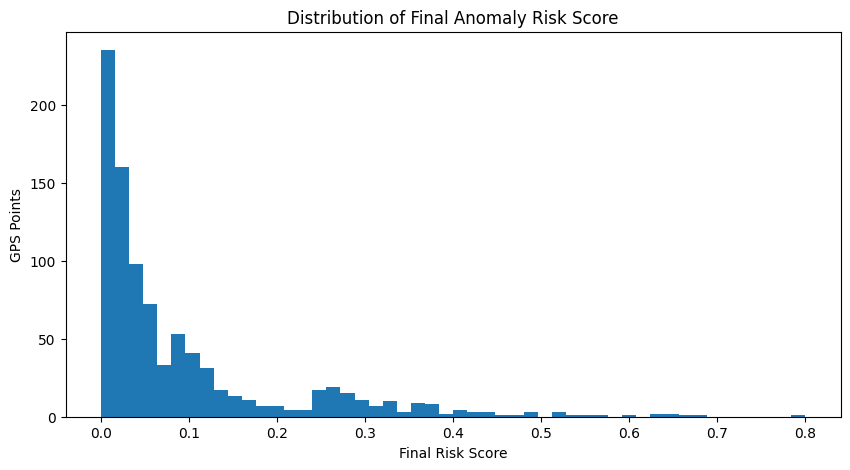

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(
    df["final_risk_score"],
    bins=50)

plt.xlabel("Final Risk Score")
plt.ylabel("GPS Points")
plt.title("Distribution of Final Anomaly Risk Score")

plt.show()

# Severity Distribution 

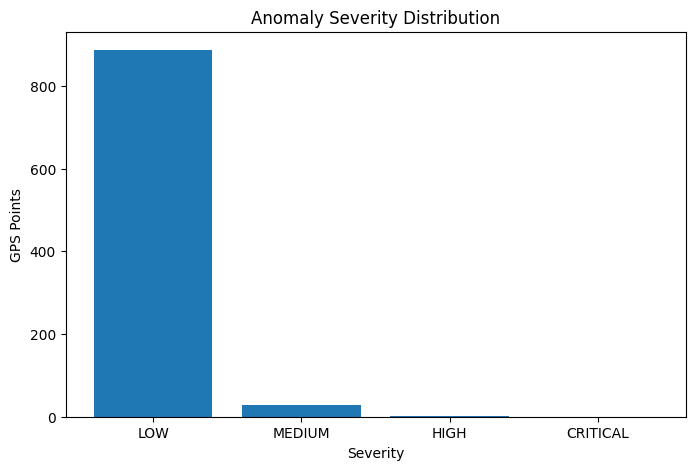

In [34]:
severity_counts = (
    df["severity"]
    .value_counts()
    .reindex(
        ["LOW", "MEDIUM", "HIGH", "CRITICAL"],
        fill_value=0 ))

plt.figure(figsize=(8, 5))

plt.bar(
    severity_counts.index,
    severity_counts.values)
plt.xlabel("Severity")
plt.ylabel("GPS Points")
plt.title("Anomaly Severity Distribution")

plt.show()

# Normal vs Anomaly Speed 

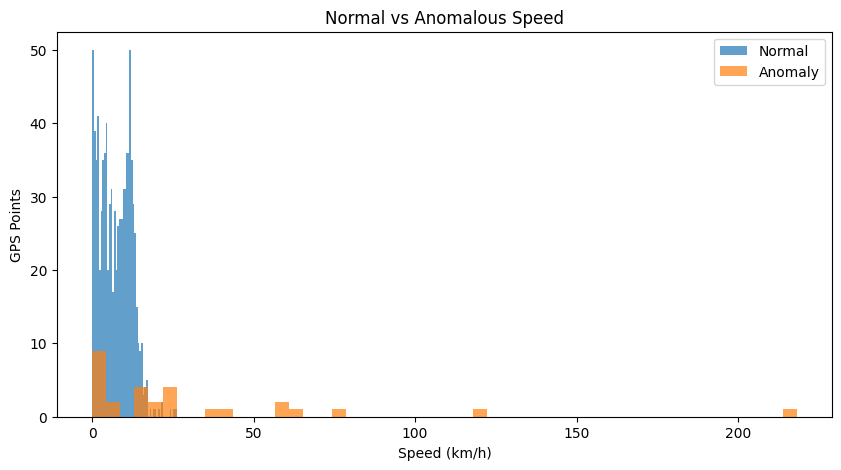

In [35]:
plt.figure(figsize=(10, 5))
plt.hist(
    df.loc[
        ~df["is_anomaly"],
        "speed_kmh"],
    bins=50,
    alpha=0.7,
    label="Normal")

plt.hist(
    df.loc[
        df["is_anomaly"],
        "speed_kmh"
    ],
    bins=50,
    alpha=0.7,
    label="Anomaly")

plt.xlabel("Speed (km/h)")
plt.ylabel("GPS Points")
plt.title("Normal vs Anomalous Speed")
plt.legend()

plt.show()

# Road Distance vs Risk 

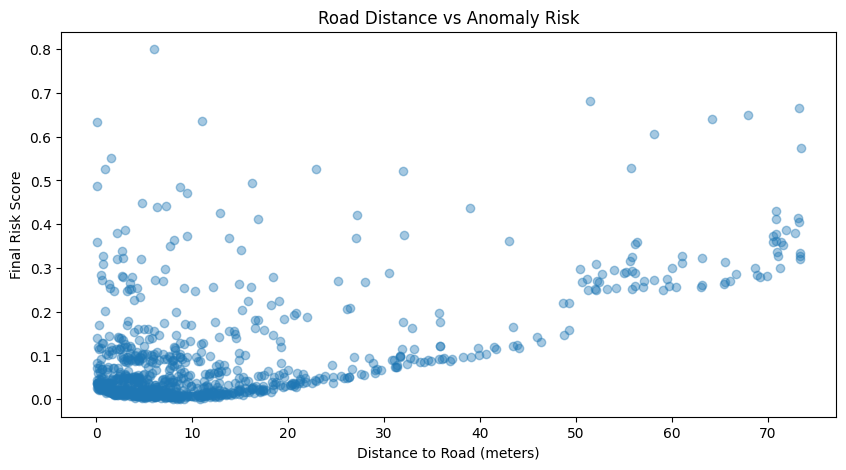

In [36]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["distance_to_road_m"],
    df["final_risk_score"],
    alpha=0.4
)
plt.xlabel("Distance to Road (meters)")
plt.ylabel("Final Risk Score")
plt.title("Road Distance vs Anomaly Risk")

plt.show()

# GPS Trajectory with Anomalies

In [37]:
# Separate Normal and Anomaly Points
normal_points = df[
    ~df["is_anomaly"]]
anomaly_points = df[
    df["is_anomaly"]]
print("Normal:", len(normal_points))
print("Anomalies:", len(anomaly_points))

Normal: 887
Anomalies: 29


# Latitude/ Longitude

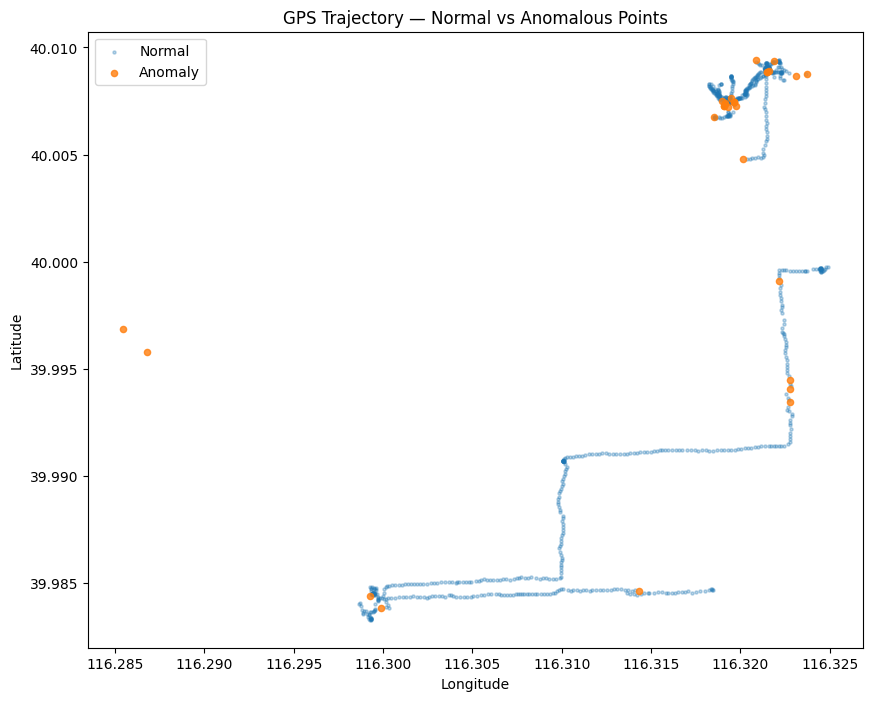

In [38]:
plt.figure(figsize=(10, 8))
plt.scatter(
    normal_points["longitude"],
    normal_points["latitude"],
    s=5,
    alpha=0.3,
    label="Normal")

plt.scatter(
    anomaly_points["longitude"],
    anomaly_points["latitude"],
    s=20,
    alpha=0.8,
    label="Anomaly")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GPS Trajectory — Normal vs Anomalous Points")
plt.legend()
plt.show()

# Threshold Tuning and EValuation Framework

# Compare Different risk thresholds 

In [39]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
threshold_results = []
for threshold in thresholds:
    count = (
        df["final_risk_score"] >= threshold
    ).sum()
    percentage = (
        count / len(df)
    ) * 100
    threshold_results.append({
        "threshold": threshold,
        "anomaly_count": count,
        "anomaly_percent": round(percentage, 2)
    })
threshold_df = pd.DataFrame(
    threshold_results)
print(threshold_df)

   threshold  anomaly_count  anomaly_percent
0        0.3             69             7.53
1        0.4             29             3.17
2        0.5             14             1.53
3        0.6              8             0.87
4        0.7              1             0.11
5        0.8              1             0.11
6        0.9              0             0.00


## Distribution of Severity against actual score

In [40]:
print(
    df.groupby("severity")["final_risk_score"]
      .agg(["count", "min", "mean", "max"]))

          count       min      mean       max
severity                                     
HIGH          1  0.800000  0.800000  0.800000
LOW         887  0.000000  0.078297  0.387664
MEDIUM       28  0.405774  0.513234  0.680600


# Inspect Hight/Critical Events 

In [41]:
high_risk = df[
    df["severity"].isin(
        ["HIGH", "CRITICAL"]
    )
].copy()
print(
    high_risk[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "rule_anomaly_score",
            "ml_anomaly_score",
            "final_risk_score",
            "severity",
            "anomaly_reasons"
        ]
    ]
    .sort_values(
        "final_risk_score",
        ascending=False
    )  .head(30))

    guard_id           timestamp   latitude   longitude   speed_kmh  \
150      000 2008-10-23 04:08:42  39.984397  116.299292  218.147174   

     time_gap_seconds  distance_to_road_m  rule_anomaly_score  \
150              30.0            6.030698                 0.5   

     ml_anomaly_score  final_risk_score severity  \
150               1.0               0.8     HIGH   

                                       anomaly_reasons  
150  [Unusually high speed, GPS jump detected, Rule...  


# Check agreement Rule + ML

In [42]:
print(
    pd.crosstab(
        df["rule_flag"],
        df["ml_flag"],
        normalize="index" ).round(3))

ml_flag    False  True 
rule_flag              
False      0.973  0.027
True       0.360  0.640


# Anomaly Event Layer

Currently, df contains one row for each GPS observation. In a production system, we should convert the detected anomalies into separate event records.

# Select Anomalies 

In [43]:
anomaly_events = df[
    df["is_anomaly"]
].copy()
print("Anomaly events:", len(anomaly_events))

Anomaly events: 29


# Create Event ID

Every detected event should have a unique ID:

In [44]:
anomaly_events = anomaly_events.reset_index(drop=True)
anomaly_events["event_id"] = (
    "ANOM-" +
    anomaly_events.index.astype(str).str.zfill(6))

# Columns in Production

In [45]:
event_columns = [
    "event_id",
    "guard_id",
    "timestamp",
    "latitude",
    "longitude",

    "speed_kmh",
    "time_gap_seconds",
    "distance_from_previous_m",
    "distance_to_road_m",

    "gps_jump_flag",
    "road_match_status",

    "rule_anomaly_score",
    "ml_anomaly_score",
    "final_risk_score",

    "severity",
    "anomaly_reasons"
]

anomaly_events = anomaly_events[
    event_columns
].copy()

# Keep Severity in Priority order

In [46]:
severity_order = {
    "LOW": 1,
    "MEDIUM": 2,
    "HIGH": 3,
    "CRITICAL": 4}

anomaly_events["severity_priority"] = (
    anomaly_events["severity"]
    .map(severity_order))

# Highest Risk Events

In [47]:
print(
    anomaly_events
    .sort_values(
        ["severity_priority", "final_risk_score"],
        ascending=[False, False]
    ) .head(20))

       event_id guard_id           timestamp   latitude   longitude  \
3   ANOM-000003      000 2008-10-23 04:08:42  39.984397  116.299292   
21  ANOM-000021      000 2008-10-23 10:19:16  40.007645  116.319454   
23  ANOM-000023      000 2008-10-23 10:28:45  40.007457  116.319674   
20  ANOM-000020      000 2008-10-23 10:15:06  40.007399  116.319120   
14  ANOM-000014      000 2008-10-23 10:09:26  40.007272  116.319756   
1   ANOM-000001      000 2008-10-23 04:08:07  39.995777  116.286798   
9   ANOM-000009      000 2008-10-23 09:42:25  40.004775  116.320158   
17  ANOM-000017      000 2008-10-23 10:14:26  40.007203  116.319334   
18  ANOM-000018      000 2008-10-23 10:14:31  40.007350  116.319131   
2   ANOM-000002      000 2008-10-23 04:08:12  39.996832  116.285446   
19  ANOM-000019      000 2008-10-23 10:14:36  40.007504  116.318956   
4   ANOM-000004      000 2008-10-23 04:11:22  39.983841  116.299902   
26  ANOM-000026      000 2008-10-23 10:44:31  40.008761  116.323722   
22  AN

# Anomaly Type

Currently, `anomaly_reasons` is just a **list of text reasons**. In a production system, we also need **structured anomaly types** so each anomaly can be clearly classified and analyzed.


In [48]:
def get_anomaly_types(row):
    types = []
    if row["distance_to_road_m"] > 50:
        types.append("ROUTE_DEVIATION")
    if row["gps_jump_flag"]:
        types.append("GPS_JUMP")
    if row["time_gap_seconds"] > 60:
        types.append("LONG_CHECKIN_GAP")
    if row["speed_kmh"] > 80:
        types.append("ABNORMAL_SPEED")
    return types

In [49]:
# Apply
anomaly_events["anomaly_types"] = (
    anomaly_events.apply(
        get_anomaly_types,
        axis=1))

# Print 
print(
    anomaly_events[
        [
            "event_id",
            "guard_id",
            "severity",
            "anomaly_types",
            "anomaly_reasons"
        ] ].head(20))

       event_id guard_id severity               anomaly_types  \
0   ANOM-000000      000   MEDIUM                          []   
1   ANOM-000001      000   MEDIUM          [LONG_CHECKIN_GAP]   
2   ANOM-000002      000   MEDIUM            [ABNORMAL_SPEED]   
3   ANOM-000003      000     HIGH  [GPS_JUMP, ABNORMAL_SPEED]   
4   ANOM-000004      000   MEDIUM                          []   
5   ANOM-000005      000   MEDIUM                          []   
6   ANOM-000006      000   MEDIUM                          []   
7   ANOM-000007      000   MEDIUM                          []   
8   ANOM-000008      000   MEDIUM                          []   
9   ANOM-000009      000   MEDIUM          [LONG_CHECKIN_GAP]   
10  ANOM-000010      000   MEDIUM                          []   
11  ANOM-000011      000   MEDIUM          [LONG_CHECKIN_GAP]   
12  ANOM-000012      000   MEDIUM          [LONG_CHECKIN_GAP]   
13  ANOM-000013      000   MEDIUM                          []   
14  ANOM-000014      000 

## Guard-Level Risk Aggregation

# Guard-Wise Total Observations

In [50]:
guard_summary = (
    df.groupby("guard_id")
      .agg(
          total_gps_points=("guard_id", "size"),
          total_anomalies=("is_anomaly", "sum"),
          avg_risk_score=("final_risk_score", "mean"),
          max_risk_score=("final_risk_score", "max"),
          avg_speed_kmh=("speed_kmh", "mean"),
          avg_distance_to_road_m=("distance_to_road_m", "mean"),
      ).reset_index())
print(guard_summary)

  guard_id  total_gps_points  total_anomalies  avg_risk_score  max_risk_score  \
0      000               916               29         0.09238             0.8   

   avg_speed_kmh  avg_distance_to_road_m  
0       8.041133                 13.5798  


# Anomaly Percentage per guard 

In [51]:
guard_summary["anomaly_rate"] = (
    guard_summary["total_anomalies"]
    / guard_summary["total_gps_points"]
    * 100)
guard_summary["anomaly_rate"] = (
    guard_summary["anomaly_rate"].round(2))

print(
    guard_summary.sort_values(
        "anomaly_rate",
        ascending=False
    ).head(20))

  guard_id  total_gps_points  total_anomalies  avg_risk_score  max_risk_score  \
0      000               916               29         0.09238             0.8   

   avg_speed_kmh  avg_distance_to_road_m  anomaly_rate  
0       8.041133                 13.5798          3.17  


# High + Critical Events Per Guard

In [52]:
high_critical = (
    df["severity"]
    .isin(["HIGH", "CRITICAL"]))
high_critical_counts = (
    df[high_critical]
    .groupby("guard_id")
    .size()
    .rename("high_critical_events"))

guard_summary = guard_summary.merge(
    high_critical_counts,
    on="guard_id",
    how="left")

guard_summary["high_critical_events"] = (
    guard_summary["high_critical_events"]
    .fillna(0)
    .astype(int))

# Overall Guard Risk 

In [53]:
guard_summary["guard_risk_score"] = (
    0.40 * guard_summary["anomaly_rate"].clip(0, 100) / 100
    + 0.30 * guard_summary["avg_risk_score"]
    + 0.30 * guard_summary["max_risk_score"]
)

# Guard Severity 

In [54]:
def guard_severity(score):
    if score >= 0.90:
        return "CRITICAL"
    elif score >= 0.70:
        return "HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"
guard_summary["guard_severity"] = (
    guard_summary["guard_risk_score"]
    .apply(guard_severity))

# Final Guard Petrol 

In [55]:
guard_summary = guard_summary[
    [
        "guard_id",
        "total_gps_points",
        "total_anomalies",
        "anomaly_rate",
        "high_critical_events",
        "avg_speed_kmh",
        "avg_distance_to_road_m",
        "avg_risk_score",
        "max_risk_score",
        "guard_risk_score",
        "guard_severity"]]

print(
    guard_summary.sort_values(
        "guard_risk_score",
        ascending=False
    ).head(20))

  guard_id  total_gps_points  total_anomalies  anomaly_rate  \
0      000               916               29          3.17   

   high_critical_events  avg_speed_kmh  avg_distance_to_road_m  \
0                     1       8.041133                 13.5798   

   avg_risk_score  max_risk_score  guard_risk_score guard_severity  
0         0.09238             0.8          0.280394            LOW  


## Patrol / Session-Level Aggregation

# Sort Data According Guard + Timestamp

In [56]:
df = df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)

# Identify Session Break

We will consider new session with gap of more than 60 minutes 

In [57]:
df["session_break"] = (
    df["time_gap_seconds"] > 3600
)

# First Point Will also be Session

In [58]:
df["session_break"] = (
    df["session_break"] |
    df.groupby("guard_id").cumcount().eq(0))

# Create Session ID

In [59]:
df["session_number"] = (
    df.groupby("guard_id")["session_break"]
      .cumsum()
)

df["patrol_id"] = (
    df["guard_id"].astype(str)
    + "_PATROL_"
    + df["session_number"].astype(str).str.zfill(4)
)

print(
    df[
        [
            "guard_id",
            "timestamp",
            "time_gap_seconds",
            "patrol_id"
        ]  ].head(20))

   guard_id           timestamp  time_gap_seconds        patrol_id
0       000 2008-10-23 02:53:04               0.0  000_PATROL_0001
1       000 2008-10-23 02:53:10               6.0  000_PATROL_0001
2       000 2008-10-23 02:53:15               5.0  000_PATROL_0001
3       000 2008-10-23 02:53:20               5.0  000_PATROL_0001
4       000 2008-10-23 02:53:25               5.0  000_PATROL_0001
5       000 2008-10-23 02:53:30               5.0  000_PATROL_0001
6       000 2008-10-23 02:53:35               5.0  000_PATROL_0001
7       000 2008-10-23 02:53:40               5.0  000_PATROL_0001
8       000 2008-10-23 02:53:45               5.0  000_PATROL_0001
9       000 2008-10-23 02:53:50               5.0  000_PATROL_0001
10      000 2008-10-23 02:53:55               5.0  000_PATROL_0001
11      000 2008-10-23 02:54:00               5.0  000_PATROL_0001
12      000 2008-10-23 02:54:05               5.0  000_PATROL_0001
13      000 2008-10-23 02:54:10               5.0  000_PATROL_

# Patrol Summary 

In [60]:
patrol_summary = (
    df.groupby(
        ["guard_id", "patrol_id"])
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        gps_points=("timestamp", "size"),
        total_distance_m=(
            "distance_from_previous_m",
            "sum"),
        anomaly_count=(
            "is_anomaly",
            "sum"),
        max_risk_score=(
            "final_risk_score",
            "max"),
        avg_risk_score=(
            "final_risk_score",
            "mean"),
        avg_speed_kmh=(
            "speed_kmh",
            "mean"),
        max_speed_kmh=(
            "speed_kmh",
            "max"),
        avg_road_distance_m=(
            "distance_to_road_m",
            "mean" ))
    .reset_index())

# Patrol Duration 

In [61]:
patrol_summary["duration_minutes"] = (
    (
        patrol_summary["end_time"]
        - patrol_summary["start_time"]
    )
    .dt.total_seconds()
    / 60
)

# Anomaly Rate 

In [62]:
patrol_summary["anomaly_rate"] = (
    patrol_summary["anomaly_count"]
    / patrol_summary["gps_points"]
    * 100
).round(2)

# Check Result

In [63]:
print(
    patrol_summary.head(20))
print(
    "Total patrol sessions:",
    len(patrol_summary))

  guard_id        patrol_id          start_time            end_time  \
0      000  000_PATROL_0001 2008-10-23 02:53:04 2008-10-23 03:05:15   
1      000  000_PATROL_0002 2008-10-23 04:08:07 2008-10-23 04:34:52   
2      000  000_PATROL_0003 2008-10-23 09:42:25 2008-10-23 11:11:12   

   gps_points  total_distance_m  anomaly_count  max_risk_score  \
0         148       2072.374155              1        0.440732   
1         322       7908.578316              8        0.800000   
2         446       5034.776046             20        0.680600   

   avg_risk_score  avg_speed_kmh  max_speed_kmh  avg_road_distance_m  \
0        0.056712      10.084401      41.891857             6.274945   
1        0.079595      10.617332     218.147174             6.907488   
2        0.113446       5.503152      61.286863            20.821063   

   duration_minutes  anomaly_rate  
0         12.183333          0.68  
1         26.750000          2.48  
2         88.783333          4.48  
Total patrol sess

## Save This Layer

In [64]:
patrol_output = (
    PROCESSED_DATA_DIR
    / "geolife_patrol_summary.parquet")

patrol_summary.to_parquet(
    patrol_output,
    index=False)

print("Saved:", patrol_output)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_patrol_summary.parquet


# Patrol in Route Distance

In [65]:
patrol_summary["total_distance_km"] = (
    patrol_summary["total_distance_m"] / 1000)

# Average Movement Speed

In [66]:
patrol_summary["avg_speed_kmh"] = (
    patrol_summary["avg_speed_kmh"].round(2))

patrol_summary["max_speed_kmh"] = (
    patrol_summary["max_speed_kmh"].round(2))

# Road Deviation Ratio

Average distance alone is not enough. We will calculate **how frequently the patrol's GPS points were far from the road**.


In [67]:
road_deviation = (
    df.assign(
        road_deviation_flag=
        df["distance_to_road_m"] > 50)
    .groupby("patrol_id")["road_deviation_flag"]
    .agg(
        road_deviation_points="sum",
        total_points="count")
    .reset_index())

In [68]:
# Percentage
road_deviation["road_deviation_rate"] = (
    road_deviation["road_deviation_points"]
    / road_deviation["total_points"]
    * 100
).round(2)

# Merge Patrol Summary 

In [69]:
patrol_summary = patrol_summary.merge(
    road_deviation[
        [
            "patrol_id",
            "road_deviation_points",
            "road_deviation_rate"
        ]],
    on="patrol_id",
    how="left")

In [70]:
print(
    patrol_summary[
        [
            "guard_id",
            "patrol_id",
            "duration_minutes",
            "total_distance_km",
            "avg_speed_kmh",
            "max_speed_kmh",
            "road_deviation_points",
            "road_deviation_rate",
            "anomaly_count",
            "anomaly_rate"
        ]].head(20))

  guard_id        patrol_id  duration_minutes  total_distance_km  \
0      000  000_PATROL_0001         12.183333           2.072374   
1      000  000_PATROL_0002         26.750000           7.908578   
2      000  000_PATROL_0003         88.783333           5.034776   

   avg_speed_kmh  max_speed_kmh  road_deviation_points  road_deviation_rate  \
0          10.08          41.89                      0                  0.0   
1          10.62         218.15                      0                  0.0   
2           5.50          61.29                     70                 15.7   

   anomaly_count  anomaly_rate  
0              1          0.68  
1              8          2.48  
2             20          4.48  


# Patrol Risk Score

In [71]:
patrol_summary["patrol_risk_score"] = (
    0.35 * patrol_summary["anomaly_rate"].clip(0, 100) / 100
    + 0.30 * patrol_summary["road_deviation_rate"].clip(0, 100) / 100
    + 0.20 * patrol_summary["max_risk_score"]
    + 0.15 * patrol_summary["avg_risk_score"])

# Patrol Severity

In [72]:
def patrol_severity(score):
    if score >= 0.90:
        return "CRITICAL"
    elif score >= 0.70:
        return "HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"
patrol_summary["patrol_severity"] = (
    patrol_summary["patrol_risk_score"]
    .apply(patrol_severity))

# Highest Risk Score

In [73]:
print(
    patrol_summary
    .sort_values(
        "patrol_risk_score",
        ascending=False)
    [
        [
            "guard_id",
            "patrol_id",
            "start_time",
            "end_time",
            "duration_minutes",
            "total_distance_km",
            "anomaly_count",
            "anomaly_rate",
            "road_deviation_rate",
            "patrol_risk_score",
            "patrol_severity"
        ]]
    .head(20))

  guard_id        patrol_id          start_time            end_time  \
2      000  000_PATROL_0003 2008-10-23 09:42:25 2008-10-23 11:11:12   
1      000  000_PATROL_0002 2008-10-23 04:08:07 2008-10-23 04:34:52   
0      000  000_PATROL_0001 2008-10-23 02:53:04 2008-10-23 03:05:15   

   duration_minutes  total_distance_km  anomaly_count  anomaly_rate  \
2         88.783333           5.034776             20          4.48   
1         26.750000           7.908578              8          2.48   
0         12.183333           2.072374              1          0.68   

   road_deviation_rate  patrol_risk_score patrol_severity  
2                 15.7           0.215917             LOW  
1                  0.0           0.180619             LOW  
0                  0.0           0.099033             LOW  


# Save Petrol Layer

In [74]:
patrol_output = (
    PROCESSED_DATA_DIR
    / "geolife_patrol_summary.parquet")

patrol_summary.to_parquet(
    patrol_output,
    index=False)

print("Saved:", patrol_output)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_patrol_summary.parquet


# Patrol Route Visualization

# Select One Petrol

In [75]:
patrol_id = patrol_summary.sort_values(
    "patrol_risk_score",
    ascending=False
).iloc[0]["patrol_id"]

print("Selected patrol:", patrol_id)

Selected patrol: 000_PATROL_0003


# GPS data of that one petrol

In [76]:
patrol_df = df[
    df["patrol_id"] == patrol_id
].copy()

patrol_df = patrol_df.sort_values("timestamp")

print("GPS points:", len(patrol_df))
print(
    patrol_df[
        [
            "timestamp",
            "latitude",
            "longitude",
            "distance_to_road_m",
            "final_risk_score",
            "severity",
            "is_anomaly"
        ]].head())

GPS points: 446
              timestamp   latitude   longitude  distance_to_road_m  \
470 2008-10-23 09:42:25  40.004775  116.320158            0.007636   
471 2008-10-23 09:42:30  40.004783  116.320388            3.235982   
472 2008-10-23 09:42:35  40.004799  116.320545            2.197407   
473 2008-10-23 09:42:40  40.004835  116.320683            1.264974   
474 2008-10-23 09:42:45  40.004851  116.320835            2.456014   

     final_risk_score severity  is_anomaly  
470          0.634462   MEDIUM        True  
471          0.089302      LOW       False  
472          0.021618      LOW       False  
473          0.023535      LOW       False  
474          0.020671      LOW       False  


# Plot Complete Patrol Trajectory

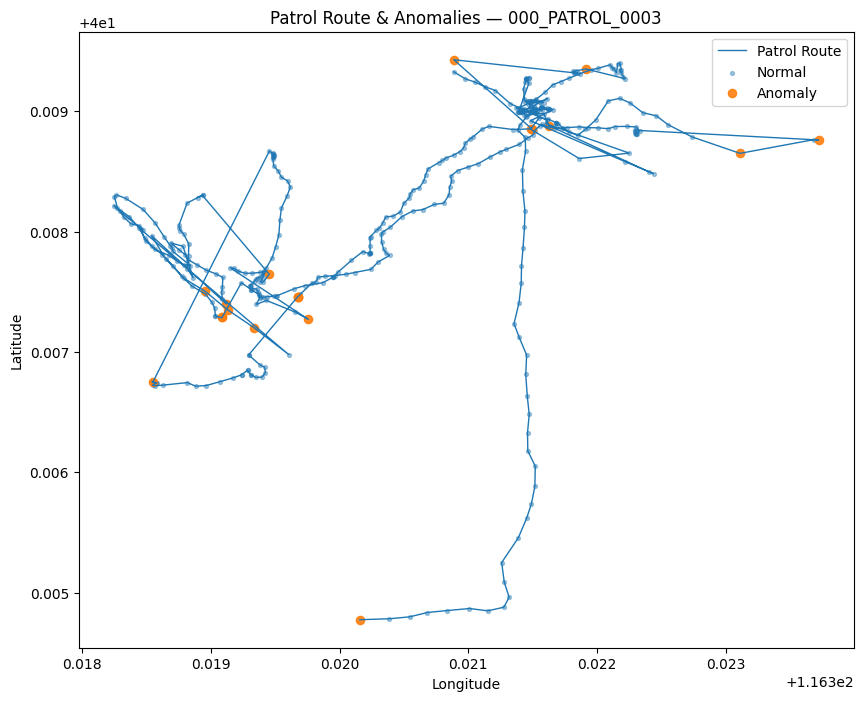

In [77]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.plot(
    patrol_df["longitude"],
    patrol_df["latitude"],
    linewidth=1,
    label="Patrol Route")
normal = patrol_df[
    ~patrol_df["is_anomaly"]]
anomalies = patrol_df[
    patrol_df["is_anomaly"]]
plt.scatter(
    normal["longitude"],
    normal["latitude"],
    s=8,
    alpha=0.4,
    label="Normal")
plt.scatter(
    anomalies["longitude"],
    anomalies["latitude"],
    s=35,
    alpha=0.9,
    label="Anomaly")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Patrol Route & Anomalies — {patrol_id}")
plt.legend()
plt.show()

# Road deviation points

In [78]:
deviation_points = patrol_df[
    patrol_df["distance_to_road_m"] > 50]

print(
    "Road deviation points:",
    len(deviation_points))

Road deviation points: 70


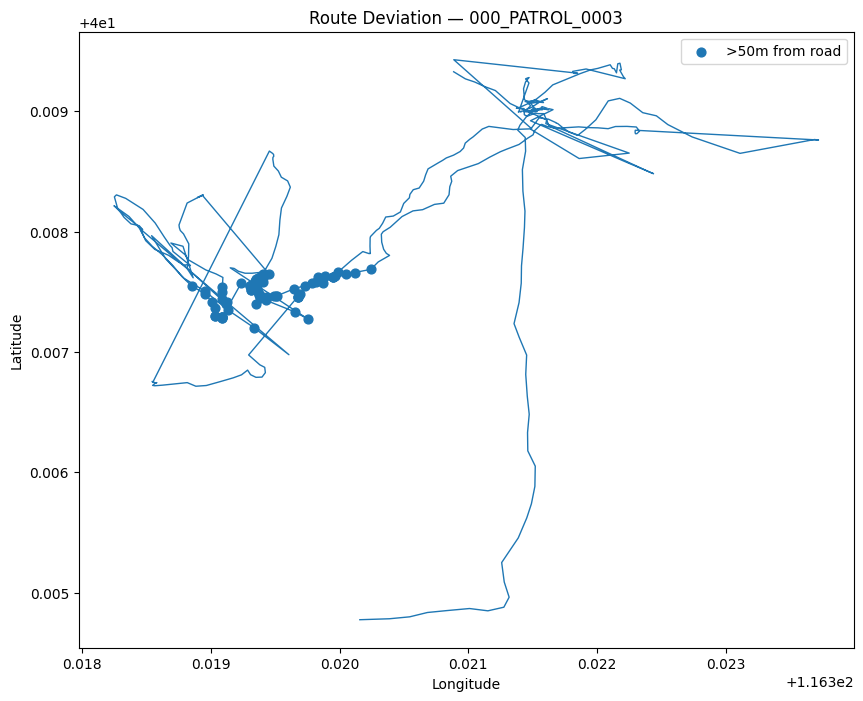

In [79]:
plt.figure(figsize=(10, 8))
plt.plot(
    patrol_df["longitude"],
    patrol_df["latitude"],
    linewidth=1)
plt.scatter(
    deviation_points["longitude"],
    deviation_points["latitude"],
    s=40,
    label=">50m from road")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Route Deviation — {patrol_id}")
plt.legend()
plt.show()

# Highest Risk Locations

In [80]:
print(
    patrol_df
    .sort_values(
        "final_risk_score",
        ascending=False
    )[
        [
            "timestamp",
            "latitude",
            "longitude",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "final_risk_score",
            "severity"
        ]
    ]
    .head(20)
)

              timestamp   latitude   longitude  speed_kmh  time_gap_seconds  \
769 2008-10-23 10:19:16  40.007645  116.319454  61.286863               5.0   
823 2008-10-23 10:28:45  40.007457  116.319674  22.530987              10.0   
743 2008-10-23 10:15:06  40.007399  116.319120  19.224082              15.0   
685 2008-10-23 10:09:26  40.007272  116.319756  25.242124              10.0   
470 2008-10-23 09:42:25  40.004775  116.320158   0.134025           18453.0   
737 2008-10-23 10:14:26  40.007203  116.319334  24.660005               5.0   
738 2008-10-23 10:14:31  40.007350  116.319131  17.142172               5.0   
739 2008-10-23 10:14:36  40.007504  116.318956  16.349874               5.0   
881 2008-10-23 10:44:31  40.008761  116.323722   0.654102             671.0   
794 2008-10-23 10:26:35  40.006747  116.318549   2.561721             319.0   
518 2008-10-23 09:49:55  40.008880  116.321628  56.832697               5.0   
613 2008-10-23 10:03:44  40.008854  116.321493  59.0

# Create Anomaly_Type

In [81]:
def get_anomaly_types(row):
    types = []
    if row["distance_to_road_m"] > 50:
        types.append("ROUTE_DEVIATION")
    if row["gps_jump_flag"]:
        types.append("GPS_JUMP")
    if row["time_gap_seconds"] > 60:
        types.append("LONG_TIME_GAP")
    if row["speed_kmh"] > 80:
        types.append("ABNORMAL_SPEED")
    return types

In [82]:
# Apply 
df["anomaly_types"] = df.apply(
    get_anomaly_types,
    axis=1)

print(
    df[
        [
            "timestamp",
            "distance_to_road_m",
            "speed_kmh",
            "time_gap_seconds",
            "gps_jump_flag",
            "anomaly_types",
            "final_risk_score",
            "severity"
        ]
    ]
    .sort_values(
        "final_risk_score",
        ascending=False
    )
    .head(20))

              timestamp  distance_to_road_m   speed_kmh  time_gap_seconds  \
150 2008-10-23 04:08:42            6.030698  218.147174              30.0   
769 2008-10-23 10:19:16           51.471609   61.286863               5.0   
823 2008-10-23 10:28:45           73.292997   22.530987              10.0   
743 2008-10-23 10:15:06           67.976996   19.224082              15.0   
685 2008-10-23 10:09:26           64.207894   25.242124              10.0   
148 2008-10-23 04:08:07           10.987361    1.577309            3772.0   
470 2008-10-23 09:42:25            0.007636    0.134025           18453.0   
737 2008-10-23 10:14:26           58.134556   24.660005               5.0   
738 2008-10-23 10:14:31           73.486863   17.142172               5.0   
149 2008-10-23 04:08:12            1.506708  118.423778               5.0   
739 2008-10-23 10:14:36           55.712743   16.349874               5.0   
184 2008-10-23 04:11:22            0.941744   75.080580               5.0   

# Create Patrol_df Again 

In [83]:
patrol_df = df[
    df["patrol_id"] == patrol_id
].copy()

In [84]:
print(
    patrol_df
    .sort_values(
        "final_risk_score",
        ascending=False
    )[
        [
            "timestamp",
            "latitude",
            "longitude",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "final_risk_score",
            "severity",
            "anomaly_types"
        ]
    ]  .head(20))

              timestamp   latitude   longitude  speed_kmh  time_gap_seconds  \
769 2008-10-23 10:19:16  40.007645  116.319454  61.286863               5.0   
823 2008-10-23 10:28:45  40.007457  116.319674  22.530987              10.0   
743 2008-10-23 10:15:06  40.007399  116.319120  19.224082              15.0   
685 2008-10-23 10:09:26  40.007272  116.319756  25.242124              10.0   
470 2008-10-23 09:42:25  40.004775  116.320158   0.134025           18453.0   
737 2008-10-23 10:14:26  40.007203  116.319334  24.660005               5.0   
738 2008-10-23 10:14:31  40.007350  116.319131  17.142172               5.0   
739 2008-10-23 10:14:36  40.007504  116.318956  16.349874               5.0   
881 2008-10-23 10:44:31  40.008761  116.323722   0.654102             671.0   
794 2008-10-23 10:26:35  40.006747  116.318549   2.561721             319.0   
518 2008-10-23 09:49:55  40.008880  116.321628  56.832697               5.0   
613 2008-10-23 10:03:44  40.008854  116.321493  59.0

# ANomaly Event Clustering 

To prevent Unnecessary Multiple Alerts 

In [85]:
anomaly_df = df[
    df["is_anomaly"]
].copy()

anomaly_df = anomaly_df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)

print("Anomaly points:", len(anomaly_df))

Anomaly points: 29


# previous Anomaly Time gap

In [86]:
anomaly_df["anomaly_time_gap"] = (
    anomaly_df
    .groupby("guard_id")["timestamp"]
    .diff()
    .dt.total_seconds()
)

print(
    anomaly_df[
        [
            "guard_id",
            "timestamp",
            "anomaly_time_gap",
            "anomaly_types",
            "severity"
        ] ].head(20))

   guard_id           timestamp  anomaly_time_gap               anomaly_types  \
0       000 2008-10-23 02:55:25               NaN                          []   
1       000 2008-10-23 04:08:07            4362.0             [LONG_TIME_GAP]   
2       000 2008-10-23 04:08:12               5.0            [ABNORMAL_SPEED]   
3       000 2008-10-23 04:08:42              30.0  [GPS_JUMP, ABNORMAL_SPEED]   
4       000 2008-10-23 04:11:22             160.0                          []   
5       000 2008-10-23 04:28:17            1015.0                          []   
6       000 2008-10-23 04:28:37              20.0                          []   
7       000 2008-10-23 04:28:52              15.0                          []   
8       000 2008-10-23 04:31:27             155.0                          []   
9       000 2008-10-23 09:42:25           18658.0             [LONG_TIME_GAP]   
10      000 2008-10-23 09:49:55             450.0                          []   
11      000 2008-10-23 10:02

# Define Incident Break 

Gap > 30 mins = new incident 

In [87]:
anomaly_df["new_incident"] = (
    anomaly_df["anomaly_time_gap"].isna()
    |
    (anomaly_df["anomaly_time_gap"] > 1800))

# Incident ID

In [88]:
anomaly_df["incident_number"] = (
    anomaly_df
    .groupby("guard_id")["new_incident"]
    .cumsum())

anomaly_df["incident_id"] = (
    anomaly_df["guard_id"].astype(str)
    + "_INC_"
    + anomaly_df["incident_number"]
      .astype(str)
      .str.zfill(4))

print(
    anomaly_df[
        [
            "guard_id",
            "timestamp",
            "anomaly_types",
            "incident_id"
        ] ].head(30))

   guard_id           timestamp               anomaly_types   incident_id
0       000 2008-10-23 02:55:25                          []  000_INC_0001
1       000 2008-10-23 04:08:07             [LONG_TIME_GAP]  000_INC_0002
2       000 2008-10-23 04:08:12            [ABNORMAL_SPEED]  000_INC_0002
3       000 2008-10-23 04:08:42  [GPS_JUMP, ABNORMAL_SPEED]  000_INC_0002
4       000 2008-10-23 04:11:22                          []  000_INC_0002
5       000 2008-10-23 04:28:17                          []  000_INC_0002
6       000 2008-10-23 04:28:37                          []  000_INC_0002
7       000 2008-10-23 04:28:52                          []  000_INC_0002
8       000 2008-10-23 04:31:27                          []  000_INC_0002
9       000 2008-10-23 09:42:25             [LONG_TIME_GAP]  000_INC_0003
10      000 2008-10-23 09:49:55                          []  000_INC_0003
11      000 2008-10-23 10:02:04             [LONG_TIME_GAP]  000_INC_0003
12      000 2008-10-23 10:03:39       

# Incident Summary

In [89]:
incident_summary = (
    anomaly_df
    .groupby(
        ["guard_id", "incident_id"])
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        anomaly_points=("timestamp", "size"),
        max_risk_score=("final_risk_score", "max"),
        avg_risk_score=("final_risk_score", "mean"),
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"))
    .reset_index())


# Incident Duration 

In [90]:
incident_summary["duration_minutes"] = (
    (
        incident_summary["end_time"]
        - incident_summary["start_time"]
    )
    .dt.total_seconds()/ 60)

print(
    incident_summary.sort_values(
        "max_risk_score",
        ascending=False
    ).head(20))

  guard_id   incident_id          start_time            end_time  \
1      000  000_INC_0002 2008-10-23 04:08:07 2008-10-23 04:31:27   
2      000  000_INC_0003 2008-10-23 09:42:25 2008-10-23 11:08:22   
0      000  000_INC_0001 2008-10-23 02:55:25 2008-10-23 02:55:25   

   anomaly_points  max_risk_score  avg_risk_score   latitude   longitude  \
1               8        0.800000        0.535088  39.992735  116.307745   
2              20        0.680600        0.522456  40.007781  116.320295   
0               1        0.440732        0.440732  39.984618  116.314323   

   duration_minutes  
1         23.333333  
2         85.950000  
0          0.000000  


# Spatial Clustering of Anomaly Points

 We will group nearby GPS anomalies into the **same incident**, not just group them by time. This helps turn multiple nearby route-deviation points into **one meaningful incident**.


In [91]:
from sklearn.cluster import DBSCAN
import numpy as np

# Prepare Anomaly GPS coordinates
coords = anomaly_df[
    ["latitude", "longitude"]
].to_numpy()

coords_rad = np.radians(coords)

# Spatial DBSCAN        For GPS coordinates, we will use the **Haversine distance** to calculate the distance between two points on the Earth's surface.

EARTH_RADIUS_M = 6_371_000

spatial_model = DBSCAN(
    eps=100 / EARTH_RADIUS_M,  
    #100 = 100 meters
    # min_samples=2 = Atleast 2 nearby anomaly points
    # -1 = isolated anomaly     
    min_samples=2,
    metric="haversine")

anomaly_df["spatial_cluster"] = (
    spatial_model.fit_predict(coords_rad))

# Check Result
print(
    anomaly_df[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "anomaly_types",
            "spatial_cluster"
        ]].head(30))

   guard_id           timestamp   latitude   longitude  \
0       000 2008-10-23 02:55:25  39.984618  116.314323   
1       000 2008-10-23 04:08:07  39.995777  116.286798   
2       000 2008-10-23 04:08:12  39.996832  116.285446   
3       000 2008-10-23 04:08:42  39.984397  116.299292   
4       000 2008-10-23 04:11:22  39.983841  116.299902   
5       000 2008-10-23 04:28:17  39.993429  116.322760   
6       000 2008-10-23 04:28:37  39.994055  116.322804   
7       000 2008-10-23 04:28:52  39.994471  116.322763   
8       000 2008-10-23 04:31:27  39.999078  116.322196   
9       000 2008-10-23 09:42:25  40.004775  116.320158   
10      000 2008-10-23 09:49:55  40.008880  116.321628   
11      000 2008-10-23 10:02:04  40.009351  116.321916   
12      000 2008-10-23 10:03:39  40.009428  116.320888   
13      000 2008-10-23 10:03:44  40.008854  116.321493   
14      000 2008-10-23 10:09:26  40.007272  116.319756   
15      000 2008-10-23 10:10:31  40.007288  116.319088   
16      000 20

In [92]:
# Spatial CLuster Count 

print(
    anomaly_df["spatial_cluster"]
    .value_counts()
    .sort_index())

spatial_cluster
-1     5
 0     2
 1     3
 2     5
 3    12
 4     2
Name: count, dtype: int64


# Production Logic 

Same Guard
   +
Nearby Location <= 100m
   +
Time Difference <= 30 min
   ↓
Same Incident

# Refine Existing Incident Id

In [93]:
anomaly_df = anomaly_df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)

anomaly_df["new_spatial_incident"] = (
    anomaly_df["spatial_cluster"]
    != anomaly_df
    .groupby("guard_id")["spatial_cluster"]
    .shift())

# Time + Spatial Incident Fusion 

# Sort Anomaly Data

In [94]:
anomaly_df = anomaly_df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)

# Time group of Previous Anomaly 

In [95]:
anomaly_df["time_gap_from_previous"] = (
    anomaly_df
    .groupby("guard_id")["timestamp"]
    .diff()
    .dt.total_seconds())

# Geographic Distance From Previous Anomaly

In [96]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

lat = np.radians(anomaly_df["latitude"].to_numpy())
lon = np.radians(anomaly_df["longitude"].to_numpy())

prev_lat = anomaly_df.groupby("guard_id")["latitude"].shift()
prev_lon = anomaly_df.groupby("guard_id")["longitude"].shift()

prev_lat = np.radians(prev_lat.to_numpy())
prev_lon = np.radians(prev_lon.to_numpy())

lat1 = np.nan_to_num(lat)
lon1 = np.nan_to_num(lon)

lat2 = np.nan_to_num(prev_lat)
lon2 = np.nan_to_num(prev_lon)

coords_current = np.column_stack([lat1, lon1])
coords_previous = np.column_stack([lat2, lon2])

distance_m = (
    haversine_distances(
        coords_current,
        coords_previous
    ).diagonal()
    * 6_371_000)

distance_m[
    anomaly_df["time_gap_from_previous"].isna()
] = np.nan

anomaly_df["distance_from_previous_anomaly_m"] = distance_m

# New Incident Condition 

Initial logic:

different guard → new incident

time gap > 30 min → new incident

distance > 100 m → new incident

otherwise → same incident

In [97]:
anomaly_df["new_incident"] = (
    anomaly_df["time_gap_from_previous"].isna()
    |
    (anomaly_df["time_gap_from_previous"] > 1800)
    |
    (anomaly_df["distance_from_previous_anomaly_m"] > 100))

# FInal Incident ID

In [98]:
anomaly_df["incident_number"] = (
    anomaly_df
    .groupby("guard_id")["new_incident"]
    .cumsum())

anomaly_df["incident_id"] = (
    anomaly_df["guard_id"].astype(str)
    + "_INC_"
    + anomaly_df["incident_number"]
      .astype(str)
      .str.zfill(4))

In [99]:
print(
    anomaly_df[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "time_gap_from_previous",
            "distance_from_previous_anomaly_m",
            "anomaly_types",
            "incident_id"
        ]].head(30))

   guard_id           timestamp   latitude   longitude  \
0       000 2008-10-23 02:55:25  39.984618  116.314323   
1       000 2008-10-23 04:08:07  39.995777  116.286798   
2       000 2008-10-23 04:08:12  39.996832  116.285446   
3       000 2008-10-23 04:08:42  39.984397  116.299292   
4       000 2008-10-23 04:11:22  39.983841  116.299902   
5       000 2008-10-23 04:28:17  39.993429  116.322760   
6       000 2008-10-23 04:28:37  39.994055  116.322804   
7       000 2008-10-23 04:28:52  39.994471  116.322763   
8       000 2008-10-23 04:31:27  39.999078  116.322196   
9       000 2008-10-23 09:42:25  40.004775  116.320158   
10      000 2008-10-23 09:49:55  40.008880  116.321628   
11      000 2008-10-23 10:02:04  40.009351  116.321916   
12      000 2008-10-23 10:03:39  40.009428  116.320888   
13      000 2008-10-23 10:03:44  40.008854  116.321493   
14      000 2008-10-23 10:09:26  40.007272  116.319756   
15      000 2008-10-23 10:10:31  40.007288  116.319088   
16      000 20

# Incident Summary

In [100]:
incident_summary = (
    anomaly_df
    .groupby(["guard_id", "incident_id"])
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        anomaly_points=("timestamp", "size"),
        max_risk_score=("final_risk_score", "max"),
        avg_risk_score=("final_risk_score", "mean"),
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean")
    )
    .reset_index())

# Add Duration 

In [101]:
incident_summary["duration_minutes"] = (
    (
        incident_summary["end_time"]
        - incident_summary["start_time"]
    )
    .dt.total_seconds()
    / 60)

print(
    incident_summary
    .sort_values(
        "max_risk_score",
        ascending=False
    ) .head(20))

   guard_id   incident_id          start_time            end_time  \
3       000  000_INC_0004 2008-10-23 04:08:42 2008-10-23 04:11:22   
8       000  000_INC_0009 2008-10-23 10:09:26 2008-10-23 10:19:16   
10      000  000_INC_0011 2008-10-23 10:28:45 2008-10-23 10:28:50   
1       000  000_INC_0002 2008-10-23 04:08:07 2008-10-23 04:08:07   
6       000  000_INC_0007 2008-10-23 09:42:25 2008-10-23 09:42:25   
2       000  000_INC_0003 2008-10-23 04:08:12 2008-10-23 04:08:12   
11      000  000_INC_0012 2008-10-23 10:44:31 2008-10-23 10:44:41   
9       000  000_INC_0010 2008-10-23 10:26:35 2008-10-23 10:26:35   
4       000  000_INC_0005 2008-10-23 04:28:17 2008-10-23 04:28:52   
7       000  000_INC_0008 2008-10-23 09:49:55 2008-10-23 10:03:44   
12      000  000_INC_0013 2008-10-23 11:08:22 2008-10-23 11:08:22   
0       000  000_INC_0001 2008-10-23 02:55:25 2008-10-23 02:55:25   
5       000  000_INC_0006 2008-10-23 04:31:27 2008-10-23 04:31:27   

    anomaly_points  max_risk_scor

# Incident-Level Risk & Severity

# Aggregate Anomaly Types into Incident 

In [102]:
incident_types = (
    anomaly_df
    .groupby(["guard_id", "incident_id"])["anomaly_types"]
    .apply(
        lambda x: sorted(
            set(
                item
                for sublist in x
                for item in sublist
            )
        )
    )
    .reset_index(name="anomaly_types"))

# Merge in Incident Summary 

In [103]:
incident_summary = incident_summary.merge(
    incident_types,
    on=["guard_id", "incident_id"],
    how="left")

# Number of different Anomaly Types

In [104]:
incident_summary["anomaly_type_count"] = (
    incident_summary["anomaly_types"]
    .apply(len))

# Incident Risk Score 

Combine Multiple Anomaly points and Different Anomaly Types

In [105]:
incident_summary["incident_risk_score"] = (
    0.50 * incident_summary["max_risk_score"]
    + 0.30 * incident_summary["avg_risk_score"]
    + 0.20 * (
        incident_summary["anomaly_type_count"]
        .clip(0, 3) / 3
    ))

# Severity 

In [106]:
def incident_severity(score):
    if score >= 0.90:
        return "CRITICAL"
    elif score >= 0.70:
        return "HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"
incident_summary["incident_severity"] = (
    incident_summary["incident_risk_score"]
    .apply(incident_severity))

# Final Incident Table 

In [107]:
print(
    incident_summary[
        [
            "guard_id",
            "incident_id",
            "start_time",
            "end_time",
            "duration_minutes",
            "anomaly_points",
            "anomaly_types",
            "max_risk_score",
            "avg_risk_score",
            "incident_risk_score",
            "incident_severity"
        ]
    ]
    .sort_values(
        "incident_risk_score",
        ascending=False
    ).head(20))

   guard_id   incident_id          start_time            end_time  \
3       000  000_INC_0004 2008-10-23 04:08:42 2008-10-23 04:11:22   
8       000  000_INC_0009 2008-10-23 10:09:26 2008-10-23 10:19:16   
1       000  000_INC_0002 2008-10-23 04:08:07 2008-10-23 04:08:07   
6       000  000_INC_0007 2008-10-23 09:42:25 2008-10-23 09:42:25   
10      000  000_INC_0011 2008-10-23 10:28:45 2008-10-23 10:28:50   
2       000  000_INC_0003 2008-10-23 04:08:12 2008-10-23 04:08:12   
9       000  000_INC_0010 2008-10-23 10:26:35 2008-10-23 10:26:35   
11      000  000_INC_0012 2008-10-23 10:44:31 2008-10-23 10:44:41   
7       000  000_INC_0008 2008-10-23 09:49:55 2008-10-23 10:03:44   
12      000  000_INC_0013 2008-10-23 11:08:22 2008-10-23 11:08:22   
4       000  000_INC_0005 2008-10-23 04:28:17 2008-10-23 04:28:52   
0       000  000_INC_0001 2008-10-23 02:55:25 2008-10-23 02:55:25   
5       000  000_INC_0006 2008-10-23 04:31:27 2008-10-23 04:31:27   

    duration_minutes  anomaly_poi

# Severity Distribution 

In [108]:
print(
    incident_summary["incident_severity"]
    .value_counts())

incident_severity
MEDIUM    9
LOW       3
HIGH      1
Name: count, dtype: int64


# Maximum Value of Incident 

In [109]:
incident_metrics = (
    anomaly_df
    .groupby(["guard_id", "incident_id"])
    .agg(
        max_speed_kmh=("speed_kmh", "max"),
        max_road_distance_m=("distance_to_road_m", "max"),
        max_time_gap_seconds=("time_gap_seconds", "max"),
        gps_jump_count=("gps_jump_flag", "sum")
    )
    .reset_index())

# Merge with Incident Summary 

In [110]:
incident_summary = incident_summary.merge(
    incident_metrics,
    on=["guard_id", "incident_id"],
    how="left"
)

# Human Readable Reason 

In [111]:
def build_incident_reason(row):
    reasons = []
    if "ROUTE_DEVIATION" in row["anomaly_types"]:
        reasons.append(
            f"Route deviation "
            f"({row['max_road_distance_m']:.1f}m from road)"   )
    if "GPS_JUMP" in row["anomaly_types"]:
        reasons.append(
            f"GPS jump ({int(row['gps_jump_count'])} points)"  )

    if "LONG_TIME_GAP" in row["anomaly_types"]:
        minutes = row["max_time_gap_seconds"] / 60
        reasons.append(
            f"Long GPS gap ({minutes:.1f} min)"   )

    if "ABNORMAL_SPEED" in row["anomaly_types"]:
        reasons.append(
            f"Abnormal speed ({row['max_speed_kmh']:.1f} km/h)"  )

    if not reasons:
        reasons.append("Multiple anomalous movement patterns")

    return " | ".join(reasons)

# Apply 

In [112]:
incident_summary["incident_reason"] = (
    incident_summary.apply(
        build_incident_reason,
        axis=1 ))

In [113]:
print(
    incident_summary[
        [
            "guard_id",
            "incident_id",
            "start_time",
            "end_time",
            "anomaly_points",
            "anomaly_types",
            "incident_risk_score",
            "incident_severity",
            "incident_reason"
        ]
    ]
    .sort_values(
        "incident_risk_score",
        ascending=False
    ) .head(20))

   guard_id   incident_id          start_time            end_time  \
3       000  000_INC_0004 2008-10-23 04:08:42 2008-10-23 04:11:22   
8       000  000_INC_0009 2008-10-23 10:09:26 2008-10-23 10:19:16   
1       000  000_INC_0002 2008-10-23 04:08:07 2008-10-23 04:08:07   
6       000  000_INC_0007 2008-10-23 09:42:25 2008-10-23 09:42:25   
10      000  000_INC_0011 2008-10-23 10:28:45 2008-10-23 10:28:50   
2       000  000_INC_0003 2008-10-23 04:08:12 2008-10-23 04:08:12   
9       000  000_INC_0010 2008-10-23 10:26:35 2008-10-23 10:26:35   
11      000  000_INC_0012 2008-10-23 10:44:31 2008-10-23 10:44:41   
7       000  000_INC_0008 2008-10-23 09:49:55 2008-10-23 10:03:44   
12      000  000_INC_0013 2008-10-23 11:08:22 2008-10-23 11:08:22   
4       000  000_INC_0005 2008-10-23 04:28:17 2008-10-23 04:28:52   
0       000  000_INC_0001 2008-10-23 02:55:25 2008-10-23 02:55:25   
5       000  000_INC_0006 2008-10-23 04:31:27 2008-10-23 04:31:27   

    anomaly_points               

# Save Incident Dataset 

In [114]:
incident_output = (
    PROCESSED_DATA_DIR
    / "geolife_incident_events.parquet")

incident_summary.to_parquet(
    incident_output,
    index=False)

print("Saved:", incident_output)
print("Incidents:", len(incident_summary))

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_incident_events.parquet
Incidents: 13


# Guard-Level Behavioral Profile

In [115]:
guard_profile = (
    df
    .groupby("guard_id")
    .agg(
        total_gps_points=("timestamp", "size"),
        avg_speed_kmh=("speed_kmh", "mean"),
        median_speed_kmh=("speed_kmh", "median"),
        speed_std_kmh=("speed_kmh", "std"),
        avg_time_gap_seconds=("time_gap_seconds", "mean"),
        median_time_gap_seconds=("time_gap_seconds", "median"),
        avg_road_distance_m=("distance_to_road_m", "mean"),
        median_road_distance_m=("distance_to_road_m", "median"),
        total_gps_jumps=("gps_jump_flag", "sum"),
        anomaly_points=("is_anomaly", "sum")
    )
    .reset_index())

# Anomaly Rate 

In [116]:
guard_profile["anomaly_rate"] = (
    guard_profile["anomaly_points"]
    / guard_profile["total_gps_points"])

# Percentage

In [117]:
guard_profile["anomaly_rate_percent"] = (
    guard_profile["anomaly_rate"] * 100
).round(2)

In [118]:
print(
    guard_profile.sort_values(
        "anomaly_rate",
        ascending=False ))

  guard_id  total_gps_points  avg_speed_kmh  median_speed_kmh  speed_std_kmh  \
0      000               916       8.041133          7.299305      10.077986   

   avg_time_gap_seconds  median_time_gap_seconds  avg_road_distance_m  \
0             32.688865                      5.0              13.5798   

   median_road_distance_m  total_gps_jumps  anomaly_points  anomaly_rate  \
0                7.186341                1              29      0.031659   

   anomaly_rate_percent  
0                  3.17  


## Save 

In [119]:
guard_profile_path = (
    PROCESSED_DATA_DIR
    / "guard_behavior_profile.parquet")

guard_profile.to_parquet(
    guard_profile_path,
    index=False)

print("Saved:", guard_profile_path)

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\guard_behavior_profile.parquet


# Behavioral Deviation Features

# Merge Profile 

In [120]:
df = df.merge(
    guard_profile[
        [
            "guard_id",
            "median_speed_kmh",
            "median_time_gap_seconds",
            "median_road_distance_m"
        ]
    ],
    on="guard_id",
    how="left")

# Speed Deviation 

In [121]:
df["speed_deviation_kmh"] = (
    df["speed_kmh"]
    - df["median_speed_kmh"]
).abs()

# Time-gap Deviation

In [122]:
df["time_gap_deviation_seconds"] = (
    df["time_gap_seconds"]
    - df["median_time_gap_seconds"]
).abs()

# Road _ Distance Deviation 

In [123]:
df["road_distance_deviation_m"] = (
    df["distance_to_road_m"]
    - df["median_road_distance_m"]
).abs()

# Check new Feature

In [124]:
behavior_features = [
    "speed_deviation_kmh",
    "time_gap_deviation_seconds",
    "road_distance_deviation_m"]

print(
    df[
        ["guard_id", "timestamp"] + behavior_features
    ].head(20))

   guard_id           timestamp  speed_deviation_kmh  \
0       000 2008-10-23 02:53:04             7.299305   
1       000 2008-10-23 02:53:10             5.186889   
2       000 2008-10-23 02:53:15             5.255771   
3       000 2008-10-23 02:53:20             5.324907   
4       000 2008-10-23 02:53:25             0.653687   
5       000 2008-10-23 02:53:30             7.694034   
6       000 2008-10-23 02:53:35             8.999265   
7       000 2008-10-23 02:53:40             8.131284   
8       000 2008-10-23 02:53:45             6.548189   
9       000 2008-10-23 02:53:50             7.767818   
10      000 2008-10-23 02:53:55             2.646603   
11      000 2008-10-23 02:54:00             4.778719   
12      000 2008-10-23 02:54:05             4.494288   
13      000 2008-10-23 02:54:10             3.525850   
14      000 2008-10-23 02:54:15             2.962037   
15      000 2008-10-23 02:54:20             6.548935   
16      000 2008-10-23 02:54:25             1.32

# Basic Statistics

In [125]:
print(
    df[behavior_features].describe())

       speed_deviation_kmh  time_gap_deviation_seconds  \
count           916.000000                  916.000000   
mean              4.806742                   28.005459   
std               8.887446                  624.001229   
min               0.007905                    0.000000   
25%               2.295754                    0.000000   
50%               4.076781                    0.000000   
75%               5.827150                    0.000000   
max             210.847868                18448.000000   

       road_distance_deviation_m  
count                 916.000000  
mean                   10.208745  
std                    14.867224  
min                     0.003479  
25%                     2.460077  
50%                     4.846986  
75%                     8.183602  
max                    66.300522  


## Isolation Forest ML Layer 

In [126]:
ml_features = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "length",
    "gps_jump_flag",
    "speed_deviation_kmh",
    "time_gap_deviation_seconds",
    "road_distance_deviation_m"]

# Handle Missing Values 

In [127]:
X = df[ml_features].copy()
X = X.replace(
    [np.inf, -np.inf],
    np.nan)
X = X.fillna(
    X.median(numeric_only=True))

In [128]:
print("Missing:", X.isna().sum().sum())
print("Infinite:", np.isinf(X).sum().sum())

Missing: 0
Infinite: 0


# Scaling 

Isolation Forest does not strictly require scaling, but we can use a **scaler in the production pipeline** to ensure consistent preprocessing.

In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Isolation Forest 

In [130]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


# ML prediction

In [131]:
df["ml_prediction"] = (
    iso_forest.predict(X_scaled))

# ML Anomaly Flag

In [132]:
df["ml_anomaly"] = (
    df["ml_prediction"] == -1)

# ML Anomaly Score

In [133]:
df["ml_anomaly_score_raw"] = (
    -iso_forest.score_samples(X_scaled))

In [134]:
print(
    df[
        [
            "timestamp",
            "speed_kmh",
            "distance_to_road_m",
            "speed_deviation_kmh",
            "ml_anomaly",
            "ml_anomaly_score_raw"
        ]].head(20))

             timestamp  speed_kmh  distance_to_road_m  speed_deviation_kmh  \
0  2008-10-23 02:53:04   0.000000            5.513269             7.299305   
1  2008-10-23 02:53:10   2.112417            3.297444             5.186889   
2  2008-10-23 02:53:15   2.043534            3.738673             5.255771   
3  2008-10-23 02:53:20   1.974399            4.065703             5.324907   
4  2008-10-23 02:53:25   7.952992            0.806703             0.653687   
5  2008-10-23 02:53:30  14.993339            3.294199             7.694034   
6  2008-10-23 02:53:35  16.298570            2.755575             8.999265   
7  2008-10-23 02:53:40  15.430589            6.907046             8.131284   
8  2008-10-23 02:53:45  13.847494            8.792879             6.548189   
9  2008-10-23 02:53:50  15.067123            0.565673             7.767818   
10 2008-10-23 02:53:55   9.945908            4.244131             2.646603   
11 2008-10-23 02:54:00  12.078024            1.569367           

# Check Distribution 

In [135]:
print(
    df["ml_anomaly"].value_counts())

ml_anomaly
False    844
True      72
Name: count, dtype: int64


In [136]:
print(
    df["ml_anomaly_score_raw"].describe())

count    916.000000
mean       0.407075
std        0.065810
min        0.350816
25%        0.367313
50%        0.380154
75%        0.423352
max        0.811912
Name: ml_anomaly_score_raw, dtype: float64


# Hybrid Risk

Rule Engine + Isolation Forest combine

# Normalize ML Score in 0 to 1 Range 

In [137]:
from sklearn.preprocessing import MinMaxScaler
score_scaler = MinMaxScaler()
df["ml_anomaly_score"] = (
    score_scaler.fit_transform(
        df[["ml_anomaly_score_raw"]]
    ).ravel())

# Hybrid Risk Score

In [138]:
df["hybrid_risk_score"] = (
    0.60 * df["rule_anomaly_score"]
    + 0.40 * df["ml_anomaly_score"])

# Check ML + Rule Agreement

In [139]:
df["model_agreement"] = (
    (df["rule_anomaly_score"] >= 0.5)
    & (df["ml_anomaly"]))

print(
    df["model_agreement"].value_counts())

model_agreement
False    908
True       8
Name: count, dtype: int64


# Hybrid Severity 

In [140]:
def hybrid_severity(score):
    if score >= 0.90:
        return "CRITICAL"
    elif score >= 0.70:
        return "HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"
df["hybrid_severity"] = (
    df["hybrid_risk_score"]
    .apply(hybrid_severity))

# Highest Risk Points 

In [141]:
print(
    df.sort_values(
        "hybrid_risk_score",
        ascending=False
    )[
        [
            "guard_id",
            "timestamp",
            "speed_kmh",
            "distance_to_road_m",
            "rule_anomaly_score",
            "ml_anomaly_score",
            "ml_anomaly",
            "model_agreement",
            "hybrid_risk_score",
            "hybrid_severity"
        ] ].head(20))

    guard_id           timestamp   speed_kmh  distance_to_road_m  \
150      000 2008-10-23 04:08:42  218.147174            6.030698   
769      000 2008-10-23 10:19:16   61.286863           51.471609   
823      000 2008-10-23 10:28:45   22.530987           73.292997   
685      000 2008-10-23 10:09:26   25.242124           64.207894   
743      000 2008-10-23 10:15:06   19.224082           67.976996   
737      000 2008-10-23 10:14:26   24.660005           58.134556   
470      000 2008-10-23 09:42:25    0.134025            0.007636   
738      000 2008-10-23 10:14:31   17.142172           73.486863   
148      000 2008-10-23 04:08:07    1.577309           10.987361   
149      000 2008-10-23 04:08:12  118.423778            1.506708   
739      000 2008-10-23 10:14:36   16.349874           55.712743   
881      000 2008-10-23 10:44:31    0.654102           22.854007   
794      000 2008-10-23 10:26:35    2.561721           32.010601   
184      000 2008-10-23 04:11:22   75.080580    

# Incident-Level Hybrid Risk Score

# Calculate Hybrid Matrices of incident

# Merge incident_id into df 

In [142]:
incident_mapping = anomaly_df[
    [
        "guard_id",
        "timestamp",
        "incident_id"
    ]
].drop_duplicates()

df = df.merge(
    incident_mapping,
    on=["guard_id", "timestamp"],
    how="left")

In [143]:
print(
    "Incident IDs:",
    df["incident_id"].notna().sum())

Incident IDs: 29


In [144]:
incident_hybrid = (
    df[df["hybrid_risk_score"] > 0]
    .groupby(["guard_id", "incident_id"])
    .agg(
        max_hybrid_risk=("hybrid_risk_score", "max"),
        avg_hybrid_risk=("hybrid_risk_score", "mean"),
        anomaly_points=("hybrid_risk_score", "size"),
        ml_anomaly_points=("ml_anomaly", "sum")
    )
    .reset_index())

# Merge With existing Incident Summary

In [145]:
incident_summary = incident_summary.merge(
    incident_hybrid,
    on=["guard_id", "incident_id"],
    how="left")

# Final Risk Score 

In [146]:
if "anomaly_points" not in incident_summary.columns:

    incident_summary = incident_summary.merge(
        incident_hybrid[
            [
                "guard_id",
                "incident_id",
                "max_hybrid_risk",
                "avg_hybrid_risk",
                "anomaly_points",
                "ml_anomaly_points"
            ]
        ],
        on=["guard_id", "incident_id"],
        how="left",
        suffixes=("", "_hybrid"))

In [147]:
incident_summary["final_incident_risk_score"] = (
    0.60 * incident_summary["max_hybrid_risk"]
    + 0.25 * incident_summary["avg_hybrid_risk"]
    + 0.15 * (
        incident_summary["anomaly_points"]
        .clip(0, 5) / 5))

# Final Severity 

In [148]:
def final_incident_severity(score):
    if score >= 0.90:
        return "CRITICAL"
    elif score >= 0.70:
        return "HIGH"
    elif score >= 0.40:
        return "MEDIUM"
    else:
        return "LOW"
incident_summary["final_severity"] = (
    incident_summary["final_incident_risk_score"]
    .apply(final_incident_severity))

In [149]:
print(
    incident_summary[
        [
            "guard_id",
            "incident_id",
            "start_time",
            "end_time",
            "anomaly_points",
            "ml_anomaly_points",
            "max_hybrid_risk",
            "avg_hybrid_risk",
            "final_incident_risk_score",
            "final_severity",
            "incident_reason"
        ]
    ]
    .sort_values(
        "final_incident_risk_score",
        ascending=False
    ).head(20))

   guard_id   incident_id          start_time            end_time  \
8       000  000_INC_0009 2008-10-23 10:09:26 2008-10-23 10:19:16   
3       000  000_INC_0004 2008-10-23 04:08:42 2008-10-23 04:11:22   
10      000  000_INC_0011 2008-10-23 10:28:45 2008-10-23 10:28:50   
6       000  000_INC_0007 2008-10-23 09:42:25 2008-10-23 09:42:25   
7       000  000_INC_0008 2008-10-23 09:49:55 2008-10-23 10:03:44   
1       000  000_INC_0002 2008-10-23 04:08:07 2008-10-23 04:08:07   
11      000  000_INC_0012 2008-10-23 10:44:31 2008-10-23 10:44:41   
2       000  000_INC_0003 2008-10-23 04:08:12 2008-10-23 04:08:12   
9       000  000_INC_0010 2008-10-23 10:26:35 2008-10-23 10:26:35   
12      000  000_INC_0013 2008-10-23 11:08:22 2008-10-23 11:08:22   
4       000  000_INC_0005 2008-10-23 04:28:17 2008-10-23 04:28:52   
0       000  000_INC_0001 2008-10-23 02:55:25 2008-10-23 02:55:25   
5       000  000_INC_0006 2008-10-23 04:31:27 2008-10-23 04:31:27   

    anomaly_points  ml_anomaly_po

# Severity Distribution

In [150]:
print(
    incident_summary["final_severity"]
    .value_counts())

final_severity
MEDIUM    9
LOW       4
Name: count, dtype: int64


# Severity Function

In [151]:
def final_incident_severity(score):

    if score >= 0.90:
        return "CRITICAL"

    elif score >= 0.70:
        return "HIGH"

    elif score >= 0.40:
        return "MEDIUM"

    else:
        return "LOW"
    
    incident_summary["final_severity"] = (
    incident_summary["final_incident_risk_score"]
    .apply(final_incident_severity)
)

In [152]:
final_incidents = (
    incident_summary
    .sort_values(
        "final_incident_risk_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    final_incidents[
        [
            "guard_id",
            "incident_id",
            "start_time",
            "end_time",
            "final_incident_risk_score",
            "final_severity",
            "incident_reason"
        ]
    ].head(20)
)

   guard_id   incident_id          start_time            end_time  \
0       000  000_INC_0009 2008-10-23 10:09:26 2008-10-23 10:19:16   
1       000  000_INC_0004 2008-10-23 04:08:42 2008-10-23 04:11:22   
2       000  000_INC_0011 2008-10-23 10:28:45 2008-10-23 10:28:50   
3       000  000_INC_0007 2008-10-23 09:42:25 2008-10-23 09:42:25   
4       000  000_INC_0008 2008-10-23 09:49:55 2008-10-23 10:03:44   
5       000  000_INC_0002 2008-10-23 04:08:07 2008-10-23 04:08:07   
6       000  000_INC_0012 2008-10-23 10:44:31 2008-10-23 10:44:41   
7       000  000_INC_0003 2008-10-23 04:08:12 2008-10-23 04:08:12   
8       000  000_INC_0010 2008-10-23 10:26:35 2008-10-23 10:26:35   
9       000  000_INC_0013 2008-10-23 11:08:22 2008-10-23 11:08:22   
10      000  000_INC_0005 2008-10-23 04:28:17 2008-10-23 04:28:52   
11      000  000_INC_0001 2008-10-23 02:55:25 2008-10-23 02:55:25   
12      000  000_INC_0006 2008-10-23 04:31:27 2008-10-23 04:31:27   

    final_incident_risk_score fin

# Severity Distribution

In [153]:
print(
    final_incidents["final_severity"]
    .value_counts()
)

final_severity
MEDIUM    9
LOW       4
Name: count, dtype: int64


# Save Dataset 

In [154]:
final_incident_path = (
    PROCESSED_DATA_DIR
    / "geolife_final_incidents.parquet"
)

final_incidents.to_parquet(
    final_incident_path,
    index=False
)

print("Saved:", final_incident_path)
print("Total incidents:", len(final_incidents))

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_final_incidents.parquet
Total incidents: 13


# False Positive / Alert Quality Analysis

# Severity Distribution

In [155]:
severity_counts = (
    final_incidents["final_severity"]
    .value_counts())
print(severity_counts)

final_severity
MEDIUM    9
LOW       4
Name: count, dtype: int64


# Risk Score Distribution

In [156]:
print(
    final_incidents[
        "final_incident_risk_score"
    ].describe())

count    13.000000
mean      0.462145
std       0.101294
min       0.300907
25%       0.399941
50%       0.439617
75%       0.480803
max       0.653667
Name: final_incident_risk_score, dtype: float64


# High + Critical incidents

In [157]:
high_risk = final_incidents[
    final_incidents["final_severity"].isin(
        ["HIGH", "CRITICAL"])]

print(
    high_risk[
        [
            "guard_id",
            "incident_id",
            "start_time",
            "end_time",
            "max_hybrid_risk",
            "avg_hybrid_risk",
            "final_incident_risk_score",
            "final_severity",
            "incident_reason"
        ]
    ].sort_values(
        "final_incident_risk_score",
        ascending=False ))

Empty DataFrame
Columns: [guard_id, incident_id, start_time, end_time, max_hybrid_risk, avg_hybrid_risk, final_incident_risk_score, final_severity, incident_reason]
Index: []


# Rule + ML Agreement

In [158]:
incident_agreement = (
    df.groupby(
        ["guard_id", "incident_id"]
    )
    .agg(
        rule_ml_agreement=(
            "model_agreement",
            "sum"
        ),
        total_points=(
            "model_agreement",
            "size"
        )
    )
    .reset_index())

incident_agreement["agreement_rate"] = (
    incident_agreement["rule_ml_agreement"]
    / incident_agreement["total_points"])

# Merge

In [159]:
final_incidents = final_incidents.merge(
    incident_agreement,
    on=["guard_id", "incident_id"],
    how="left")

# Final Validation Table

In [160]:
print(
    final_incidents[
        [
            "guard_id",
            "incident_id",
            "final_incident_risk_score",
            "final_severity",
            "rule_ml_agreement",
            "agreement_rate"
        ]
    ]
    .sort_values(
        "final_incident_risk_score",
        ascending=False  )
    .head(20))

   guard_id   incident_id  final_incident_risk_score final_severity  \
0       000  000_INC_0009                   0.653667         MEDIUM   
1       000  000_INC_0004                   0.623590         MEDIUM   
2       000  000_INC_0011                   0.561978         MEDIUM   
3       000  000_INC_0007                   0.480803         MEDIUM   
4       000  000_INC_0008                   0.478146         MEDIUM   
5       000  000_INC_0002                   0.472997         MEDIUM   
6       000  000_INC_0012                   0.439617         MEDIUM   
7       000  000_INC_0003                   0.437115         MEDIUM   
8       000  000_INC_0010                   0.414050         MEDIUM   
9       000  000_INC_0013                   0.399941            LOW   
10      000  000_INC_0005                   0.385155            LOW   
11      000  000_INC_0001                   0.359921            LOW   
12      000  000_INC_0006                   0.300907            LOW   

    r

# Incident Explainability Layer

# Reason Function 

In [161]:
def generate_incident_reasons(row):
    reasons = []
    if row["speed_kmh"] > 50:
        reasons.append("HIGH_SPEED")
    if row["time_gap_seconds"] > 60:
        reasons.append("LONG_GPS_GAP")
    if row["distance_to_road_m"] > 50:
        reasons.append("ROAD_DEVIATION")
    if row["gps_jump_flag"]:
        reasons.append("GPS_JUMP")
    if row["ml_anomaly"]:
        reasons.append("ML_ANOMALY")
    return reasons

# Create Point Level Reasons

In [162]:
df["anomaly_reasons"] = df.apply(
    generate_incident_reasons,
    axis=1)

In [163]:
print(
    df[
        [
            "timestamp",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "gps_jump_flag",
            "ml_anomaly",
            "anomaly_reasons"
        ]
    ]
    .loc[lambda x: x["anomaly_reasons"].str.len() > 0]
    .head(20))

              timestamp   speed_kmh  time_gap_seconds  distance_to_road_m  \
28  2008-10-23 02:55:25   41.891857               5.0            7.232476   
148 2008-10-23 04:08:07    1.577309            3772.0           10.987361   
149 2008-10-23 04:08:12  118.423778               5.0            1.506708   
150 2008-10-23 04:08:42  218.147174              30.0            6.030698   
184 2008-10-23 04:11:22   75.080580               5.0            0.941744   
388 2008-10-23 04:28:17   17.854334               5.0            6.364815   
392 2008-10-23 04:28:37   24.902505               5.0           16.257768   
395 2008-10-23 04:28:52   15.653265               5.0           16.857127   
416 2008-10-23 04:30:37   26.139952               5.0            9.414001   
426 2008-10-23 04:31:27   15.058275               5.0           27.132711   
427 2008-10-23 04:31:32   11.259639               5.0           26.399404   
428 2008-10-23 04:31:37   11.708339               5.0           26.133689   

# Aggregate Incident_Level Reasons

In [164]:
incident_reasons = (
    df[df["incident_id"].notna()]
    .groupby(
        ["guard_id", "incident_id"]
    )["anomaly_reasons"]
    .apply(
        lambda groups: sorted(
            set(
                reason
                for reasons in groups
                for reason in reasons
            )
        )
    )
    .reset_index(
        name="incident_reasons" ))

# Merge With Final Incidents

In [165]:
final_incidents = final_incidents.merge(
    incident_reasons,
    on=["guard_id", "incident_id"],
    how="left")

# Final Explainability Check

In [166]:
print(
    final_incidents[
        [
            "guard_id",
            "incident_id",
            "final_incident_risk_score",
            "final_severity",
            "incident_reasons"
        ]
    ].head(20))

   guard_id   incident_id  final_incident_risk_score final_severity  \
0       000  000_INC_0009                   0.653667         MEDIUM   
1       000  000_INC_0004                   0.623590         MEDIUM   
2       000  000_INC_0011                   0.561978         MEDIUM   
3       000  000_INC_0007                   0.480803         MEDIUM   
4       000  000_INC_0008                   0.478146         MEDIUM   
5       000  000_INC_0002                   0.472997         MEDIUM   
6       000  000_INC_0012                   0.439617         MEDIUM   
7       000  000_INC_0003                   0.437115         MEDIUM   
8       000  000_INC_0010                   0.414050         MEDIUM   
9       000  000_INC_0013                   0.399941            LOW   
10      000  000_INC_0005                   0.385155            LOW   
11      000  000_INC_0001                   0.359921            LOW   
12      000  000_INC_0006                   0.300907            LOW   

     

# Production-Ready Alert Dataset 

Now that **explainability is also complete**, we will convert `final_incidents` into a **clean alert table** that can directly feed the **API, dashboard, or database** in the future.


# Alert Columns

In [167]:
alert_columns = [
    "guard_id",
    "incident_id",
    "start_time",
    "end_time",
    "max_hybrid_risk",
    "avg_hybrid_risk",
    "final_incident_risk_score",
    "final_severity",
    "incident_reasons",
    "rule_ml_agreement",
    "agreement_rate"
]

# Alert DataFrame

In [168]:
alerts_df = final_incidents[
    [
        col
        for col in alert_columns
        if col in final_incidents.columns
    ]
].copy()

# Add Alert Status 

In [169]:
alerts_df["alert_status"] = "NEW"

# Alert Priority 

In [170]:
alerts_df["alert_priority"] = alerts_df[
    "final_severity"
].map({
    "CRITICAL": 1,
    "HIGH": 2,
    "MEDIUM": 3,
    "LOW": 4
})

# Sort by Priority

In [171]:
alerts_df = (
    alerts_df
    .sort_values(
        [
            "alert_priority",
            "final_incident_risk_score"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True))

# Final Check

In [172]:
print(
    alerts_df.head(20).to_string(
        index=False ))

guard_id  incident_id          start_time            end_time  max_hybrid_risk  avg_hybrid_risk  final_incident_risk_score final_severity                         incident_reasons  rule_ml_agreement  agreement_rate alert_status  alert_priority
     000 000_INC_0009 2008-10-23 10:09:26 2008-10-23 10:19:16         0.623410         0.518486                   0.653667         MEDIUM [HIGH_SPEED, ML_ANOMALY, ROAD_DEVIATION]                  6        0.750000          NEW               3
     000 000_INC_0004 2008-10-23 04:08:42 2008-10-23 04:11:22         0.700000         0.574362                   0.623590         MEDIUM       [GPS_JUMP, HIGH_SPEED, ML_ANOMALY]                  1        0.500000          NEW               3
     000 000_INC_0011 2008-10-23 10:28:45 2008-10-23 10:28:50         0.602846         0.441082                   0.561978         MEDIUM             [ML_ANOMALY, ROAD_DEVIATION]                  1        0.333333          NEW               3
     000 000_INC_0007 2008-1

# Save Alert Dataset

In [173]:
alerts_path = (
    PROCESSED_DATA_DIR
    / "geolife_alerts.parquet")

alerts_df.to_parquet(
    alerts_path,
    index=False)

print("Saved:", alerts_path)
print("Total alerts:", len(alerts_df))

Saved: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed\geolife_alerts.parquet
Total alerts: 13


## Severity Distribution

In [174]:
severity_distribution = (
    alerts_df["final_severity"]
    .value_counts())

print(severity_distribution)

final_severity
MEDIUM    9
LOW       4
Name: count, dtype: int64


# Percentage

In [175]:
print(
    alerts_df["final_severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2))

final_severity
MEDIUM    69.23
LOW       30.77
Name: proportion, dtype: float64


# Risk score Distribution

In [176]:
print(
    alerts_df[
        "final_incident_risk_score"
    ].describe())

count    13.000000
mean      0.462145
std       0.101294
min       0.300907
25%       0.399941
50%       0.439617
75%       0.480803
max       0.653667
Name: final_incident_risk_score, dtype: float64


# HIGH + CRITICAL alerts

In [177]:
high_risk_alerts = alerts_df[
    alerts_df["final_severity"].isin(
        ["HIGH", "CRITICAL"]
    )]

print(
    high_risk_alerts[
        [
            "guard_id",
            "incident_id",
            "final_incident_risk_score",
            "final_severity",
            "incident_reasons",
            "alert_status"
        ] ]
    .sort_values(
        "final_incident_risk_score",
        ascending=False
    ))

Empty DataFrame
Columns: [guard_id, incident_id, final_incident_risk_score, final_severity, incident_reasons, alert_status]
Index: []


# Most Common Anomaly Reasons

In [178]:
from collections import Counter

reason_counts = Counter(
    reason
    for reasons in alerts_df["incident_reasons"].dropna()
    for reason in reasons)
print(reason_counts)

Counter({'ML_ANOMALY': 13, 'LONG_GPS_GAP': 6, 'HIGH_SPEED': 4, 'ROAD_DEVIATION': 2, 'GPS_JUMP': 1})


# Convert Reason into Table

In [179]:
reason_df = (
    pd.DataFrame(
        reason_counts.items(),
        columns=["reason", "count"]
    )
    .sort_values(
        "count",
        ascending=False
    )
    .reset_index(drop=True))

print(reason_df)

           reason  count
0      ML_ANOMALY     13
1    LONG_GPS_GAP      6
2      HIGH_SPEED      4
3  ROAD_DEVIATION      2
4        GPS_JUMP      1


# Basic Alert Quality Summary

In [180]:
print("Total alerts:", len(alerts_df))
print(
    "HIGH + CRITICAL:",
    len(high_risk_alerts))
print(
    "HIGH + CRITICAL %:",
    round(
        len(high_risk_alerts)
        / len(alerts_df)
        * 100,
        2
    ))

Total alerts: 13
HIGH + CRITICAL: 0
HIGH + CRITICAL %: 0.0


# Threshold Sensitivity Analysis 

In [181]:
threshold_sets = {
    "Current": (0.40, 0.70, 0.90),
    "Balanced": (0.30, 0.60, 0.80),
    "Sensitive": (0.25, 0.50, 0.75)
}

for name, (medium, high, critical) in threshold_sets.items():

    def classify(score):
        if score >= critical:
            return "CRITICAL"
        elif score >= high:
            return "HIGH"
        elif score >= medium:
            return "MEDIUM"
        else:
            return "LOW"

    temp_severity = (
        alerts_df["final_incident_risk_score"]
        .apply(classify)
    )

    print(f"\n{name}")
    print(
        temp_severity.value_counts()
        .reindex(
            ["LOW", "MEDIUM", "HIGH", "CRITICAL"],
            fill_value=0
        )
    )


Current
final_incident_risk_score
LOW         4
MEDIUM      9
HIGH        0
CRITICAL    0
Name: count, dtype: int64

Balanced
final_incident_risk_score
LOW          0
MEDIUM      11
HIGH         2
CRITICAL     0
Name: count, dtype: int64

Sensitive
final_incident_risk_score
LOW          0
MEDIUM      10
HIGH         3
CRITICAL     0
Name: count, dtype: int64


# Check Actual Score 

In [182]:
print(
    alerts_df[
        [
            "incident_id",
            "final_incident_risk_score",
            "final_severity"
        ]
    ]
    .sort_values(
        "final_incident_risk_score",
        ascending=False
    )
)

     incident_id  final_incident_risk_score final_severity
0   000_INC_0009                   0.653667         MEDIUM
1   000_INC_0004                   0.623590         MEDIUM
2   000_INC_0011                   0.561978         MEDIUM
3   000_INC_0007                   0.480803         MEDIUM
4   000_INC_0008                   0.478146         MEDIUM
5   000_INC_0002                   0.472997         MEDIUM
6   000_INC_0012                   0.439617         MEDIUM
7   000_INC_0003                   0.437115         MEDIUM
8   000_INC_0010                   0.414050         MEDIUM
9   000_INC_0013                   0.399941            LOW
10  000_INC_0005                   0.385155            LOW
11  000_INC_0001                   0.359921            LOW
12  000_INC_0006                   0.300907            LOW


# Visual Validation of Detected Incidents

In [183]:
top_incidents = (
    alerts_df
    .sort_values(
        "final_incident_risk_score",
        ascending=False
    )    .head(10))

print(
    top_incidents[
        [
            "guard_id",
            "incident_id",
            "final_incident_risk_score",
            "final_severity",
            "incident_reasons"
        ]])

  guard_id   incident_id  final_incident_risk_score final_severity  \
0      000  000_INC_0009                   0.653667         MEDIUM   
1      000  000_INC_0004                   0.623590         MEDIUM   
2      000  000_INC_0011                   0.561978         MEDIUM   
3      000  000_INC_0007                   0.480803         MEDIUM   
4      000  000_INC_0008                   0.478146         MEDIUM   
5      000  000_INC_0002                   0.472997         MEDIUM   
6      000  000_INC_0012                   0.439617         MEDIUM   
7      000  000_INC_0003                   0.437115         MEDIUM   
8      000  000_INC_0010                   0.414050         MEDIUM   
9      000  000_INC_0013                   0.399941            LOW   

                           incident_reasons  
0  [HIGH_SPEED, ML_ANOMALY, ROAD_DEVIATION]  
1        [GPS_JUMP, HIGH_SPEED, ML_ANOMALY]  
2              [ML_ANOMALY, ROAD_DEVIATION]  
3                [LONG_GPS_GAP, ML_ANOMALY]  

# Top Incidents IDs

In [184]:
top_incident_ids = (
    top_incidents["incident_id"]
    .dropna()
    .tolist())
print(top_incident_ids)

['000_INC_0009', '000_INC_0004', '000_INC_0011', '000_INC_0007', '000_INC_0008', '000_INC_0002', '000_INC_0012', '000_INC_0003', '000_INC_0010', '000_INC_0013']


# GPS of that Incident IDS

In [185]:
incident_points = df[
    df["incident_id"].isin(top_incident_ids)
].copy()

print(
    incident_points[
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "speed_kmh",
            "time_gap_seconds",
            "distance_to_road_m",
            "hybrid_risk_score",
            "incident_id"
        ] ]
    .sort_values(
        ["incident_id", "timestamp"])
    .head(50))

    guard_id           timestamp   latitude   longitude   speed_kmh  \
148      000 2008-10-23 04:08:07  39.995777  116.286798    1.577309   
149      000 2008-10-23 04:08:12  39.996832  116.285446  118.423778   
150      000 2008-10-23 04:08:42  39.984397  116.299292  218.147174   
184      000 2008-10-23 04:11:22  39.983841  116.299902   75.080580   
470      000 2008-10-23 09:42:25  40.004775  116.320158    0.134025   
518      000 2008-10-23 09:49:55  40.008880  116.321628   56.832697   
606      000 2008-10-23 10:02:04  40.009351  116.321916    0.292582   
612      000 2008-10-23 10:03:39  40.009428  116.320888    4.272364   
613      000 2008-10-23 10:03:44  40.008854  116.321493   59.068105   
685      000 2008-10-23 10:09:26  40.007272  116.319756   25.242124   
693      000 2008-10-23 10:10:31  40.007288  116.319088    4.945601   
694      000 2008-10-23 10:10:31  40.007288  116.319088    4.945601   
737      000 2008-10-23 10:14:26  40.007203  116.319334   24.660005   
738   

# Trajectory Plot

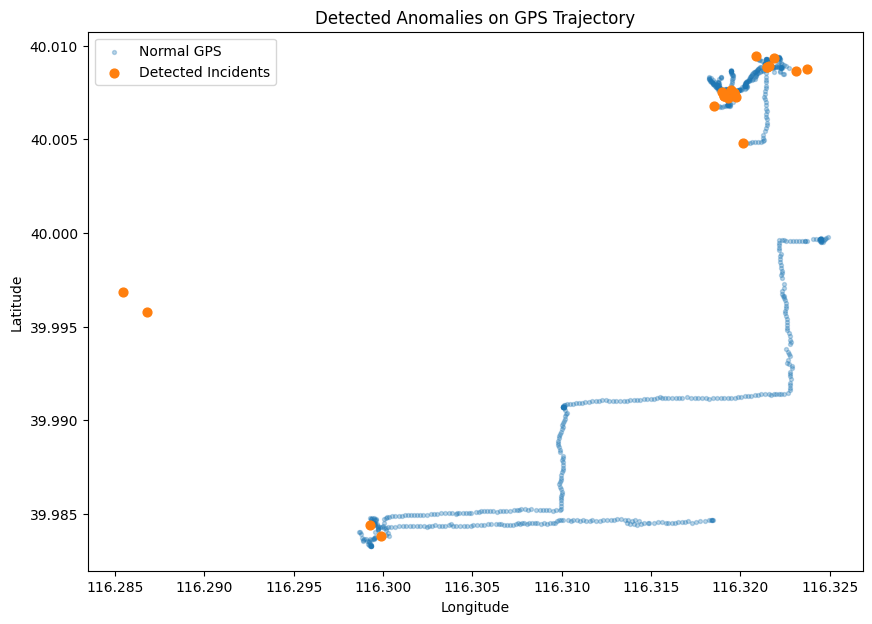

In [186]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.scatter(
    df["longitude"],
    df["latitude"],
    s=8,
    alpha=0.3,
    label="Normal GPS")
plt.scatter(
    incident_points["longitude"],
    incident_points["latitude"],
    s=40,
    label="Detected Incidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Detected Anomalies on GPS Trajectory")
plt.legend()
plt.show()

# Formal Model Evaluation / Proxy Evaluation

# Rule vs ML Agreement 

In [187]:
agreement_summary = pd.crosstab(
    df["ml_anomaly"],
    df["rule_anomaly_score"] >= 0.5,
    rownames=["ML Anomaly"],
    colnames=["Rule Anomaly"])
print(agreement_summary)

Rule Anomaly  False  True 
ML Anomaly                
False           844      0
True             64      8


# Agreement Percentage

In [188]:
agreement_rate = (
    df["model_agreement"].mean() * 100)
print(
    "Rule + ML agreement:",
    round(agreement_rate, 2),
    "%")

Rule + ML agreement: 0.87 %


# ML Anomaly Percentage

In [189]:
ml_anomaly_rate = (
    df["ml_anomaly"].mean() * 100)

print(
    "ML anomaly rate:",
    round(ml_anomaly_rate, 2),
    "%")

ML anomaly rate: 7.86 %


# Rule Anomaly Percentage

In [190]:
rule_anomaly_rate = (
    (df["rule_anomaly_score"] >= 0.5)
    .mean()
    * 100)

print(
    "Rule anomaly rate:",
    round(rule_anomaly_rate, 2),
    "%")

Rule anomaly rate: 0.87 %


# Hybrid Anomaly Percentage

In [191]:
hybrid_anomaly_rate = (
    (df["hybrid_risk_score"] >= 0.4)
    .mean()
    * 100)

print(
    "Hybrid anomaly rate:",
    round(hybrid_anomaly_rate, 2),
    "%")

Hybrid anomaly rate: 2.18 %


# Summary Table

In [192]:
evaluation_summary = pd.DataFrame({
    "metric": [
        "Rule anomaly rate",
        "ML anomaly rate",
        "Rule + ML agreement",
        "Hybrid anomaly rate"
    ],
    "percentage": [
        rule_anomaly_rate,
        ml_anomaly_rate,
        agreement_rate,
        hybrid_anomaly_rate
    ]
})

print(evaluation_summary)

                metric  percentage
0    Rule anomaly rate    0.873362
1      ML anomaly rate    7.860262
2  Rule + ML agreement    0.873362
3  Hybrid anomaly rate    2.183406


# Fix Agreement Matrices

# Correct Rule Vs ML Agreement

In [193]:
df["rule_anomaly_flag"] = (
    df["rule_anomaly_score"] >= 0.5)

df["ml_anomaly_flag"] = (
    df["ml_anomaly"] == True)

In [194]:
rule_flag = df["rule_anomaly_score"] >= 0.5

ml_flag = df["ml_anomaly"].astype(bool)

# Actual agreement
df["rule_ml_agreement"] = (
    rule_flag == ml_flag
)

actual_agreement_rate = (
    df["rule_ml_agreement"].mean() * 100
)

print(
    "Actual Rule + ML Agreement:",
    round(actual_agreement_rate, 2),
    "%"
)

# Agreement table
agreement_table = pd.crosstab(
    rule_flag,
    ml_flag,
    rownames=["Rule Anomaly"],
    colnames=["ML Anomaly"]
)

print("\nAgreement Table:")
print(agreement_table)

Actual Rule + ML Agreement: 93.01 %

Agreement Table:
ML Anomaly    False  True 
Rule Anomaly              
False           844     64
True              0      8


# Investigate 64 ML Anomalies

In [195]:
ml_only = df[
    (~rule_flag) &
    (ml_flag)
].copy()

print("ML-only anomalies:", len(ml_only))

print(
    ml_only[
        [
            "guard_id",
            "timestamp",
            "speed_kmh",
            "time_gap_seconds",
            "distance_from_previous_m",
            "distance_to_road_m",
            "gps_jump_flag",
            "hybrid_risk_score",
            "ml_anomaly"
        ]
    ]
    .sort_values(
        "hybrid_risk_score",
        ascending=False
    ) .head(30))

ML-only anomalies: 64
    guard_id           timestamp   speed_kmh  time_gap_seconds  \
470      000 2008-10-23 09:42:25    0.134025           18453.0   
148      000 2008-10-23 04:08:07    1.577309            3772.0   
149      000 2008-10-23 04:08:12  118.423778               5.0   
881      000 2008-10-23 10:44:31    0.654102             671.0   
794      000 2008-10-23 10:26:35    2.561721             319.0   
184      000 2008-10-23 04:11:22   75.080580               5.0   
903      000 2008-10-23 11:08:22    0.032082            1331.0   
613      000 2008-10-23 10:03:44   59.068105               5.0   
518      000 2008-10-23 09:49:55   56.832697               5.0   
694      000 2008-10-23 10:10:31    4.945601              25.0   
883      000 2008-10-23 10:44:41   36.703098               5.0   
693      000 2008-10-23 10:10:31    4.945601              25.0   
28       000 2008-10-23 02:55:25   41.891857               5.0   
687      000 2008-10-23 10:09:41    7.928869          

# Check Feature Statistics

In [196]:
print(
    ml_only[
        [
            "speed_kmh",
            "time_gap_seconds",
            "distance_from_previous_m",
            "distance_to_road_m"
        ]
    ].describe())

        speed_kmh  time_gap_seconds  distance_from_previous_m  \
count   64.000000         64.000000                 64.000000   
mean    11.583885        402.078125                 65.587337   
std     20.365286       2346.584092                222.017709   
min      0.000000          2.000000                  0.000000   
25%      0.735910          5.000000                  1.321347   
50%      3.985806          5.000000                 12.989050   
75%     12.398058          6.250000                 35.395605   
max    118.423778      18453.000000               1652.669139   

       distance_to_road_m  
count           64.000000  
mean            42.480072  
std             27.424925  
min              0.007636  
25%             13.576779  
50%             48.971838  
75%             70.676181  
max             73.416663  


# ML Only Anomalies

In [197]:
ml_only_analysis = ml_only.copy()

ml_only_analysis["long_gap"] = (
    ml_only_analysis["time_gap_seconds"] > 60)

ml_only_analysis["large_distance_jump"] = (
    ml_only_analysis["distance_from_previous_m"] > 50)

ml_only_analysis["road_deviation"] = (
    ml_only_analysis["distance_to_road_m"] > 50)

ml_only_analysis["high_speed"] = (
    ml_only_analysis["speed_kmh"] > 50)

print(
    ml_only_analysis[
        [
            "long_gap",
            "large_distance_jump",
            "road_deviation",
            "high_speed"
        ]
    ].sum())

long_gap                9
large_distance_jump    14
road_deviation         31
high_speed              4
dtype: int64


# Combined Suspiciousness

In [198]:
ml_only_analysis["supporting_rules"] = (
    ml_only_analysis[
        [
            "long_gap",
            "large_distance_jump",
            "road_deviation",
            "high_speed"
        ]
    ].sum(axis=1)
)

print(
    ml_only_analysis["supporting_rules"]
    .value_counts()
    .sort_index())

supporting_rules
0    15
1    40
2     9
Name: count, dtype: int64


# Rule _ Score Calibration

In [199]:
print(
    ml_only[
        [
            "rule_anomaly_score",
            "hybrid_risk_score",
            "speed_kmh",
            "time_gap_seconds",
            "distance_from_previous_m",
            "distance_to_road_m"
        ]
    ]
    .sort_values(
        "rule_anomaly_score",
        ascending=False
    )
    .head(30)
)

     rule_anomaly_score  hybrid_risk_score   speed_kmh  time_gap_seconds  \
28                 0.25           0.388142   41.891857               5.0   
148                0.25           0.521173    1.577309            3772.0   
149                0.25           0.478959  118.423778               5.0   
184                0.25           0.448723   75.080580               5.0   
388                0.25           0.291683   17.854334               5.0   
392                0.25           0.362284   24.902505               5.0   
395                0.25           0.279449   15.653265               5.0   
416                0.25           0.310051   26.139952               5.0   
426                0.25           0.318714   15.058275               5.0   
470                0.25           0.530356    0.134025           18453.0   
518                0.25           0.420441   56.832697               5.0   
514                0.25           0.339564    0.317855             205.0   
652         

# Rule Score Distribution

In [200]:
print(
    ml_only["rule_anomaly_score"]
    .describe())

count    64.000000
mean      0.210938
std       0.091491
min       0.000000
25%       0.250000
50%       0.250000
75%       0.250000
max       0.250000
Name: rule_anomaly_score, dtype: float64


# Test Different Threshold rule

In [201]:
thresholds = [0.25, 0.30, 0.40, 0.50]

for threshold in thresholds:

    rule_flag_test = (
        df["rule_anomaly_score"] >= threshold )

    ml_flag_test = df["ml_anomaly"].astype(bool)

    agreement = (
        rule_flag_test == ml_flag_test
    ).mean() * 100

    rule_rate = (
        rule_flag_test.mean() * 100 )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Rule anomaly: {rule_rate:.2f}% | "
        f"Agreement: {agreement:.2f}%" )

Threshold: 0.25 | Rule anomaly: 13.65% | Agreement: 92.03%
Threshold: 0.30 | Rule anomaly: 0.87% | Agreement: 93.01%
Threshold: 0.40 | Rule anomaly: 0.87% | Agreement: 93.01%
Threshold: 0.50 | Rule anomaly: 0.87% | Agreement: 93.01%


# Rule Score Distribution

In [202]:
print(
    df["rule_anomaly_score"]
    .value_counts()
    .sort_index())

rule_anomaly_score
0.00    791
0.25    117
0.50      8
Name: count, dtype: int64


In [203]:
print(
    sorted(
        df["rule_anomaly_score"]
        .unique()))

[np.float64(0.0), np.float64(0.25), np.float64(0.5)]


In [204]:
print(
    df[
        df["rule_anomaly_score"] > 0
    ][
        [
            "rule_anomaly_score",
            "speed_kmh",
            "time_gap_seconds",
            "distance_from_previous_m",
            "distance_to_road_m"
        ]
    ]
    .sort_values(
        "rule_anomaly_score",
        ascending=False
    ) .head(20))

     rule_anomaly_score   speed_kmh  time_gap_seconds  \
150                0.50  218.147174              30.0   
739                0.50   16.349874               5.0   
737                0.50   24.660005               5.0   
738                0.50   17.142172               5.0   
685                0.50   25.242124              10.0   
823                0.50   22.530987              10.0   
743                0.50   19.224082              15.0   
769                0.50   61.286863               5.0   
28                 0.25   41.891857               5.0   
7                  0.25   15.430589               5.0   
9                  0.25   15.067123               5.0   
19                 0.25   16.107388               5.0   
6                  0.25   16.298570               5.0   
148                0.25    1.577309            3772.0   
149                0.25  118.423778               5.0   
184                0.25   75.080580               5.0   
185                0.25   16.98

# Highest Rule Anomalies

In [205]:
# Get highest rule-based anomaly observations
high_rule_anomalies = df[
    df["rule_anomaly_score"] == 0.50
].copy()

# Select important columns
high_rule_anomalies[
    [
        "rule_anomaly_score",
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m"
    ]
].sort_values(
    by="speed_kmh",
    ascending=False)

,rule_anomaly_score,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
150,0.5,218.147174,30.0,1817.893113,6.030698
769,0.5,61.286863,5.0,85.120643,51.471609
685,0.5,25.242124,10.0,70.117012,64.207894
737,0.5,24.660005,5.0,34.250007,58.134556
823,0.5,22.530987,10.0,62.586075,73.292997
743,0.5,19.224082,15.0,80.100343,67.976996
738,0.5,17.142172,5.0,23.808573,73.486863
739,0.5,16.349874,5.0,22.708158,55.712743


# Verify Count

In [206]:
print("High rule anomalies:", len(high_rule_anomalies))

High rule anomalies: 8


# High Rule Anomalies in Readable Form 

In [207]:
pd.set_option("display.max_columns", None)

high_rule_anomalies[
    [
        "rule_anomaly_score",
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m"
    ]
]

,rule_anomaly_score,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
150,0.5,218.147174,30.0,1817.893113,6.030698
685,0.5,25.242124,10.0,70.117012,64.207894
737,0.5,24.660005,5.0,34.250007,58.134556
738,0.5,17.142172,5.0,23.808573,73.486863
739,0.5,16.349874,5.0,22.708158,55.712743
743,0.5,19.224082,15.0,80.100343,67.976996
769,0.5,61.286863,5.0,85.120643,51.471609
823,0.5,22.530987,10.0,62.586075,73.292997


# Anomalies Reasons 

In [208]:
# Show the main features for rule-based anomalies
anomaly_rows = df[df["rule_anomaly_score"] > 0].copy()

anomaly_rows[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "rule_anomaly_score"
    ]
].sort_values(
    "rule_anomaly_score",
    ascending=False
).head(20)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,rule_anomaly_score
150,218.147174,30.0,1817.893113,6.030698,0.50
739,16.349874,5.0,22.708158,55.712743,0.50
737,24.660005,5.0,34.250007,58.134556,0.50
738,17.142172,5.0,23.808573,73.486863,0.50
685,25.242124,10.0,70.117012,64.207894,0.50
823,22.530987,10.0,62.586075,73.292997,0.50
743,19.224082,15.0,80.100343,67.976996,0.50
769,61.286863,5.0,85.120643,51.471609,0.50
28,41.891857,5.0,58.183135,7.232476,0.25
7,15.430589,5.0,21.431374,6.907046,0.25


# Create Anomalies Reasons

In [209]:
def get_anomaly_reasons(row):
    reasons = []

    if row["speed_kmh"] > 100:
        reasons.append("High Speed")

    if row["time_gap_seconds"] > 300:
        reasons.append("Large Time Gap")

    if row["distance_from_previous_m"] > 100:
        reasons.append("Large Distance Jump")

    if row["distance_to_road_m"] > 50:
        reasons.append("Far From Road")

    return ", ".join(reasons)

df["anomaly_reason"] = df.apply(get_anomaly_reasons, axis=1)

# Anomalies Result

In [210]:
anomaly_reasons = df[df["rule_anomaly_score"] > 0][
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "rule_anomaly_score",
        "anomaly_reason"
    ]
].sort_values(
    "rule_anomaly_score",
    ascending=False
)

anomaly_reasons.head(30)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,rule_anomaly_score,anomaly_reason
150,218.147174,30.0,1817.893113,6.030698,0.50,"High Speed, Large Distance Jump"
739,16.349874,5.0,22.708158,55.712743,0.50,Far From Road
737,24.660005,5.0,34.250007,58.134556,0.50,Far From Road
738,17.142172,5.0,23.808573,73.486863,0.50,Far From Road
685,25.242124,10.0,70.117012,64.207894,0.50,Far From Road
823,22.530987,10.0,62.586075,73.292997,0.50,Far From Road
743,19.224082,15.0,80.100343,67.976996,0.50,Far From Road
769,61.286863,5.0,85.120643,51.471609,0.50,Far From Road
28,41.891857,5.0,58.183135,7.232476,0.25,
7,15.430589,5.0,21.431374,6.907046,0.25,


# Individual Rules Inspect 

In [211]:
# Inspect each anomaly rule separately

speed_anomalies = df[df["speed_kmh"] > 100]
time_gap_anomalies = df[df["time_gap_seconds"] > 300]
distance_anomalies = df[df["distance_from_previous_m"] > 100]
road_anomalies = df[df["distance_to_road_m"] > 50]

print("High Speed anomalies:", len(speed_anomalies))
print("Large Time Gap anomalies:", len(time_gap_anomalies))
print("Large Distance Jump anomalies:", len(distance_anomalies))
print("Far From Road anomalies:", len(road_anomalies))

High Speed anomalies: 2
Large Time Gap anomalies: 6
Large Distance Jump anomalies: 8
Far From Road anomalies: 70


# Rule-based Anomalies

In [212]:
print("\n--- High Speed ---")
display(
    speed_anomalies[
        ["speed_kmh", "time_gap_seconds",
         "distance_from_previous_m", "distance_to_road_m"]
    ].head(10)
)

print("\n--- Large Time Gap ---")
display(
    time_gap_anomalies[
        ["speed_kmh", "time_gap_seconds",
         "distance_from_previous_m", "distance_to_road_m"]
    ].head(10)
)

print("\n--- Large Distance Jump ---")
display(
    distance_anomalies[
        ["speed_kmh", "time_gap_seconds",
         "distance_from_previous_m", "distance_to_road_m"]
    ].head(10)
)

print("\n--- Far From Road ---")
display(
    road_anomalies[
        ["speed_kmh", "time_gap_seconds",
         "distance_from_previous_m", "distance_to_road_m"]
    ].head(10)
)


--- High Speed ---


,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
149,118.423778,5.0,164.477469,1.506708
150,218.147174,30.0,1817.893113,6.030698



--- Large Time Gap ---


,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
148,1.577309,3772.0,1652.669139,10.987361
470,0.134025,18453.0,686.989499,0.007636
606,0.292582,338.0,27.470228,4.793112
794,2.561721,319.0,226.996955,32.010601
881,0.654102,671.0,121.917427,22.854007
903,0.032082,1331.0,11.861401,9.406038



--- Large Distance Jump ---


,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
148,1.577309,3772.0,1652.669139,10.987361
149,118.423778,5.0,164.477469,1.506708
150,218.147174,30.0,1817.893113,6.030698
184,75.080580,5.0,104.278583,0.941744
470,0.134025,18453.0,686.989499,0.007636
736,12.148772,45.0,151.859654,32.052942
794,2.561721,319.0,226.996955,32.010601
881,0.654102,671.0,121.917427,22.854007



--- Far From Road ---


,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
650,10.352884,5.0,14.379006,52.073291
651,3.653034,5.0,5.073659,56.138074
652,0.000000,3.0,0.000000,56.138074
653,0.610222,2.0,0.339012,56.346373
654,6.141002,5.0,8.529170,61.088165
655,8.698055,5.0,12.080632,63.132572
656,5.422839,5.0,7.531721,65.537715
657,9.399675,5.0,13.055105,71.372341
658,0.717516,5.0,0.996550,71.655706
659,2.086026,2.0,1.158903,71.930132


# False Positive Identification

# Rule Combination 

In [213]:
rule_summary = df[df["rule_anomaly_score"] > 0][
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "rule_anomaly_score",
        "anomaly_reason"
    ]
].copy()

rule_summary["anomaly_reason"] = rule_summary["anomaly_reason"].replace(
    "", "Unknown / Score Triggered")
rule_summary["anomaly_reason"].value_counts()

anomaly_reason
Far From Road                          70
Unknown / Score Triggered              46
Large Time Gap, Large Distance Jump     4
High Speed, Large Distance Jump         2
Large Time Gap                          2
Large Distance Jump                     1
Name: count, dtype: int64

# Suspicious Extreme 

In [214]:
extreme_anomalies = df[
    (df["speed_kmh"] > 100) |
    (df["time_gap_seconds"] > 300) |
    (df["distance_from_previous_m"] > 100)
][
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "rule_anomaly_score",
        "anomaly_reason"
    ]
]

extreme_anomalies.sort_values(
    "rule_anomaly_score",
    ascending=False)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,rule_anomaly_score,anomaly_reason
150,218.147174,30.0,1817.893113,6.030698,0.50,"High Speed, Large Distance Jump"
148,1.577309,3772.0,1652.669139,10.987361,0.25,"Large Time Gap, Large Distance Jump"
149,118.423778,5.0,164.477469,1.506708,0.25,"High Speed, Large Distance Jump"
184,75.080580,5.0,104.278583,0.941744,0.25,Large Distance Jump
470,0.134025,18453.0,686.989499,0.007636,0.25,"Large Time Gap, Large Distance Jump"
606,0.292582,338.0,27.470228,4.793112,0.25,Large Time Gap
794,2.561721,319.0,226.996955,32.010601,0.25,"Large Time Gap, Large Distance Jump"
881,0.654102,671.0,121.917427,22.854007,0.25,"Large Time Gap, Large Distance Jump"
903,0.032082,1331.0,11.861401,9.406038,0.25,Large Time Gap
736,12.148772,45.0,151.859654,32.052942,0.00,Large Distance Jump


# Far From - road cluster check 

In [215]:
far_road = df[df["distance_to_road_m"] > 50][
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "rule_anomaly_score",
        "anomaly_reason"
    ]
]

print("Total far-from-road points:", len(far_road))
print(
    "Average distance from road:",
    far_road["distance_to_road_m"].mean()
)
print(
    "Maximum distance from road:",
    far_road["distance_to_road_m"].max()
)

Total far-from-road points: 70
Average distance from road: 62.32013750939854
Maximum distance from road: 73.48686270897042


# Threshold Tuning

# Current Distribution 

In [216]:
print("Speed:")
print(df["speed_kmh"].describe())

print("\nTime Gap:")
print(df["time_gap_seconds"].describe())

print("\nDistance from Previous:")
print(df["distance_from_previous_m"].describe())

print("\nDistance to Road:")
print(df["distance_to_road_m"].describe())

Speed:
count    916.000000
mean       8.041133
std       10.077986
min        0.000000
25%        3.267734
50%        7.299305
75%       11.406490
max      218.147174
Name: speed_kmh, dtype: float64

Time Gap:
count      916.000000
mean        32.688865
std        624.015372
min          0.000000
25%          5.000000
50%          5.000000
75%          5.000000
max      18453.000000
Name: time_gap_seconds, dtype: float64

Distance from Previous:
count     916.000000
mean       16.392717
std        84.842050
min         0.000000
25%         4.665800
50%        10.494398
75%        16.027460
max      1817.893113
Name: distance_from_previous_m, dtype: float64

Distance to Road:
count    916.000000
mean      13.579800
std       16.865519
min        0.007636
25%        3.327606
50%        7.186341
75%       15.369943
max       73.486863
Name: distance_to_road_m, dtype: float64


# Useful PPercentile

In [217]:
features = [
    "speed_kmh",
    "time_gap_seconds",
    "distance_from_previous_m",
    "distance_to_road_m"]

df[features].quantile(
    [0.90, 0.95, 0.99, 0.995, 1.00])

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
0.900,13.385523,5.000,19.046721,36.167262
0.950,15.447793,5.000,22.437755,56.190148
0.990,25.262813,60.000,82.918535,71.613201
0.995,57.782745,327.075,157.222225,73.292997
1.000,218.147174,18453.000,1817.893113,73.486863


# Tuned Threshold Preview

In [218]:
# Step 5.4 - Tuned threshold preview

df["tuned_rule_score"] = 0.0

df.loc[df["speed_kmh"] > 60, "tuned_rule_score"] += 0.25
df.loc[df["time_gap_seconds"] > 300, "tuned_rule_score"] += 0.25
df.loc[df["distance_from_previous_m"] > 150, "tuned_rule_score"] += 0.25
df.loc[df["distance_to_road_m"] > 50, "tuned_rule_score"] += 0.25

tuned_anomalies = df[df["tuned_rule_score"] > 0].copy()

print("Total tuned anomalies:", len(tuned_anomalies))

tuned_anomalies[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "tuned_rule_score"
    ]
].sort_values(
    "tuned_rule_score",
    ascending=False
).head(30)

Total tuned anomalies: 80


,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,tuned_rule_score
148,1.577309,3772.0,1652.669139,10.987361,0.50
149,118.423778,5.0,164.477469,1.506708,0.50
150,218.147174,30.0,1817.893113,6.030698,0.50
470,0.134025,18453.0,686.989499,0.007636,0.50
769,61.286863,5.0,85.120643,51.471609,0.50
794,2.561721,319.0,226.996955,32.010601,0.50
184,75.080580,5.0,104.278583,0.941744,0.25
606,0.292582,338.0,27.470228,4.793112,0.25
652,0.000000,3.0,0.000000,56.138074,0.25
653,0.610222,2.0,0.339012,56.346373,0.25


## ML Based Anomaly Detection 

# Behavioral Features

In [219]:
ml_features = [
    "speed_kmh",
    "time_gap_seconds",
    "distance_from_previous_m",
    "distance_to_road_m"]

X = df[ml_features].copy()
X.head()

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
0,0.000000,0.0,0.000000,5.513269
1,2.112417,6.0,3.520694,3.297444
2,2.043534,5.0,2.838241,3.738673
3,1.974399,5.0,2.742220,4.065703
4,7.952992,5.0,11.045822,0.806703


# Check Missing Values

In [220]:
print("Missing values:")
print(X.isnull().sum())
print("\nTotal rows:", len(X))

Missing values:
speed_kmh                   0
time_gap_seconds            0
distance_from_previous_m    0
distance_to_road_m          0
dtype: int64

Total rows: 916


# Train Isolation Forest 

In [221]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42)

df["ml_anomaly_label"] = iso_forest.fit_predict(X)

df["ml_anomaly_score"] = -iso_forest.score_samples(X)

print(df["ml_anomaly_label"].value_counts())

ml_anomaly_label
 1    870
-1     46
Name: count, dtype: int64


# Inspect ML Anomalies

In [222]:
ml_anomalies = df[df["ml_anomaly_label"] == -1].copy()

ml_anomalies[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "ml_anomaly_score",
        "tuned_rule_score"
    ]
].sort_values(
    "ml_anomaly_score",
    ascending=False
).head(30)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,ml_anomaly_score,tuned_rule_score
148,1.577309,3772.0,1652.669139,10.987361,0.830965,0.50
150,218.147174,30.0,1817.893113,6.030698,0.824821,0.50
470,0.134025,18453.0,686.989499,0.007636,0.820159,0.50
149,118.423778,5.0,164.477469,1.506708,0.749267,0.50
794,2.561721,319.0,226.996955,32.010601,0.748672,0.50
881,0.654102,671.0,121.917427,22.854007,0.748259,0.25
769,61.286863,5.0,85.120643,51.471609,0.722922,0.50
184,75.080580,5.0,104.278583,0.941744,0.711476,0.25
743,19.224082,15.0,80.100343,67.976996,0.705456,0.25
823,22.530987,10.0,62.586075,73.292997,0.705444,0.25


# ML vs Rule Detection Compare

In [223]:
print("Rule anomalies:",
      (df["tuned_rule_score"] > 0).sum())

print("ML anomalies:",
      (df["ml_anomaly_label"] == -1).sum())

print(
    "Both Rule + ML:",
    (
        (df["tuned_rule_score"] > 0) &
        (df["ml_anomaly_label"] == -1)
    ).sum())

print(
    "ML only:",
    (
        (df["tuned_rule_score"] == 0) &
        (df["ml_anomaly_label"] == -1)
    ).sum())

print(
    "Rule only:",
    (
        (df["tuned_rule_score"] > 0) &
        (df["ml_anomaly_label"] != -1)
    ).sum())

Rule anomalies: 80
ML anomalies: 46
Both Rule + ML: 31
ML only: 15
Rule only: 49


# Normalize ML Score

In [224]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["ml_score_normalized"] = scaler.fit_transform(
    df[["ml_anomaly_score"]])
df[
    [
        "ml_anomaly_score",
        "ml_score_normalized"
    ]
].head()

,ml_anomaly_score,ml_score_normalized
0,0.472983,0.257548
1,0.396574,0.099077
2,0.374860,0.054041
3,0.373842,0.051929
4,0.370798,0.045616


# create Hybrid Score

In [225]:
df["hybrid_anomaly_score"] = (
    0.5 * df["tuned_rule_score"] +
    0.5 * df["ml_score_normalized"])

# Inspect Hybrid Score

In [226]:
hybrid_anomalies = df.sort_values(
    "hybrid_anomaly_score",
    ascending=False)

hybrid_anomalies[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "tuned_rule_score",
        "ml_score_normalized",
        "hybrid_anomaly_score"
    ]
].head(30)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,tuned_rule_score,ml_score_normalized,hybrid_anomaly_score
148,1.577309,3772.0,1652.669139,10.987361,0.50,1.000000,0.750000
150,218.147174,30.0,1817.893113,6.030698,0.50,0.987257,0.743628
470,0.134025,18453.0,686.989499,0.007636,0.50,0.977588,0.738794
149,118.423778,5.0,164.477469,1.506708,0.50,0.830559,0.665279
794,2.561721,319.0,226.996955,32.010601,0.50,0.829324,0.664662
769,61.286863,5.0,85.120643,51.471609,0.50,0.775919,0.637960
881,0.654102,671.0,121.917427,22.854007,0.25,0.828467,0.539234
184,75.080580,5.0,104.278583,0.941744,0.25,0.752180,0.501090
743,19.224082,15.0,80.100343,67.976996,0.25,0.739694,0.494847
823,22.530987,10.0,62.586075,73.292997,0.25,0.739670,0.494835


# Create Risk Level 

In [227]:
def assign_risk_level(score):
    if score >= 0.70:
        return "Critical"
    elif score >= 0.50:
        return "High"
    elif score >= 0.30:
        return "Medium"
    elif score >= 0.15:
        return "Low"
    else:
        return "Normal"
df["risk_level"] = df["hybrid_anomaly_score"].apply(assign_risk_level)

# Check Risk Distribution

In [228]:
risk_counts = df["risk_level"].value_counts()
print(risk_counts)

risk_level
Normal      812
Low          61
Medium       35
High          5
Critical      3
Name: count, dtype: int64


# percentage

In [229]:
risk_percentages = (
    df["risk_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2))
print(risk_percentages)

risk_level
Normal      88.65
Low          6.66
Medium       3.82
High         0.55
Critical     0.33
Name: proportion, dtype: float64


# High Risk Records

In [230]:
final_anomalies = df[
    df["risk_level"].isin(["Critical", "High"])
].copy()

final_anomalies[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "tuned_rule_score",
        "ml_score_normalized",
        "hybrid_anomaly_score",
        "risk_level"
    ]
].sort_values(
    "hybrid_anomaly_score",
    ascending=False
).head(30)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,tuned_rule_score,ml_score_normalized,hybrid_anomaly_score,risk_level
148,1.577309,3772.0,1652.669139,10.987361,0.50,1.000000,0.750000,Critical
150,218.147174,30.0,1817.893113,6.030698,0.50,0.987257,0.743628,Critical
470,0.134025,18453.0,686.989499,0.007636,0.50,0.977588,0.738794,Critical
149,118.423778,5.0,164.477469,1.506708,0.50,0.830559,0.665279,High
794,2.561721,319.0,226.996955,32.010601,0.50,0.829324,0.664662,High
769,61.286863,5.0,85.120643,51.471609,0.50,0.775919,0.637960,High
881,0.654102,671.0,121.917427,22.854007,0.25,0.828467,0.539234,High
184,75.080580,5.0,104.278583,0.941744,0.25,0.752180,0.501090,High


# Check High/Critical Anomalies

In [231]:
high_risk = df[
    df["risk_level"].isin(["High", "Critical"])
].copy()

high_risk[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "tuned_rule_score",
        "ml_score_normalized",
        "hybrid_anomaly_score",
        "risk_level"
    ]
].sort_values(
    "hybrid_anomaly_score",
    ascending=False)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,tuned_rule_score,ml_score_normalized,hybrid_anomaly_score,risk_level
148,1.577309,3772.0,1652.669139,10.987361,0.50,1.000000,0.750000,Critical
150,218.147174,30.0,1817.893113,6.030698,0.50,0.987257,0.743628,Critical
470,0.134025,18453.0,686.989499,0.007636,0.50,0.977588,0.738794,Critical
149,118.423778,5.0,164.477469,1.506708,0.50,0.830559,0.665279,High
794,2.561721,319.0,226.996955,32.010601,0.50,0.829324,0.664662,High
769,61.286863,5.0,85.120643,51.471609,0.50,0.775919,0.637960,High
881,0.654102,671.0,121.917427,22.854007,0.25,0.828467,0.539234,High
184,75.080580,5.0,104.278583,0.941744,0.25,0.752180,0.501090,High


# Check Why Each High-Risk Point Was Detected

In [232]:
high_risk[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "anomaly_reason",
        "tuned_rule_score",
        "ml_score_normalized",
        "hybrid_anomaly_score",
        "risk_level"
    ]
].sort_values(
    "hybrid_anomaly_score",
    ascending=False)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,anomaly_reason,tuned_rule_score,ml_score_normalized,hybrid_anomaly_score,risk_level
148,1.577309,3772.0,1652.669139,10.987361,"Large Time Gap, Large Distance Jump",0.50,1.000000,0.750000,Critical
150,218.147174,30.0,1817.893113,6.030698,"High Speed, Large Distance Jump",0.50,0.987257,0.743628,Critical
470,0.134025,18453.0,686.989499,0.007636,"Large Time Gap, Large Distance Jump",0.50,0.977588,0.738794,Critical
149,118.423778,5.0,164.477469,1.506708,"High Speed, Large Distance Jump",0.50,0.830559,0.665279,High
794,2.561721,319.0,226.996955,32.010601,"Large Time Gap, Large Distance Jump",0.50,0.829324,0.664662,High
769,61.286863,5.0,85.120643,51.471609,Far From Road,0.50,0.775919,0.637960,High
881,0.654102,671.0,121.917427,22.854007,"Large Time Gap, Large Distance Jump",0.25,0.828467,0.539234,High
184,75.080580,5.0,104.278583,0.941744,Large Distance Jump,0.25,0.752180,0.501090,High


## Compare All Detection Categories

In [233]:
# Step 8.1 - Detection category analysis

df["detection_category"] = "Normal"

df.loc[
    (df["tuned_rule_score"] > 0) &
    (df["ml_anomaly_label"] == -1),
    "detection_category"
] = "Rule + ML"

df.loc[
    (df["tuned_rule_score"] > 0) &
    (df["ml_anomaly_label"] != -1),
    "detection_category"
] = "Rule Only"

df.loc[
    (df["tuned_rule_score"] == 0) &
    (df["ml_anomaly_label"] == -1),
    "detection_category"
] = "ML Only"

print(df["detection_category"].value_counts())

detection_category
Normal       821
Rule Only     49
Rule + ML     31
ML Only       15
Name: count, dtype: int64


# High/Critical Detection Categories

In [234]:
# Step 8.2 - High/Critical validation

high_critical = df[
    df["risk_level"].isin(["High", "Critical"])
].copy()

print(
    high_critical["detection_category"].value_counts())

detection_category
Rule + ML    8
Name: count, dtype: int64


# ML Only Anomalies

In [236]:
# Step 8.3 - Inspect ML-only anomalies

ml_only = df[
    (df["detection_category"] == "ML Only")
].copy()

ml_only[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "ml_score_normalized",
        "hybrid_anomaly_score",
        "risk_level"
    ]
].sort_values(
    "ml_score_normalized",
    ascending=False
).head(30)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,ml_score_normalized,hybrid_anomaly_score,risk_level
518,56.832697,5.0,78.934301,0.081989,0.693136,0.346568,Medium
613,59.068105,5.0,82.039035,8.748414,0.680536,0.340268,Medium
883,36.703098,5.0,50.976525,38.954713,0.660053,0.330027,Medium
612,4.272364,70.0,83.073741,12.846230,0.657516,0.328758,Medium
515,13.145917,20.0,73.032871,30.468606,0.602305,0.301152,Medium
28,41.891857,5.0,58.183135,7.232476,0.588934,0.294467,Low
906,3.699249,60.0,61.654152,0.455028,0.567002,0.283501,Low
757,21.501286,5.0,29.862897,43.072036,0.522337,0.261168,Low
904,2.524396,60.0,42.073264,9.123582,0.503912,0.251956,Low
905,24.183184,5.0,33.587756,27.084074,0.499693,0.249846,Low


# Separate Ml - only Cases by Severity 

In [237]:
# Step 8.4 - ML-only anomaly severity

ml_only_summary = (
    ml_only["risk_level"]
    .value_counts()
    .reindex(
        ["Critical", "High", "Medium", "Low", "Normal"],
        fill_value=0))

print(ml_only_summary)

risk_level
Critical     0
High         0
Medium       5
Low         10
Normal       0
Name: count, dtype: int64


In [238]:
# Top ML-only anomalies

ml_only[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "ml_score_normalized",
        "hybrid_anomaly_score",
        "risk_level"
    ]
].sort_values(
    "hybrid_anomaly_score",
    ascending=False
)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,ml_score_normalized,hybrid_anomaly_score,risk_level
518,56.832697,5.0,78.934301,0.081989,0.693136,0.346568,Medium
613,59.068105,5.0,82.039035,8.748414,0.680536,0.340268,Medium
883,36.703098,5.0,50.976525,38.954713,0.660053,0.330027,Medium
612,4.272364,70.0,83.073741,12.846230,0.657516,0.328758,Medium
515,13.145917,20.0,73.032871,30.468606,0.602305,0.301152,Medium
28,41.891857,5.0,58.183135,7.232476,0.588934,0.294467,Low
906,3.699249,60.0,61.654152,0.455028,0.567002,0.283501,Low
757,21.501286,5.0,29.862897,43.072036,0.522337,0.261168,Low
904,2.524396,60.0,42.073264,9.123582,0.503912,0.251956,Low
905,24.183184,5.0,33.587756,27.084074,0.499693,0.249846,Low


# Rule Only Anomalies

There are **49 rule-only points that the ML model did not classify as anomalies**. These are important to inspect as **false-positive candidates**.

In [239]:
# Step 8.5 - Rule-only anomaly inspection

rule_only = df[
    df["detection_category"] == "Rule Only"
].copy()

print("Rule-only anomalies:", len(rule_only))

rule_only[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "anomaly_reason",
        "tuned_rule_score",
        "ml_score_normalized",
        "hybrid_anomaly_score",
        "risk_level"
    ]
].sort_values(
    "tuned_rule_score",
    ascending=False
).head(30)

Rule-only anomalies: 49


,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,anomaly_reason,tuned_rule_score,ml_score_normalized,hybrid_anomaly_score,risk_level
650,10.352884,5.0,14.379006,52.073291,Far From Road,0.25,0.274171,0.262086,Low
651,3.653034,5.0,5.073659,56.138074,Far From Road,0.25,0.229470,0.239735,Low
654,6.141002,5.0,8.529170,61.088165,Far From Road,0.25,0.277247,0.263623,Low
655,8.698055,5.0,12.080632,63.132572,Far From Road,0.25,0.323564,0.286782,Low
656,5.422839,5.0,7.531721,65.537715,Far From Road,0.25,0.306850,0.278425,Low
657,9.399675,5.0,13.055105,71.372341,Far From Road,0.25,0.386348,0.318174,Medium
658,0.717516,5.0,0.996550,71.655706,Far From Road,0.25,0.379697,0.314848,Medium
660,3.512380,5.0,4.878306,69.978994,Far From Road,0.25,0.311180,0.280590,Low
661,2.084672,5.0,2.895378,69.227151,Far From Road,0.25,0.312176,0.281088,Low
662,0.742042,5.0,1.030614,68.665562,Far From Road,0.25,0.356038,0.303019,Medium


Fix Far-From-Road Rule

In [240]:
# Step 8.6 - Refine road-distance threshold

df["tuned_rule_score_v2"] = 0.0

df.loc[df["speed_kmh"] > 60, "tuned_rule_score_v2"] += 0.25
df.loc[df["time_gap_seconds"] > 300, "tuned_rule_score_v2"] += 0.25
df.loc[df["distance_from_previous_m"] > 150, "tuned_rule_score_v2"] += 0.25
df.loc[df["distance_to_road_m"] > 70, "tuned_rule_score_v2"] += 0.25

# Compare old vs new

In [241]:
print(
    "Old rule anomalies:",
    (df["tuned_rule_score"] > 0).sum())

print(
    "New rule anomalies:",
    (df["tuned_rule_score_v2"] > 0).sum())

print(
    "Old road-distance anomalies:",
    (df["distance_to_road_m"] > 50).sum())

print(
    "New road-distance anomalies:",
    (df["distance_to_road_m"] > 70).sum())

Old rule anomalies: 80
New rule anomalies: 31
Old road-distance anomalies: 70
New road-distance anomalies: 20


# Show Remains

In [242]:
road_v2 = df[
    df["distance_to_road_m"] > 70
][
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m"
    ]]

road_v2.sort_values(
    "distance_to_road_m",
    ascending=False)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m
738,17.142172,5.0,23.808573,73.486863
699,3.156022,5.0,4.383364,73.416663
700,3.156022,5.0,4.383364,73.416663
688,5.473022,5.0,7.601420,73.343893
823,22.530987,10.0,62.586075,73.292997
824,0.000000,3.0,0.000000,73.292997
825,0.366647,2.0,0.203693,73.191079
687,7.928869,10.0,22.024635,72.832664
659,2.086026,2.0,1.158903,71.930132
658,0.717516,5.0,0.996550,71.655706


# Group Consecutive Road Deviations

In [243]:
# Step 8.7 - Detect continuous far-from-road segments

df["far_from_road"] = df["distance_to_road_m"] > 70

df["road_deviation_group"] = (
    df["far_from_road"] != df["far_from_road"].shift()
).cumsum()

road_groups = (
    df[df["far_from_road"]]
    .groupby("road_deviation_group")
    .agg(
        start_index=("distance_to_road_m", lambda x: x.index.min()),
        end_index=("distance_to_road_m", lambda x: x.index.max()),
        points=("distance_to_road_m", "count"),
        max_distance=("distance_to_road_m", "max"),
        avg_distance=("distance_to_road_m", "mean")
    )
    .reset_index(drop=True)
)

road_groups

,start_index,end_index,points,max_distance,avg_distance
0,657,659,3,71.930132,71.652726
1,686,688,3,73.343893,72.432346
2,693,701,9,73.416663,71.443637
3,738,738,1,73.486863,73.486863
4,823,826,4,73.292997,72.681309


# Group Summary

In [244]:
print("Total far-from-road points:", len(df[df["far_from_road"]]))
print("Continuous road-deviation groups:", len(road_groups))
road_groups

Total far-from-road points: 20
Continuous road-deviation groups: 5


,start_index,end_index,points,max_distance,avg_distance
0,657,659,3,71.930132,71.652726
1,686,688,3,73.343893,72.432346
2,693,701,9,73.416663,71.443637
3,738,738,1,73.486863,73.486863
4,823,826,4,73.292997,72.681309


# Ignore Very Short Isolated Deviations

In [245]:
road_groups_filtered = road_groups[
    road_groups["points"] >= 2
].copy()

print(
    "Sustained road-deviation groups:",
    len(road_groups_filtered))
road_groups_filtered

Sustained road-deviation groups: 4


,start_index,end_index,points,max_distance,avg_distance
0,657,659,3,71.930132,71.652726
1,686,688,3,73.343893,72.432346
2,693,701,9,73.416663,71.443637
4,823,826,4,73.292997,72.681309


# Final Tuned Role Score

In [246]:
# Step 8.8 - Final tuned rule score

df["sustained_far_from_road"] = False
for _, row in road_groups_filtered.iterrows():
    start = int(row["start_index"])
    end = int(row["end_index"])

    df.loc[start:end, "sustained_far_from_road"] = True

In [247]:
# Recalculate final rule score

df["final_rule_score"] = 0.0

df.loc[df["speed_kmh"] > 60, "final_rule_score"] += 0.25
df.loc[df["time_gap_seconds"] > 300, "final_rule_score"] += 0.25
df.loc[df["distance_from_previous_m"] > 150, "final_rule_score"] += 0.25

df.loc[
    df["sustained_far_from_road"],
    "final_rule_score"
] += 0.25

In [248]:
print(
    "Final rule anomalies:",
    (df["final_rule_score"] > 0).sum())

print(
    "Final rule score distribution:")

print(
    df["final_rule_score"].value_counts().sort_index())

Final rule anomalies: 30
Final rule score distribution:
final_rule_score
0.00    886
0.25     25
0.50      5
Name: count, dtype: int64


# Inspect Top Final Rule Anomalies

In [249]:
df[
    df["final_rule_score"] > 0
][
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "final_rule_score",
        "ml_score_normalized",
        "hybrid_anomaly_score",
        "risk_level"
    ]
].sort_values(
    "final_rule_score",
    ascending=False
).head(30)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,final_rule_score,ml_score_normalized,hybrid_anomaly_score,risk_level
148,1.577309,3772.0,1652.669139,10.987361,0.50,1.000000,0.750000,Critical
149,118.423778,5.0,164.477469,1.506708,0.50,0.830559,0.665279,High
150,218.147174,30.0,1817.893113,6.030698,0.50,0.987257,0.743628,Critical
470,0.134025,18453.0,686.989499,0.007636,0.50,0.977588,0.738794,Critical
794,2.561721,319.0,226.996955,32.010601,0.50,0.829324,0.664662,High
184,75.080580,5.0,104.278583,0.941744,0.25,0.752180,0.501090,High
657,9.399675,5.0,13.055105,71.372341,0.25,0.386348,0.318174,Medium
658,0.717516,5.0,0.996550,71.655706,0.25,0.379697,0.314848,Medium
659,2.086026,2.0,1.158903,71.930132,0.25,0.487765,0.368882,Medium
686,7.699996,5.0,10.694439,71.120480,0.25,0.370041,0.310021,Medium


# Recalculate Final Hybrid Score

In [250]:
# Step 8.9 - Final hybrid anomaly score

df["final_hybrid_score"] = (
    0.5 * df["final_rule_score"] +
    0.5 * df["ml_score_normalized"]
)

df[
    [
        "final_rule_score",
        "ml_score_normalized",
        "final_hybrid_score"
    ]
].sort_values(
    "final_hybrid_score",
    ascending=False
).head(30)

,final_rule_score,ml_score_normalized,final_hybrid_score
148,0.50,1.000000,0.750000
150,0.50,0.987257,0.743628
470,0.50,0.977588,0.738794
149,0.50,0.830559,0.665279
794,0.50,0.829324,0.664662
881,0.25,0.828467,0.539234
769,0.25,0.775919,0.512960
184,0.25,0.752180,0.501090
823,0.25,0.739670,0.494835
903,0.25,0.724245,0.487123


# Create Final Risk Levels

In [251]:
# Step 8.10 - Final risk classification

def assign_risk(score):
    if score >= 0.70:
        return "Critical"
    elif score >= 0.50:
        return "High"
    elif score >= 0.30:
        return "Medium"
    elif score >= 0.20:
        return "Low"
    else:
        return "Normal"

df["final_risk_level"] = df["final_hybrid_score"].apply(assign_risk)

print(
    df["final_risk_level"].value_counts()
)

final_risk_level
Normal      863
Medium       27
Low          18
High          5
Critical      3
Name: count, dtype: int64


## Final Anomaly Table

In [252]:
# Step 8.11 - Final anomaly table

final_anomalies = df[
    df["final_risk_level"].isin(
        ["Critical", "High", "Medium", "Low"]
    )
].copy()

final_anomalies[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "final_rule_score",
        "ml_score_normalized",
        "final_hybrid_score",
        "final_risk_level"
    ]
].sort_values(
    "final_hybrid_score",
    ascending=False
).head(30)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,final_rule_score,ml_score_normalized,final_hybrid_score,final_risk_level
148,1.577309,3772.0,1652.669139,10.987361,0.50,1.000000,0.750000,Critical
150,218.147174,30.0,1817.893113,6.030698,0.50,0.987257,0.743628,Critical
470,0.134025,18453.0,686.989499,0.007636,0.50,0.977588,0.738794,Critical
149,118.423778,5.0,164.477469,1.506708,0.50,0.830559,0.665279,High
794,2.561721,319.0,226.996955,32.010601,0.50,0.829324,0.664662,High
881,0.654102,671.0,121.917427,22.854007,0.25,0.828467,0.539234,High
769,61.286863,5.0,85.120643,51.471609,0.25,0.775919,0.512960,High
184,75.080580,5.0,104.278583,0.941744,0.25,0.752180,0.501090,High
823,22.530987,10.0,62.586075,73.292997,0.25,0.739670,0.494835,Medium
903,0.032082,1331.0,11.861401,9.406038,0.25,0.724245,0.487123,Medium


# Final Distribution 

In [253]:
# Step 8.12 - Final risk distribution

risk_summary = (
    df["final_risk_level"]
    .value_counts()
    .reindex(
        ["Normal", "Low", "Medium", "High", "Critical"],
        fill_value=0
    )
)

print(risk_summary)

print("\nPercentages:")
print(
    (risk_summary / len(df) * 100).round(2)
)

final_risk_level
Normal      863
Low          18
Medium       27
High          5
Critical      3
Name: count, dtype: int64

Percentages:
final_risk_level
Normal      94.21
Low          1.97
Medium       2.95
High         0.55
Critical     0.33
Name: count, dtype: float64


# What we have confirmed

Total GPS points: 916

Final rule anomalies: 30

ML anomalies: 46

# Final risk:

Normal: 863 (94.21%)

Low: 18 (1.97%)

Medium: 27 (2.95%)

High: 5 (0.55%)

Critical: 3 (0.33%)

The most important part is that the final system is now much more selective than the original rules:

Old rule anomalies: 80 → 30
Old road-distance anomalies: 70 → 20
Sustained road-deviation groups: 4
Final Critical cases: 3
Final High cases: 5

# Final Anomaly Validation

# Create Anomaly Flag

In [254]:
# Step 9.1 - Final anomaly flag

df["final_anomaly"] = (
    df["final_hybrid_score"] >= 0.35)
print(df["final_anomaly"].value_counts())

final_anomaly
False    892
True      24
Name: count, dtype: int64


# Count Final Anomalies by Risk Level

In [255]:
# Step 9.2 - Final anomaly distribution

final_anomalies = df[df["final_anomaly"]].copy()

print(
    final_anomalies["final_risk_level"].value_counts())

final_risk_level
Medium      16
High         5
Critical     3
Name: count, dtype: int64


# Inspect Final Anomalies

In [256]:
# Step 9.3 - Final anomaly inspection

final_anomalies[
    [
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "final_rule_score",
        "ml_score_normalized",
        "final_hybrid_score",
        "final_risk_level",
        "anomaly_reason"
    ]
].sort_values(
    "final_hybrid_score",
    ascending=False
).head(30)

,speed_kmh,time_gap_seconds,distance_from_previous_m,distance_to_road_m,final_rule_score,ml_score_normalized,final_hybrid_score,final_risk_level,anomaly_reason
148,1.577309,3772.0,1652.669139,10.987361,0.50,1.000000,0.750000,Critical,"Large Time Gap, Large Distance Jump"
150,218.147174,30.0,1817.893113,6.030698,0.50,0.987257,0.743628,Critical,"High Speed, Large Distance Jump"
470,0.134025,18453.0,686.989499,0.007636,0.50,0.977588,0.738794,Critical,"Large Time Gap, Large Distance Jump"
149,118.423778,5.0,164.477469,1.506708,0.50,0.830559,0.665279,High,"High Speed, Large Distance Jump"
794,2.561721,319.0,226.996955,32.010601,0.50,0.829324,0.664662,High,"Large Time Gap, Large Distance Jump"
881,0.654102,671.0,121.917427,22.854007,0.25,0.828467,0.539234,High,"Large Time Gap, Large Distance Jump"
769,61.286863,5.0,85.120643,51.471609,0.25,0.775919,0.512960,High,Far From Road
184,75.080580,5.0,104.278583,0.941744,0.25,0.752180,0.501090,High,Large Distance Jump
823,22.530987,10.0,62.586075,73.292997,0.25,0.739670,0.494835,Medium,Far From Road
903,0.032082,1331.0,11.861401,9.406038,0.25,0.724245,0.487123,Medium,Large Time Gap


# Check Anomaly Reason 

In [257]:
# Step 9.4 - Anomaly reason distribution

print(
    final_anomalies["anomaly_reason"].value_counts())

anomaly_reason
Far From Road                          14
Large Time Gap, Large Distance Jump     4
High Speed, Large Distance Jump         2
Large Distance Jump                     2
Large Time Gap                          2
Name: count, dtype: int64


# Spatial Validation

In [258]:
# Step 10.1 - Check coordinate columns

print(df.columns.tolist())

['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length', 'long_time_gap', 'high_speed', 'large_road_deviation', 'gps_jump_flag', 'anomaly_signal_count', 'extreme_speed', 'very_high_speed', 'extreme_road_deviation', 'very_large_road_deviation', 'critical_time_gap', 'high_time_gap', 'severity', 'rule_anomaly_score', 'ml_anomaly', 'ml_anomaly_score_raw', 'ml_anomaly_score', 'final_risk_score', 'is_anomaly', 'anomaly_reasons', 'rule_flag', 'ml_flag', 'session_break', 'session_number', 'patrol_id', 'anomaly_types', 'median_speed_kmh', 'median_time_gap_seconds', 'median_road_distance_m', 'speed_deviation_kmh', 'time_gap_deviation_seconds', 'road_distance_deviation_m', 'ml_prediction', 'hybrid_risk_score', 'model_agreement', 'hybrid_severity', 'incident_id', 'rule_anomaly_flag', 'ml_anomaly_flag', 'rule_ml_agreement', 'anomaly_reason', '

# Separate Normal and Final Anomalies

In [259]:
# Step 10.1 - Separate normal and anomalous GPS points

final_anomalies = df[df["final_anomaly"] == True].copy()
normal_points = df[df["final_anomaly"] == False].copy()

print("Normal points:", len(normal_points))
print("Final anomalies:", len(final_anomalies))

Normal points: 892
Final anomalies: 24


# Check Anomaly Coordinates

In [260]:
# Step 10.2 - Inspect anomaly coordinates

final_anomalies[
    [
        "latitude",
        "longitude",
        "final_hybrid_score",
        "final_risk_level",
        "anomaly_reason"
    ]
].sort_values(
    "final_hybrid_score",
    ascending=False)

,latitude,longitude,final_hybrid_score,final_risk_level,anomaly_reason
148,39.995777,116.286798,0.750000,Critical,"Large Time Gap, Large Distance Jump"
150,39.984397,116.299292,0.743628,Critical,"High Speed, Large Distance Jump"
470,40.004775,116.320158,0.738794,Critical,"Large Time Gap, Large Distance Jump"
149,39.996832,116.285446,0.665279,High,"High Speed, Large Distance Jump"
794,40.006747,116.318549,0.664662,High,"Large Time Gap, Large Distance Jump"
881,40.008761,116.323722,0.539234,High,"Large Time Gap, Large Distance Jump"
769,40.007645,116.319454,0.512960,High,Far From Road
184,39.983841,116.299902,0.501090,High,Large Distance Jump
823,40.007457,116.319674,0.494835,Medium,Far From Road
903,40.008851,116.321485,0.487123,Medium,Large Time Gap


# Check Anomaly Validity 

In [261]:
# Step 10.3 - Validate coordinates

print("Missing latitude:", df["latitude"].isna().sum())
print("Missing longitude:", df["longitude"].isna().sum())

print("Latitude range:",
      df["latitude"].min(),
      df["latitude"].max())

print("Longitude range:",
      df["longitude"].min(),
      df["longitude"].max())

Missing latitude: 0
Missing longitude: 0
Latitude range: 39.983276 40.009428
Longitude range: 116.285446 116.324886


# Plots Gps Routes

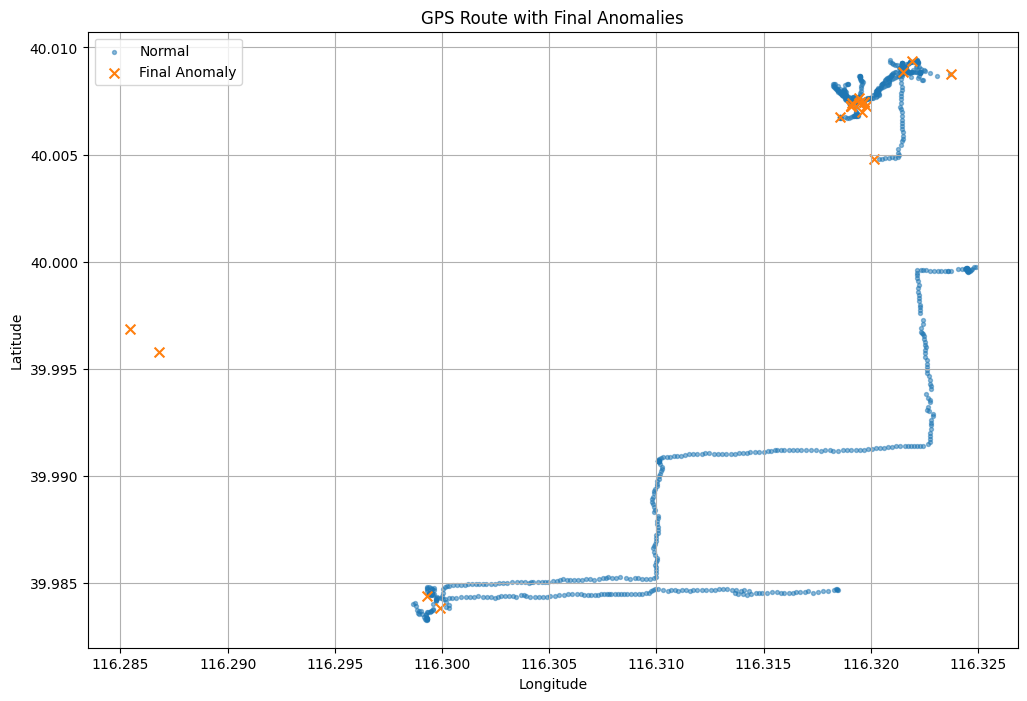

In [ ]:
#10.4 Create the first spatial visualization.

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Normal GPS points
plt.scatter(
    normal_points["longitude"],
    normal_points["latitude"],
    s=8,
    alpha=0.5,
    label="Normal")

# Final anomalies
plt.scatter(
    final_anomalies["longitude"],
    final_anomalies["latitude"],
    s=50,
    marker="x",
    label="Final Anomaly")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GPS Route with Final Anomalies")
plt.legend()
plt.grid(True)

plt.show()

# Highlight risk levels 

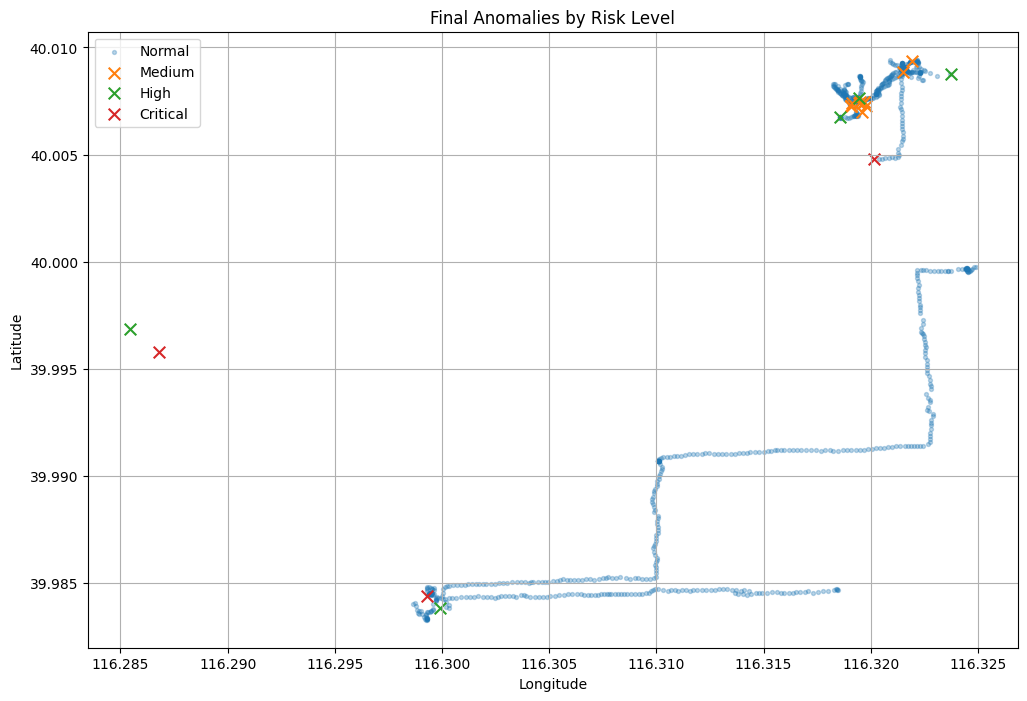

In [263]:
# Step 10.5 - Risk-level visualization

plt.figure(figsize=(12, 8))
plt.scatter(
    normal_points["longitude"],
    normal_points["latitude"],
    s=8,
    alpha=0.3,
    label="Normal")

risk_levels = ["Medium", "High", "Critical"]

for risk in risk_levels:

    subset = final_anomalies[
        final_anomalies["final_risk_level"] == risk
    ]

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        s=70,
        marker="x",
        label=risk)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Final Anomalies by Risk Level")
plt.legend()
plt.grid(True)

plt.show()

# Plot the actual route/path

The previous plots show points, but now we should see the movement sequence:

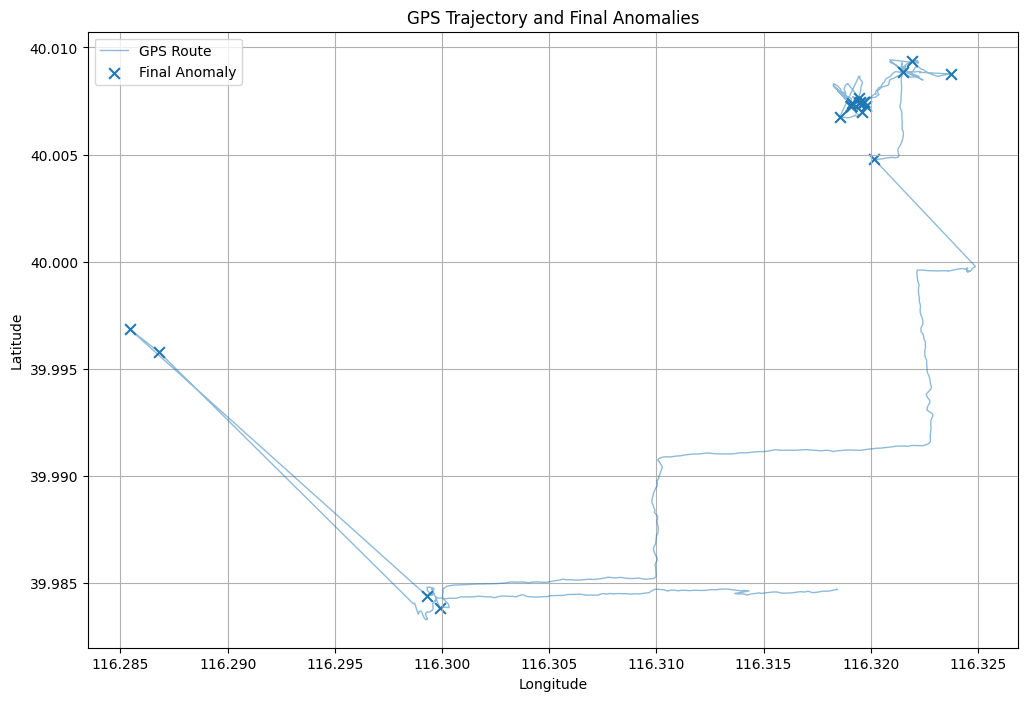

In [264]:
# Step 10.6 - GPS trajectory with anomaly points

plt.figure(figsize=(12, 8))

# Full GPS trajectory
plt.plot(
    df["longitude"],
    df["latitude"],
    linewidth=1,
    alpha=0.5,
    label="GPS Route")

# Final anomalies
plt.scatter(
    final_anomalies["longitude"],
    final_anomalies["latitude"],
    s=60,
    marker="x",
    label="Final Anomaly")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GPS Trajectory and Final Anomalies")
plt.legend()
plt.grid(True)

plt.show()

# Temporal / Sequential Validation.

# Sort data chronologically

In [265]:
# Step 11.1 - Sort GPS data chronologically

df = df.sort_values(
    ["guard_id", "timestamp"]
).reset_index(drop=True)

print(df[["guard_id", "timestamp"]].head())

  guard_id           timestamp
0      000 2008-10-23 02:53:04
1      000 2008-10-23 02:53:10
2      000 2008-10-23 02:53:15
3      000 2008-10-23 02:53:20
4      000 2008-10-23 02:53:25


# Inspect final anomalies in sequence

In [266]:
# Step 11.2 - Final anomalies with temporal context

temporal_anomalies = df[
    df["final_anomaly"] == True
].copy()

temporal_anomalies[
    [
        "guard_id",
        "timestamp",
        "patrol_id",
        "session_number",
        "latitude",
        "longitude",
        "time_gap_seconds",
        "speed_kmh",
        "distance_from_previous_m",
        "distance_to_road_m",
        "final_hybrid_score",
        "final_risk_level",
        "anomaly_reason"
    ]
].sort_values(
    "timestamp")

,guard_id,timestamp,patrol_id,session_number,latitude,longitude,time_gap_seconds,speed_kmh,distance_from_previous_m,distance_to_road_m,final_hybrid_score,final_risk_level,anomaly_reason
148,000,2008-10-23 04:08:07,000_PATROL_0002,2,39.995777,116.286798,3772.0,1.577309,1652.669139,10.987361,0.750000,Critical,"Large Time Gap, Large Distance Jump"
149,000,2008-10-23 04:08:12,000_PATROL_0002,2,39.996832,116.285446,5.0,118.423778,164.477469,1.506708,0.665279,High,"High Speed, Large Distance Jump"
150,000,2008-10-23 04:08:42,000_PATROL_0002,2,39.984397,116.299292,30.0,218.147174,1817.893113,6.030698,0.743628,Critical,"High Speed, Large Distance Jump"
184,000,2008-10-23 04:11:22,000_PATROL_0002,2,39.983841,116.299902,5.0,75.080580,104.278583,0.941744,0.501090,High,Large Distance Jump
470,000,2008-10-23 09:42:25,000_PATROL_0003,3,40.004775,116.320158,18453.0,0.134025,686.989499,0.007636,0.738794,Critical,"Large Time Gap, Large Distance Jump"
606,000,2008-10-23 10:02:04,000_PATROL_0003,3,40.009351,116.321916,338.0,0.292582,27.470228,4.793112,0.444847,Medium,Large Time Gap
659,000,2008-10-23 10:07:21,000_PATROL_0003,3,40.007462,116.319493,2.0,2.086026,1.158903,71.930132,0.368882,Medium,Far From Road
685,000,2008-10-23 10:09:26,000_PATROL_0003,3,40.007272,116.319756,10.0,25.242124,70.117012,64.207894,0.368795,Medium,Far From Road
687,000,2008-10-23 10:09:41,000_PATROL_0003,3,40.007428,116.319432,10.0,7.928869,22.024635,72.832664,0.402977,Medium,Far From Road
693,000,2008-10-23 10:10:31,000_PATROL_0003,3,40.007288,116.319088,25.0,4.945601,34.344452,70.915213,0.451322,Medium,Far From Road


# Check anomaly distribution by session

In [267]:
# Step 11.3 - Anomalies by patrol/session

print(
    temporal_anomalies[
        ["patrol_id", "session_number"]
    ].value_counts()
)

patrol_id        session_number
000_PATROL_0003  3                 20
000_PATROL_0002  2                  4
Name: count, dtype: int64


# Check whether anomalies are isolated or consecutive

In [ ]:
# Step 11.4 - Consecutive anomaly analysis

df["previous_final_anomaly"] = (
    df["final_anomaly"].shift(1))

df["consecutive_anomaly"] = (
    df["final_anomaly"] &
    df["previous_final_anomaly"])

print(
    "Consecutive anomaly points:",
    df["consecutive_anomaly"].sum())

Consecutive anomaly points: 9


# Check long time gaps among final anomalies

In [269]:
# Step 11.5 - Temporal gap analysis

print(
    temporal_anomalies[
        [
            "time_gap_seconds",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason"
        ]
    ].sort_values(
        "time_gap_seconds",
        ascending=False))

     time_gap_seconds  final_hybrid_score final_risk_level  \
470           18453.0            0.738794         Critical   
148            3772.0            0.750000         Critical   
903            1331.0            0.487123           Medium   
881             671.0            0.539234             High   
606             338.0            0.444847           Medium   
794             319.0            0.664662             High   
736              45.0            0.483912           Medium   
150              30.0            0.743628         Critical   
694              25.0            0.451322           Medium   
693              25.0            0.451322           Medium   
743              15.0            0.369847           Medium   
685              10.0            0.368795           Medium   
823              10.0            0.494835           Medium   
687              10.0            0.402977           Medium   
149               5.0            0.665279             High   
184     

# Spatial anomaly analysis

In [270]:
# Step 11.6 - Spatial anomaly analysis

spatial_anomalies = temporal_anomalies[
    [
        "guard_id",
        "timestamp",
        "patrol_id",
        "session_number",
        "latitude",
        "longitude",
        "distance_from_previous_m",
        "distance_to_road_m",
        "speed_kmh",
        "final_hybrid_score",
        "final_risk_level",
        "anomaly_reason"
    ]
].copy()

spatial_anomalies = spatial_anomalies.sort_values(
    "distance_to_road_m",
    ascending=False)

print("Top spatial anomalies:")
print(
    spatial_anomalies.head(20).to_string(index=False))

Top spatial anomalies:
guard_id           timestamp       patrol_id  session_number  latitude  longitude  distance_from_previous_m  distance_to_road_m  speed_kmh  final_hybrid_score final_risk_level                      anomaly_reason
     000 2008-10-23 10:28:45 000_PATROL_0003               3 40.007457 116.319674                 62.586075           73.292997  22.530987            0.494835           Medium                       Far From Road
     000 2008-10-23 10:28:48 000_PATROL_0003               3 40.007457 116.319674                  0.000000           73.292997   0.000000            0.380701           Medium                       Far From Road
     000 2008-10-23 10:28:50 000_PATROL_0003               3 40.007458 116.319676                  0.203693           73.191079   0.366647            0.391642           Medium                       Far From Road
     000 2008-10-23 10:09:41 000_PATROL_0003               3 40.007428 116.319432                 22.024635           72.832664  

# Road Distance Summary 

In [271]:
print("\nDistance-to-road statistics:")

print(
    spatial_anomalies["distance_to_road_m"]
    .describe())


Distance-to-road statistics:
count    24.000000
mean     45.568378
std      30.264255
min       0.007636
25%      10.592031
50%      66.092445
75%      70.915213
max      73.292997
Name: distance_to_road_m, dtype: float64


#  Extreme road deviations:

In [272]:
far_from_road = spatial_anomalies[
    spatial_anomalies["distance_to_road_m"] > 50
].copy()

print(
    "Points more than 50m from road:",
    len(far_from_road))

print(
    far_from_road[
        [
            "guard_id",
            "timestamp",
            "patrol_id",
            "latitude",
            "longitude",
            "distance_to_road_m",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason"
        ]
    ].to_string(index=False))

Points more than 50m from road: 14
guard_id           timestamp       patrol_id  latitude  longitude  distance_to_road_m  final_hybrid_score final_risk_level anomaly_reason
     000 2008-10-23 10:28:45 000_PATROL_0003 40.007457 116.319674           73.292997            0.494835           Medium  Far From Road
     000 2008-10-23 10:28:48 000_PATROL_0003 40.007457 116.319674           73.292997            0.380701           Medium  Far From Road
     000 2008-10-23 10:28:50 000_PATROL_0003 40.007458 116.319676           73.191079            0.391642           Medium  Far From Road
     000 2008-10-23 10:09:41 000_PATROL_0003 40.007428 116.319432           72.832664            0.402977           Medium  Far From Road
     000 2008-10-23 10:07:21 000_PATROL_0003 40.007462 116.319493           71.930132            0.368882           Medium  Far From Road
     000 2008-10-23 10:10:31 000_PATROL_0003 40.007288 116.319088           70.915213            0.451322           Medium  Far From Road

# Anomaly Event Clustering 

In [273]:
# Step 11.7 - Group anomalies into temporal events

anomaly_events = temporal_anomalies.copy()

anomaly_events = anomaly_events.sort_values(
    ["guard_id", "patrol_id", "session_number", "timestamp"]
).reset_index(drop=True)

# Time difference between anomaly points
anomaly_events["anomaly_time_diff"] = (
    anomaly_events
    .groupby(["guard_id", "patrol_id", "session_number"])["timestamp"]
    .diff()
    .dt.total_seconds())

# Start a new event if gap > 60 seconds
anomaly_events["new_event"] = (
    anomaly_events["anomaly_time_diff"].isna() |
    (anomaly_events["anomaly_time_diff"] > 60))

# Assign event number
anomaly_events["event_id"] = (
    anomaly_events
    .groupby(["guard_id", "patrol_id", "session_number"])["new_event"]
    .cumsum())

print(
    anomaly_events[
        [
            "guard_id",
            "patrol_id",
            "session_number",
            "timestamp",
            "event_id",
            "final_risk_level",
            "anomaly_reason"
        ]
    ].to_string(index=False))

guard_id       patrol_id  session_number           timestamp  event_id final_risk_level                      anomaly_reason
     000 000_PATROL_0002               2 2008-10-23 04:08:07         1         Critical Large Time Gap, Large Distance Jump
     000 000_PATROL_0002               2 2008-10-23 04:08:12         1             High     High Speed, Large Distance Jump
     000 000_PATROL_0002               2 2008-10-23 04:08:42         1         Critical     High Speed, Large Distance Jump
     000 000_PATROL_0002               2 2008-10-23 04:11:22         2             High                 Large Distance Jump
     000 000_PATROL_0003               3 2008-10-23 09:42:25         1         Critical Large Time Gap, Large Distance Jump
     000 000_PATROL_0003               3 2008-10-23 10:02:04         2           Medium                      Large Time Gap
     000 000_PATROL_0003               3 2008-10-23 10:07:21         3           Medium                       Far From Road
     000

# Event Summary 

In [274]:
event_summary = (
    anomaly_events
    .groupby(
        [
            "guard_id",
            "patrol_id",
            "session_number",
            "event_id"
        ])
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        anomaly_points=("timestamp", "count"),
        max_speed_kmh=("speed_kmh", "max"),
        max_distance_jump_m=("distance_from_previous_m", "max"),
        max_distance_to_road_m=("distance_to_road_m", "max"),
        max_hybrid_score=("final_hybrid_score", "max")
    )
    .reset_index())

print(event_summary.to_string(index=False))

guard_id       patrol_id  session_number  event_id          start_time            end_time  anomaly_points  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score
     000 000_PATROL_0002               2         1 2008-10-23 04:08:07 2008-10-23 04:08:42               3     218.147174          1817.893113               10.987361          0.750000
     000 000_PATROL_0002               2         2 2008-10-23 04:11:22 2008-10-23 04:11:22               1      75.080580           104.278583                0.941744          0.501090
     000 000_PATROL_0003               3         1 2008-10-23 09:42:25 2008-10-23 09:42:25               1       0.134025           686.989499                0.007636          0.738794
     000 000_PATROL_0003               3         2 2008-10-23 10:02:04 2008-10-23 10:02:04               1       0.292582            27.470228                4.793112          0.444847
     000 000_PATROL_0003               3         3 2008-10-23 10:07:21 2008

# Event Risk Level

Add the strongest risk level for each event:

In [275]:
risk_order = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4}

anomaly_events["risk_numeric"] = (
    anomaly_events["final_risk_level"]
    .map(risk_order))

event_risk = (
    anomaly_events
    .groupby(
        [
            "guard_id",
            "patrol_id",
            "session_number",
            "event_id"
        ]
    )["risk_numeric"]
    .max()
    .reset_index())

reverse_risk = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Critical"}

event_risk["event_risk_level"] = (
    event_risk["risk_numeric"]
    .map(reverse_risk))

event_summary = event_summary.merge(
    event_risk.drop(columns="risk_numeric"),
    on=[
        "guard_id",
        "patrol_id",
        "session_number",
        "event_id"
    ])

print(event_summary.to_string(index=False))

guard_id       patrol_id  session_number  event_id          start_time            end_time  anomaly_points  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score event_risk_level
     000 000_PATROL_0002               2         1 2008-10-23 04:08:07 2008-10-23 04:08:42               3     218.147174          1817.893113               10.987361          0.750000         Critical
     000 000_PATROL_0002               2         2 2008-10-23 04:11:22 2008-10-23 04:11:22               1      75.080580           104.278583                0.941744          0.501090             High
     000 000_PATROL_0003               3         1 2008-10-23 09:42:25 2008-10-23 09:42:25               1       0.134025           686.989499                0.007636          0.738794         Critical
     000 000_PATROL_0003               3         2 2008-10-23 10:02:04 2008-10-23 10:02:04               1       0.292582            27.470228                4.793112          0.444847        

# True Anomaly vs Possible GPS False Positive 

Now we should classify each event based on multiple signals.

Use these categories:

Strong anomaly → Critical/High + strong behavioral evidence

Likely anomaly → multiple supporting signals

Possible GPS issue → mainly Far From Road, especially 
repeated stationary points

Needs inspection → unusual but insufficient evidence

In [276]:
# Step 11.8 - Event-level anomaly classification

def classify_event(row):
    
    # Critical events
    if row["event_risk_level"] == "Critical":
        return "Strong Anomaly"
    
    # High-risk events with strong movement/time evidence
    if row["event_risk_level"] == "High":
        if (
            row["max_speed_kmh"] > 60
            or row["max_distance_jump_m"] > 200
            or row["max_hybrid_score"] >= 0.60
        ):
            return "Strong Anomaly"
        
        return "Likely Anomaly"
    
    # Medium-risk events
    if row["event_risk_level"] == "Medium":
        
        # Strong road deviation but no strong movement evidence
        if row["max_distance_to_road_m"] > 50:
            return "Possible GPS / Location Issue"
        
        # Moderate distance jump
        if row["max_distance_jump_m"] > 100:
            return "Likely Anomaly"
        
        return "Needs Inspection"
    
    return "Needs Inspection"


event_summary["event_classification"] = (
    event_summary.apply(classify_event, axis=1)
)

print(
    event_summary[
        [
            "patrol_id",
            "session_number",
            "event_id",
            "start_time",
            "end_time",
            "anomaly_points",
            "max_speed_kmh",
            "max_distance_jump_m",
            "max_distance_to_road_m",
            "max_hybrid_score",
            "event_risk_level",
            "event_classification"
        ]
    ].to_string(index=False)
)

      patrol_id  session_number  event_id          start_time            end_time  anomaly_points  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score event_risk_level          event_classification
000_PATROL_0002               2         1 2008-10-23 04:08:07 2008-10-23 04:08:42               3     218.147174          1817.893113               10.987361          0.750000         Critical                Strong Anomaly
000_PATROL_0002               2         2 2008-10-23 04:11:22 2008-10-23 04:11:22               1      75.080580           104.278583                0.941744          0.501090             High                Strong Anomaly
000_PATROL_0003               3         1 2008-10-23 09:42:25 2008-10-23 09:42:25               1       0.134025           686.989499                0.007636          0.738794         Critical                Strong Anomaly
000_PATROL_0003               3         2 2008-10-23 10:02:04 2008-10-23 10:02:04               1       0.29

# Classification count

In [277]:
print("\nEvent classification counts:")
print(
    event_summary["event_classification"]
    .value_counts())


Event classification counts:
event_classification
Strong Anomaly                   5
Possible GPS / Location Issue    4
Needs Inspection                 2
Likely Anomaly                   1
Name: count, dtype: int64


# Inspect possible GPS issues 

In [278]:
gps_issues = event_summary[
    event_summary["event_classification"]
    == "Possible GPS / Location Issue"
]

print("\nPossible GPS / Location Issues:")

print(
    gps_issues.to_string(index=False)
)


Possible GPS / Location Issues:
guard_id       patrol_id  session_number  event_id          start_time            end_time  anomaly_points  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score event_risk_level          event_classification
     000 000_PATROL_0003               3         3 2008-10-23 10:07:21 2008-10-23 10:07:21               1       2.086026             1.158903               71.930132          0.368882           Medium Possible GPS / Location Issue
     000 000_PATROL_0003               3         4 2008-10-23 10:09:26 2008-10-23 10:10:36               8      25.242124            70.117012               72.832664          0.451322           Medium Possible GPS / Location Issue
     000 000_PATROL_0003               3         5 2008-10-23 10:14:21 2008-10-23 10:15:06               2      19.224082           151.859654               67.976996          0.483912           Medium Possible GPS / Location Issue
     000 000_PATROL_0003               

# Strong Anomalies

In [279]:
strong_anomalies = event_summary[
    event_summary["event_classification"]
    == "Strong Anomaly"]

print("\nStrong Anomaly Events:")

print(
    strong_anomalies.to_string(index=False))


Strong Anomaly Events:
guard_id       patrol_id  session_number  event_id          start_time            end_time  anomaly_points  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score event_risk_level event_classification
     000 000_PATROL_0002               2         1 2008-10-23 04:08:07 2008-10-23 04:08:42               3     218.147174          1817.893113               10.987361          0.750000         Critical       Strong Anomaly
     000 000_PATROL_0002               2         2 2008-10-23 04:11:22 2008-10-23 04:11:22               1      75.080580           104.278583                0.941744          0.501090             High       Strong Anomaly
     000 000_PATROL_0003               3         1 2008-10-23 09:42:25 2008-10-23 09:42:25               1       0.134025           686.989499                0.007636          0.738794         Critical       Strong Anomaly
     000 000_PATROL_0003               3         6 2008-10-23 10:19:16 2008-10-23 10

# Final Event-Level Anomaly Report

In [280]:
# Step 11.9 - Final anomaly event report

final_event_report = event_summary[
    [
        "guard_id",
        "patrol_id",
        "session_number",
        "event_id",
        "start_time",
        "end_time",
        "anomaly_points",
        "max_speed_kmh",
        "max_distance_jump_m",
        "max_distance_to_road_m",
        "max_hybrid_score",
        "event_risk_level",
        "event_classification"
    ]
].copy()

# Sort strongest events first
risk_order = {
    "Critical": 4,
    "High": 3,
    "Medium": 2,
    "Low": 1}

final_event_report["risk_rank"] = (
    final_event_report["event_risk_level"]
    .map(risk_order))

final_event_report = (
    final_event_report
    .sort_values(
        ["risk_rank", "max_hybrid_score"],
        ascending=[False, False]
    )
    .drop(columns="risk_rank")
    .reset_index(drop=True))

print(
    final_event_report.to_string(index=False))

guard_id       patrol_id  session_number  event_id          start_time            end_time  anomaly_points  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score event_risk_level          event_classification
     000 000_PATROL_0002               2         1 2008-10-23 04:08:07 2008-10-23 04:08:42               3     218.147174          1817.893113               10.987361          0.750000         Critical                Strong Anomaly
     000 000_PATROL_0003               3         1 2008-10-23 09:42:25 2008-10-23 09:42:25               1       0.134025           686.989499                0.007636          0.738794         Critical                Strong Anomaly
     000 000_PATROL_0003               3         7 2008-10-23 10:26:35 2008-10-23 10:26:35               1       2.561721           226.996955               32.010601          0.664662             High                Strong Anomaly
     000 000_PATROL_0003               3         9 2008-10-23 10:44:31 2

# Final Classification Summary

In [281]:
print("Final Event Summary")
print(
    final_event_report[
        "event_classification"
    ].value_counts())

Final Event Summary
event_classification
Strong Anomaly                   5
Possible GPS / Location Issue    4
Needs Inspection                 2
Likely Anomaly                   1
Name: count, dtype: int64


# Risk Level Summary

In [282]:
print("\nRisk Level Summary")

print(
    final_event_report[
        "event_risk_level"
    ].value_counts())


Risk Level Summary
event_risk_level
Medium      6
High        4
Critical    2
Name: count, dtype: int64


# Patrol-level summary

In [283]:
print("\nPatrol-wise Event Summary")
print(
    final_event_report
    .groupby(
        ["patrol_id", "event_classification"]
    )
    .size()
    .unstack(fill_value=0))


Patrol-wise Event Summary
event_classification  Likely Anomaly  Needs Inspection  \
patrol_id                                                
000_PATROL_0002                    0                 0   
000_PATROL_0003                    1                 2   

event_classification  Possible GPS / Location Issue  Strong Anomaly  
patrol_id                                                            
000_PATROL_0002                                   0               2  
000_PATROL_0003                                   4               3  


# Save Final Report 

In [284]:
final_event_report.to_csv(
    "final_anomaly_event_report.csv",
    index=False)

print(
    "Final anomaly event report saved successfully.")

Final anomaly event report saved successfully.


# Current final picture

24 anomaly points → 12 anomaly events

5 Strong Anomaly

1 Likely Anomaly

2 Needs Inspection

4 Possible GPS/Location Issues

2 Critical

4 High

6 Medium

PATROL_0002 → 2 strong events

PATROL_0003 → 3 strong + 1 likely + 2 inspection + 4 GPS issues

# Visual Route Validation

# Prepare anomaly points

In [285]:
# Step 11.10 - Prepare anomaly points for map validation

map_anomalies = temporal_anomalies[
    [
        "guard_id",
        "patrol_id",
        "session_number",
        "timestamp",
        "latitude",
        "longitude",
        "final_hybrid_score",
        "final_risk_level",
        "anomaly_reason"
    ]
].copy()

# Add event classification
map_anomalies = map_anomalies.merge(
    anomaly_events[
        [
            "guard_id",
            "patrol_id",
            "session_number",
            "timestamp",
            "event_id"
        ]
    ],
    on=[
        "guard_id",
        "patrol_id",
        "session_number",
        "timestamp"
    ],
    how="left")

# Add event-level classification
map_anomalies = map_anomalies.merge(
    final_event_report[
        [
            "patrol_id",
            "session_number",
            "event_id",
            "event_classification"
        ]
    ],
    on=[
        "patrol_id",
        "session_number",
        "event_id"
    ],
    how="left")

print(
    map_anomalies[
        [
            "patrol_id",
            "timestamp",
            "latitude",
            "longitude",
            "event_id",
            "event_classification"
        ]
    ].to_string(index=False))

      patrol_id           timestamp  latitude  longitude  event_id          event_classification
000_PATROL_0002 2008-10-23 04:08:07 39.995777 116.286798         1                Strong Anomaly
000_PATROL_0002 2008-10-23 04:08:12 39.996832 116.285446         1                Strong Anomaly
000_PATROL_0002 2008-10-23 04:08:42 39.984397 116.299292         1                Strong Anomaly
000_PATROL_0002 2008-10-23 04:11:22 39.983841 116.299902         2                Strong Anomaly
000_PATROL_0003 2008-10-23 09:42:25 40.004775 116.320158         1                Strong Anomaly
000_PATROL_0003 2008-10-23 10:02:04 40.009351 116.321916         2              Needs Inspection
000_PATROL_0003 2008-10-23 10:07:21 40.007462 116.319493         3 Possible GPS / Location Issue
000_PATROL_0003 2008-10-23 10:09:26 40.007272 116.319756         4 Possible GPS / Location Issue
000_PATROL_0003 2008-10-23 10:09:41 40.007428 116.319432         4 Possible GPS / Location Issue
000_PATROL_0003 2008-10-23 10:

# Create GeoDataFrame

In [286]:
import geopandas as gpd

anomaly_gdf = gpd.GeoDataFrame(
    map_anomalies,
    geometry=gpd.points_from_xy(
        map_anomalies["longitude"],
        map_anomalies["latitude"]
    ),
    crs="EPSG:4326")

print(anomaly_gdf.head())
print("CRS:", anomaly_gdf.crs)

  guard_id        patrol_id  session_number           timestamp   latitude  \
0      000  000_PATROL_0002               2 2008-10-23 04:08:07  39.995777   
1      000  000_PATROL_0002               2 2008-10-23 04:08:12  39.996832   
2      000  000_PATROL_0002               2 2008-10-23 04:08:42  39.984397   
3      000  000_PATROL_0002               2 2008-10-23 04:11:22  39.983841   
4      000  000_PATROL_0003               3 2008-10-23 09:42:25  40.004775   

    longitude  final_hybrid_score final_risk_level  \
0  116.286798            0.750000         Critical   
1  116.285446            0.665279             High   
2  116.299292            0.743628         Critical   
3  116.299902            0.501090             High   
4  116.320158            0.738794         Critical   

                        anomaly_reason  event_id event_classification  \
0  Large Time Gap, Large Distance Jump         1       Strong Anomaly   
1      High Speed, Large Distance Jump         1       Stron

# Plot complete route + anomaly points

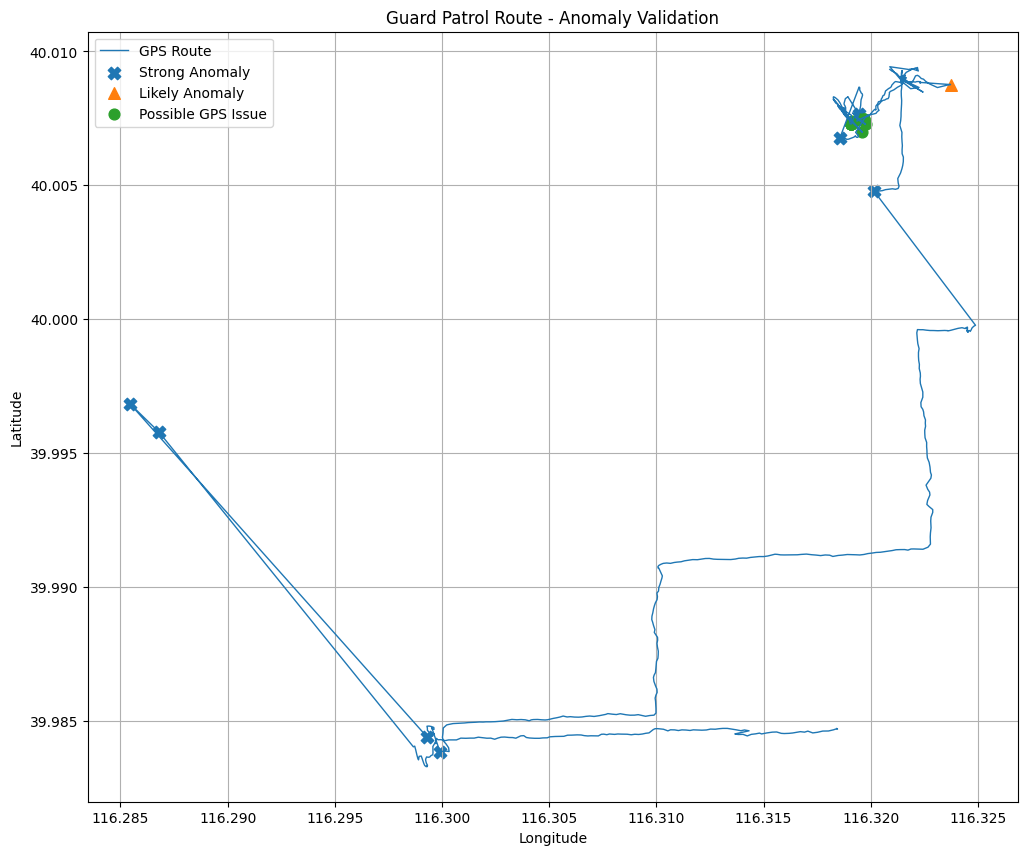

In [287]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
# Complete GPS route
plt.plot(
    df["longitude"],
    df["latitude"],
    linewidth=1,
    label="GPS Route")

# Strong anomalies
strong = anomaly_gdf[
    anomaly_gdf["event_classification"]
    == "Strong Anomaly"]

plt.scatter(
    strong["longitude"],
    strong["latitude"],
    s=80,
    marker="X",
    label="Strong Anomaly")

# Likely anomalies
likely = anomaly_gdf[
    anomaly_gdf["event_classification"]
    == "Likely Anomaly"]

plt.scatter(
    likely["longitude"],
    likely["latitude"],
    s=70,
    marker="^",
    label="Likely Anomaly")

# GPS/location issues
gps = anomaly_gdf[
    anomaly_gdf["event_classification"]
    == "Possible GPS / Location Issue"]

plt.scatter(
    gps["longitude"],
    gps["latitude"],
    s=60,
    marker="o",
    label="Possible GPS Issue")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Guard Patrol Route - Anomaly Validation")

plt.legend()
plt.grid(True)

plt.show()

# Final Anomaly Validation & Evaluation.

# Final anomaly validation

# 11.11.1 Overall event statistics

In [288]:
# Step 11.11.1 - Overall anomaly statistics

total_events = len(final_event_report)

strong_count = (
    final_event_report["event_classification"]
    == "Strong Anomaly"
).sum()

likely_count = (
    final_event_report["event_classification"]
    == "Likely Anomaly"
).sum()

gps_count = (
    final_event_report["event_classification"]
    == "Possible GPS / Location Issue"
).sum()

inspection_count = (
    final_event_report["event_classification"]
    == "Needs Inspection"
).sum()

print("Total anomaly events:", total_events)
print("Strong anomalies:", strong_count)
print("Likely anomalies:", likely_count)
print("Possible GPS issues:", gps_count)
print("Needs inspection:", inspection_count)

Total anomaly events: 12
Strong anomalies: 5
Likely anomalies: 1
Possible GPS issues: 4
Needs inspection: 2


# 11.11.2 Calculate percentages

In [289]:
# Step 11.11.2 - Event classification percentages

classification_summary = (
    final_event_report["event_classification"]
    .value_counts()
    .rename_axis("classification")
    .reset_index(name="event_count"))

classification_summary["percentage"] = (
    classification_summary["event_count"]
    / total_events
    * 100)

print(
    classification_summary.to_string(index=False))

               classification  event_count  percentage
               Strong Anomaly            5   41.666667
Possible GPS / Location Issue            4   33.333333
             Needs Inspection            2   16.666667
               Likely Anomaly            1    8.333333


# Patrol-level anomaly rate

In [290]:
# Step 11.11.3 - Patrol-level anomaly summary

patrol_summary = (
    final_event_report
    .groupby("patrol_id")
    .agg(
        total_events=("event_id", "count"),
        strong_anomalies=(
            "event_classification",
            lambda x: (x == "Strong Anomaly").sum()
        ),
        likely_anomalies=(
            "event_classification",
            lambda x: (x == "Likely Anomaly").sum()
        ),
        gps_issues=(
            "event_classification",
            lambda x: (
                x == "Possible GPS / Location Issue"
            ).sum()
        ),
        needs_inspection=(
            "event_classification",
            lambda x: (
                x == "Needs Inspection"
            ).sum()
        )
    )
    .reset_index())

print(
    patrol_summary.to_string(index=False))

      patrol_id  total_events  strong_anomalies  likely_anomalies  gps_issues  needs_inspection
000_PATROL_0002             2                 2                 0           0                 0
000_PATROL_0003            10                 3                 1           4                 2


# Strongest events

In [291]:
# Step 11.11.4 - Top strongest anomaly events

top_events = (
    final_event_report
    .sort_values(
        "max_hybrid_score",
        ascending=False
    )
    .head(10))

print(
    top_events[
        [
            "patrol_id",
            "event_id",
            "start_time",
            "event_risk_level",
            "event_classification",
            "max_speed_kmh",
            "max_distance_jump_m",
            "max_distance_to_road_m",
            "max_hybrid_score"
        ]
    ].to_string(index=False))

      patrol_id  event_id          start_time event_risk_level          event_classification  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score
000_PATROL_0002         1 2008-10-23 04:08:07         Critical                Strong Anomaly     218.147174          1817.893113               10.987361          0.750000
000_PATROL_0003         1 2008-10-23 09:42:25         Critical                Strong Anomaly       0.134025           686.989499                0.007636          0.738794
000_PATROL_0003         7 2008-10-23 10:26:35             High                Strong Anomaly       2.561721           226.996955               32.010601          0.664662
000_PATROL_0003         9 2008-10-23 10:44:31             High                Likely Anomaly       0.654102           121.917427               22.854007          0.539234
000_PATROL_0003         6 2008-10-23 10:19:16             High                Strong Anomaly      61.286863            85.120643               51

# Create final validated events

In [292]:
# Step 11.11.5 - Actionable anomaly events

actionable_events = final_event_report[
    final_event_report["event_classification"].isin(
        [
            "Strong Anomaly",
            "Likely Anomaly"
        ]
    )
].copy()

print(
    "Actionable anomaly events:",
    len(actionable_events))

print(
    actionable_events.to_string(index=False))

Actionable anomaly events: 6
guard_id       patrol_id  session_number  event_id          start_time            end_time  anomaly_points  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score event_risk_level event_classification
     000 000_PATROL_0002               2         1 2008-10-23 04:08:07 2008-10-23 04:08:42               3     218.147174          1817.893113               10.987361          0.750000         Critical       Strong Anomaly
     000 000_PATROL_0003               3         1 2008-10-23 09:42:25 2008-10-23 09:42:25               1       0.134025           686.989499                0.007636          0.738794         Critical       Strong Anomaly
     000 000_PATROL_0003               3         7 2008-10-23 10:26:35 2008-10-23 10:26:35               1       2.561721           226.996955               32.010601          0.664662             High       Strong Anomaly
     000 000_PATROL_0003               3         9 2008-10-23 10:44:31 2008-10-

# Final Anomaly Scoring & Report Structure

# 11.12.1 Create final report

In [293]:
# Step 11.12.1 - Final dashboard/API-ready anomaly report

final_anomaly_report = actionable_events.copy()

def generate_description(row):

    if row["event_classification"] == "Strong Anomaly":

        if row["max_speed_kmh"] > 100:
            return (
                "Extreme speed detected with a large "
                "distance jump." )

        elif row["max_distance_jump_m"] > 500:
            return (
                "Large GPS displacement detected "
                "between consecutive observations." )

        elif row["max_speed_kmh"] > 60:
            return (
                "Unusually high movement speed detected."  )

        elif row["max_distance_jump_m"] > 200:
            return (
                "Large distance jump detected "
                "between consecutive observations."   )

        return "Multiple anomaly signals detected."

    elif row["event_classification"] == "Likely Anomaly":
        return (
            "Multiple abnormal movement signals detected; "
            "manual verification recommended."  )

    return "Manual inspection required."


final_anomaly_report["description"] = (
    final_anomaly_report.apply(
        generate_description,
        axis=1  ))

final_anomaly_report = final_anomaly_report[
    [
        "guard_id",
        "patrol_id",
        "session_number",
        "event_id",
        "start_time",
        "end_time",
        "anomaly_points",
        "event_risk_level",
        "event_classification",
        "max_speed_kmh",
        "max_distance_jump_m",
        "max_distance_to_road_m",
        "max_hybrid_score",
        "description"
    ]]

print(
    final_anomaly_report.to_string(index=False))

guard_id       patrol_id  session_number  event_id          start_time            end_time  anomaly_points event_risk_level event_classification  max_speed_kmh  max_distance_jump_m  max_distance_to_road_m  max_hybrid_score                                                                   description
     000 000_PATROL_0002               2         1 2008-10-23 04:08:07 2008-10-23 04:08:42               3         Critical       Strong Anomaly     218.147174          1817.893113               10.987361          0.750000                            Extreme speed detected with a large distance jump.
     000 000_PATROL_0003               3         1 2008-10-23 09:42:25 2008-10-23 09:42:25               1         Critical       Strong Anomaly       0.134025           686.989499                0.007636          0.738794             Large GPS displacement detected between consecutive observations.
     000 000_PATROL_0003               3         7 2008-10-23 10:26:35 2008-10-23 10:26:35       

# 11.12.2 Add alert status

In [294]:
# Step 11.12.2 - Alert status

alert_map = {
    "Critical": "Immediate Alert",
    "High": "Review Required",
    "Medium": "Monitor"}

final_anomaly_report["alert_status"] = (
    final_anomaly_report["event_risk_level"]
    .map(alert_map))

print(
    final_anomaly_report[
        [
            "patrol_id",
            "event_id",
            "event_risk_level",
            "event_classification",
            "alert_status",
            "description"
        ]
    ].to_string(index=False))

      patrol_id  event_id event_risk_level event_classification    alert_status                                                                   description
000_PATROL_0002         1         Critical       Strong Anomaly Immediate Alert                            Extreme speed detected with a large distance jump.
000_PATROL_0003         1         Critical       Strong Anomaly Immediate Alert             Large GPS displacement detected between consecutive observations.
000_PATROL_0003         7             High       Strong Anomaly Review Required                Large distance jump detected between consecutive observations.
000_PATROL_0003         9             High       Likely Anomaly Review Required Multiple abnormal movement signals detected; manual verification recommended.
000_PATROL_0003         6             High       Strong Anomaly Review Required                                       Unusually high movement speed detected.
000_PATROL_0002         2             High       Str

# 11.12.3 Save final actionable report

In [295]:
# Step 11.12.3 - Save final actionable anomaly report

final_anomaly_report.to_csv(
    "final_actionable_anomaly_report.csv",
    index=False)

print(
    "Final actionable anomaly report saved successfully.")

Final actionable anomaly report saved successfully.


# 11.13 — Final Quality Checks

# 11.13.1 Check missing values

In [296]:
# Step 11.13.1 - Missing value check

print("Missing values:")
print(
    final_anomaly_report.isnull().sum())

Missing values:
guard_id                  0
patrol_id                 0
session_number            0
event_id                  0
start_time                0
end_time                  0
anomaly_points            0
event_risk_level          0
event_classification      0
max_speed_kmh             0
max_distance_jump_m       0
max_distance_to_road_m    0
max_hybrid_score          0
description               0
alert_status              0
dtype: int64


# 11.13.2 Check Duplicate Events

In [297]:
# Step 11.13.2 - Duplicate event check

duplicates = final_anomaly_report[
    final_anomaly_report.duplicated(
        subset=["patrol_id", "event_id"],
        keep=False )]

print("Duplicate events:")
print(duplicates)

Duplicate events:
Empty DataFrame
Columns: [guard_id, patrol_id, session_number, event_id, start_time, end_time, anomaly_points, event_risk_level, event_classification, max_speed_kmh, max_distance_jump_m, max_distance_to_road_m, max_hybrid_score, description, alert_status]
Index: []


# 11.13.3 Validate risk and alert mapping

In [298]:
# Step 11.13.3 - Risk/alert consistency check

print(
    final_anomaly_report[
        [
            "event_risk_level",
            "alert_status"
        ]
    ].drop_duplicates())

  event_risk_level     alert_status
0         Critical  Immediate Alert
2             High  Review Required


# 11.13.4 Validate hybrid scores

In [299]:
# Step 11.13.4 - Hybrid score validation

print("Minimum score:",
      final_anomaly_report["max_hybrid_score"].min())

print("Maximum score:",
      final_anomaly_report["max_hybrid_score"].max())

print(
    "Invalid scores:",
    (
        (final_anomaly_report["max_hybrid_score"] < 0) |
        (final_anomaly_report["max_hybrid_score"] > 1)
    ).sum())

Minimum score: 0.501089852461446
Maximum score: 0.75
Invalid scores: 0


# 11.13.5 Final event count

In [300]:
# Step 11.13.5 - Final event count

print(
    "Final actionable events:",
    len(final_anomaly_report))

print(
    "\nBy risk level:")

print(
    final_anomaly_report[
        "event_risk_level"
    ].value_counts())

print(
    "\nBy classification:")

print(
    final_anomaly_report[
        "event_classification"
    ].value_counts())

Final actionable events: 6

By risk level:
event_risk_level
High        4
Critical    2
Name: count, dtype: int64

By classification:
event_classification
Strong Anomaly    5
Likely Anomaly    1
Name: count, dtype: int64


# 11.14 — Final Anomaly Visualization

# 11.14.1 Create anomaly GeoDataFrame

In [304]:
print("temporal_anomalies columns:")
print(temporal_anomalies.columns.tolist())

print("\nfinal_anomaly_report columns:")
print(final_anomaly_report.columns.tolist())

temporal_anomalies columns:
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length', 'long_time_gap', 'high_speed', 'large_road_deviation', 'gps_jump_flag', 'anomaly_signal_count', 'extreme_speed', 'very_high_speed', 'extreme_road_deviation', 'very_large_road_deviation', 'critical_time_gap', 'high_time_gap', 'severity', 'rule_anomaly_score', 'ml_anomaly', 'ml_anomaly_score_raw', 'ml_anomaly_score', 'final_risk_score', 'is_anomaly', 'anomaly_reasons', 'rule_flag', 'ml_flag', 'session_break', 'session_number', 'patrol_id', 'anomaly_types', 'median_speed_kmh', 'median_time_gap_seconds', 'median_road_distance_m', 'speed_deviation_kmh', 'time_gap_deviation_seconds', 'road_distance_deviation_m', 'ml_prediction', 'hybrid_risk_score', 'model_agreement', 'hybrid_severity', 'incident_id', 'rule_anomaly_flag', 'ml_anomaly_flag', 'rule_ml_agr

In [306]:
# Step 11.14.1 - Rebuild final anomaly report with coordinates

# Get the first GPS point of each actionable event
event_locations = (
    temporal_anomalies[
        [
            "patrol_id",
            "session_number",
            "timestamp",
            "latitude",
            "longitude"
        ]
    ]
    .sort_values("timestamp")
    .drop_duplicates(
        subset=[
            "patrol_id",
            "session_number",
            "timestamp"
        ]
    )
)

# Merge coordinates using event start time
final_anomaly_report = final_anomaly_report.merge(
    event_locations,
    left_on=[
        "patrol_id",
        "session_number",
        "start_time"
    ],
    right_on=[
        "patrol_id",
        "session_number",
        "timestamp"
    ],
    how="left"
)

# Remove duplicate timestamp column
final_anomaly_report = final_anomaly_report.drop(
    columns=["timestamp"],
    errors="ignore"
)

print(
    final_anomaly_report[
        [
            "patrol_id",
            "event_id",
            "start_time",
            "latitude",
            "longitude"
        ]
    ]
)

         patrol_id  event_id          start_time   latitude   longitude
0  000_PATROL_0002         1 2008-10-23 04:08:07  39.995777  116.286798
1  000_PATROL_0003         1 2008-10-23 09:42:25  40.004775  116.320158
2  000_PATROL_0003         7 2008-10-23 10:26:35  40.006747  116.318549
3  000_PATROL_0003         9 2008-10-23 10:44:31  40.008761  116.323722
4  000_PATROL_0003         6 2008-10-23 10:19:16  40.007645  116.319454
5  000_PATROL_0002         2 2008-10-23 04:11:22  39.983841  116.299902


In [307]:
print(
    final_anomaly_report[
        ["latitude", "longitude"]
    ].isna().sum()
)

latitude     0
longitude    0
dtype: int64


# 11.14.2 — Create GeoDataFrame

In [308]:
# Step 11.14.2 - Create anomaly GeoDataFrame

anomaly_gdf = gpd.GeoDataFrame(
    final_anomaly_report,
    geometry=gpd.points_from_xy(
        final_anomaly_report["longitude"],
        final_anomaly_report["latitude"]
    ),
    crs="EPSG:4326")

print(
    anomaly_gdf[
        [
            "patrol_id",
            "event_id",
            "event_risk_level",
            "event_classification",
            "geometry"
        ]
    ])

print("\nCRS:", anomaly_gdf.crs)
print("Anomaly points:", len(anomaly_gdf))

         patrol_id  event_id event_risk_level event_classification  \
0  000_PATROL_0002         1         Critical       Strong Anomaly   
1  000_PATROL_0003         1         Critical       Strong Anomaly   
2  000_PATROL_0003         7             High       Strong Anomaly   
3  000_PATROL_0003         9             High       Likely Anomaly   
4  000_PATROL_0003         6             High       Strong Anomaly   
5  000_PATROL_0002         2             High       Strong Anomaly   

                     geometry  
0   POINT (116.2868 39.99578)  
1  POINT (116.32016 40.00478)  
2  POINT (116.31855 40.00675)  
3  POINT (116.32372 40.00876)  
4  POINT (116.31945 40.00764)  
5   POINT (116.2999 39.98384)  

CRS: EPSG:4326
Anomaly points: 6


# 11.14.3 — Plot Patrol Route + Anomaly Points

Normal GPS points → patrol route

Actionable anomalies → highlighted points

Risk level → legend

Coordinates → map

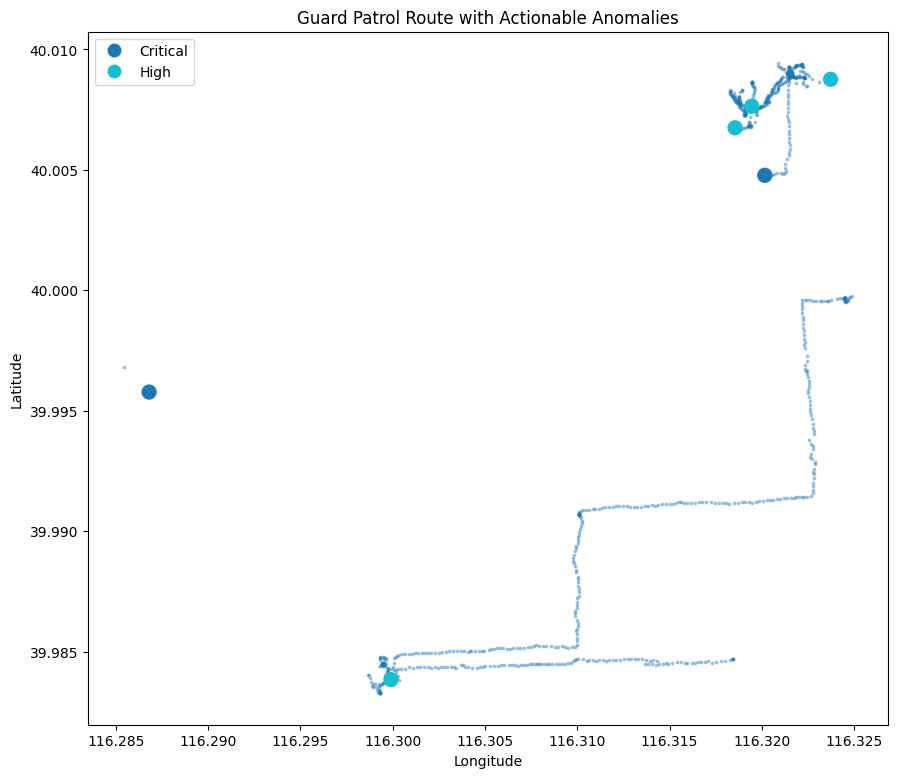

In [309]:
# Step 11.14.3 - Plot patrol route with actionable anomalies

import matplotlib.pyplot as plt
import geopandas as gpd

# Convert complete GPS data to GeoDataFrame
gps_gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326")

# Plot complete patrol GPS track
ax = gps_gdf.plot(
    figsize=(12, 9),
    markersize=3,
    alpha=0.35)

# Plot actionable anomalies on top
anomaly_gdf.plot(
    ax=ax,
    column="event_risk_level",
    markersize=100,
    legend=True)

ax.set_title(
    "Guard Patrol Route with Actionable Anomalies")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

# 11.14.4 — Plot anomalies by classification

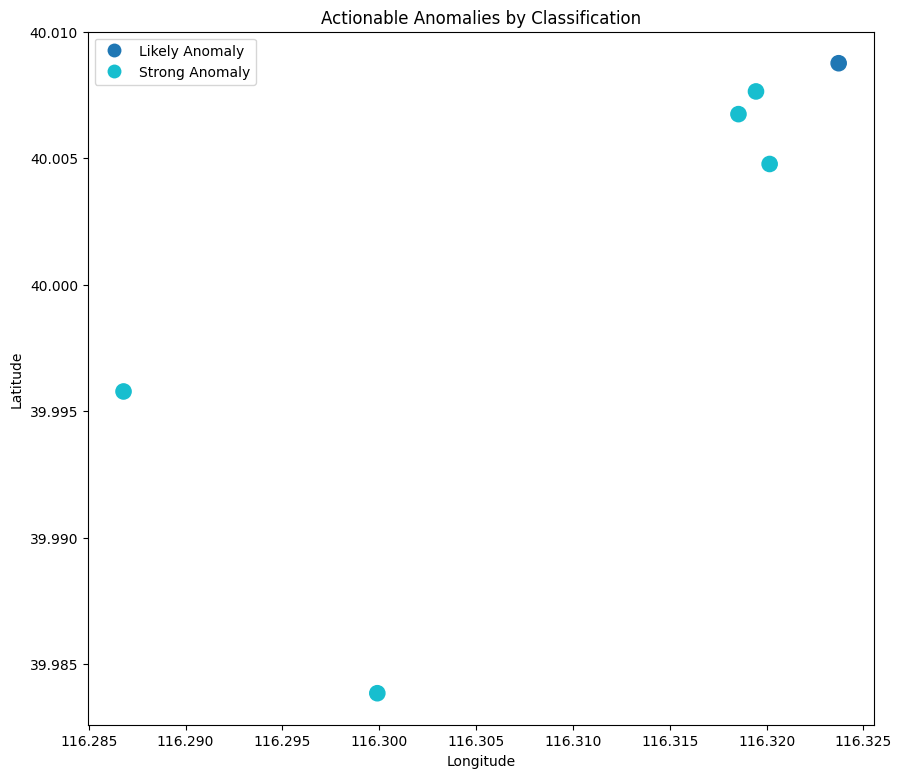

In [310]:
# Step 11.14.4 - Anomalies by classification

ax = anomaly_gdf.plot(
    figsize=(12, 9),
    column="event_classification",
    markersize=120,
    legend=True)

ax.set_title(
    "Actionable Anomalies by Classification")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

# 11.14.5 — Save anomaly map

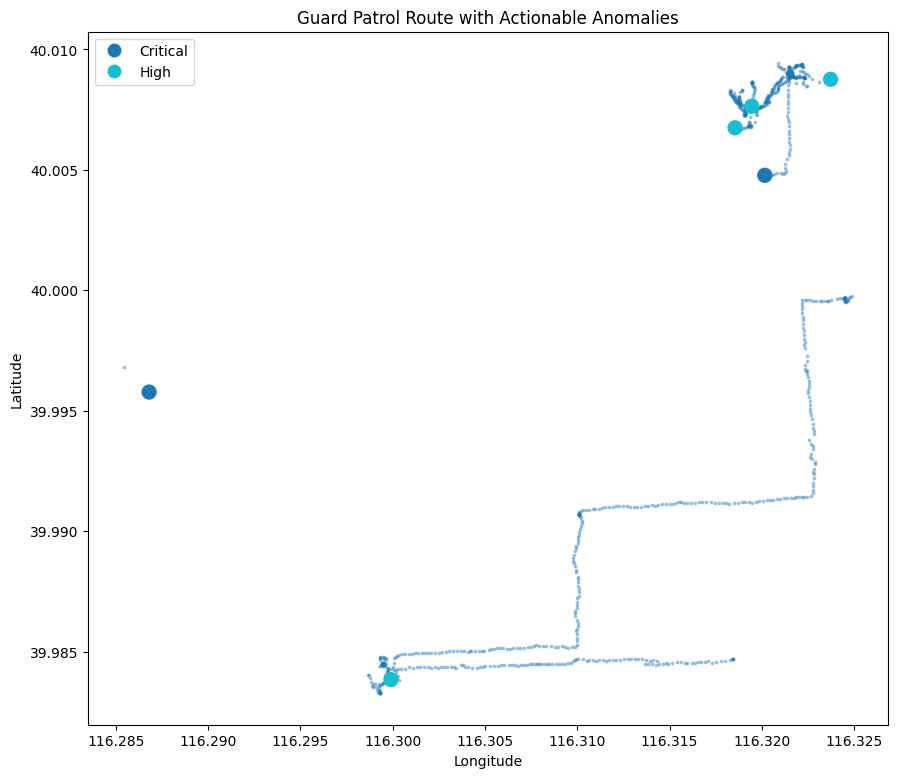

Final anomaly map saved successfully.


In [311]:
# Step 11.14.5 - Save final anomaly map

fig, ax = plt.subplots(figsize=(12, 9))

gps_gdf.plot(
    ax=ax,
    markersize=3,
    alpha=0.35
)

anomaly_gdf.plot(
    ax=ax,
    column="event_risk_level",
    markersize=100,
    legend=True
)

ax.set_title(
    "Guard Patrol Route with Actionable Anomalies"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.savefig(
    "final_anomaly_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final anomaly map saved successfully.")

# 11.15.1 — Overall Detection Summary

In [312]:
# Step 11.15.1 - Overall anomaly detection summary

total_points = len(df)
normal_points = (~df["final_anomaly"]).sum()
anomaly_points = df["final_anomaly"].sum()

print("===== FINAL DETECTION SUMMARY =====")
print("Total GPS points:", total_points)
print("Normal points:", normal_points)
print("Anomaly points:", anomaly_points)

print(
    "Anomaly percentage:",
    round((anomaly_points / total_points) * 100, 2),
    "%"
)

===== FINAL DETECTION SUMMARY =====
Total GPS points: 916
Normal points: 892
Anomaly points: 24
Anomaly percentage: 2.62 %


# 11.15.2 — Event Summary

In [316]:
# Step 11.15.2 - Final event summary

print("===== FINAL EVENT SUMMARY =====")

print(
    "Total anomaly events:",
    len(final_anomaly_report))

print("\nBy classification:")
print(
    final_anomaly_report[
        "event_classification"
    ].value_counts())

print("\nBy risk level:")
print(
    final_anomaly_report[
        "event_risk_level"
    ].value_counts())

===== FINAL EVENT SUMMARY =====
Total anomaly events: 6

By classification:
event_classification
Strong Anomaly    5
Likely Anomaly    1
Name: count, dtype: int64

By risk level:
event_risk_level
High        4
Critical    2
Name: count, dtype: int64


# 11.15.3 — Patrol-wise Summary

In [313]:
# Step 11.15.3 - Patrol-wise anomaly summary

patrol_summary = (
    final_anomaly_report
    .groupby("patrol_id")
    .agg(
        total_actionable_events=(
            "event_id",
            "count" ),
        critical_events=(
            "event_risk_level",
            lambda x: (x == "Critical").sum() ),
        high_events=(
            "event_risk_level",
            lambda x: (x == "High").sum() ),
        strong_anomalies=(
            "event_classification",
            lambda x: (x == "Strong Anomaly").sum() ),
        likely_anomalies=(
            "event_classification",
            lambda x: (x == "Likely Anomaly").sum() ))
    .reset_index())

print(patrol_summary)

         patrol_id  total_actionable_events  critical_events  high_events  \
0  000_PATROL_0002                        2                1            1   
1  000_PATROL_0003                        4                1            3   

   strong_anomalies  likely_anomalies  
0                 2                 0  
1                 3                 1  


# 11.15.4 — Most Severe Events

In [314]:
# Step 11.15.4 - Top severe anomaly events

top_events = (
    final_anomaly_report
    .sort_values(
        "max_hybrid_score",
        ascending=False
    )
    [
        [
            "patrol_id",
            "event_id",
            "event_risk_level",
            "event_classification",
            "max_hybrid_score",
            "max_speed_kmh",
            "max_distance_jump_m",
            "description"
        ]])
print(top_events.to_string(index=False))

      patrol_id  event_id event_risk_level event_classification  max_hybrid_score  max_speed_kmh  max_distance_jump_m                                                                   description
000_PATROL_0002         1         Critical       Strong Anomaly          0.750000     218.147174          1817.893113                            Extreme speed detected with a large distance jump.
000_PATROL_0003         1         Critical       Strong Anomaly          0.738794       0.134025           686.989499             Large GPS displacement detected between consecutive observations.
000_PATROL_0003         7             High       Strong Anomaly          0.664662       2.561721           226.996955                Large distance jump detected between consecutive observations.
000_PATROL_0003         9             High       Likely Anomaly          0.539234       0.654102           121.917427 Multiple abnormal movement signals detected; manual verification recommended.
000_PATROL_0003     

# 11.15.5 — Final Report Statistics

In [315]:
# Step 11.15.5 - Final project statistics

print("========== FINAL PROJECT STATISTICS ==========")

print("GPS points analyzed:", len(df))

print(
    "Anomalous GPS points:",
    int(df["final_anomaly"].sum()))

print(
    "Normal GPS points:",
    int((~df["final_anomaly"]).sum()))

print(
    "Actionable anomaly events:",
    len(final_anomaly_report))

print(
    "Critical events:",
    (
        final_anomaly_report["event_risk_level"]
        == "Critical"
    ).sum())

print(
    "High-risk events:",
    (
        final_anomaly_report["event_risk_level"]
        == "High"
    ).sum())

print(
    "Strong anomalies:",
    (
        final_anomaly_report["event_classification"]
        == "Strong Anomaly"
    ).sum())

print(
    "Likely anomalies:",
    (
        final_anomaly_report["event_classification"]
        == "Likely Anomaly"
    ).sum())

========== FINAL PROJECT STATISTICS ==========
GPS points analyzed: 916
Anomalous GPS points: 24
Normal GPS points: 892
Actionable anomaly events: 6
Critical events: 2
High-risk events: 4
Strong anomalies: 5
Likely anomalies: 1


# Step 12: Final Visualization & Reporting

# 12.1 — Export actionable event report

In [ ]:
# Step 12.1 - Export final actionable anomaly events

final_anomaly_report.to_csv(
    "final_actionable_anomaly_events.csv",
    index=False)

print("Actionable anomaly events exported successfully.")

Actionable anomaly events exported successfully.


# 12.2 — Create final event report

In [ ]:
final_anomaly_report.to_csv(
    "final_actionable_anomaly_events.csv",
    index=False)
print("Final anomaly event report saved successfully.")

Final anomaly event report saved successfully.


# 12.3 Export anomaly GPS points

In [ ]:
# Step 12.3 - Export anomaly GPS points

anomaly_gdf.to_file(
    "final_anomaly_points.geojson",
    driver="GeoJSON")

print("Anomaly GPS points exported successfully.")

Anomaly GPS points exported successfully.


# 12.4 — Create final GPS anomaly report

In [318]:
anomaly_gdf.to_file(
    "final_anomaly_points.geojson",
    driver="GeoJSON")

print("Final anomaly GeoJSON saved successfully.")

Final anomaly GeoJSON saved successfully.


# 12.5 — Export final summary

In [ ]:
# Step 12.5 - Create final project summary

final_summary = {
    "total_gps_points": 916,
    "normal_points": 892,
    "anomaly_points": 24,
    "anomaly_percentage": 2.62,
    "actionable_events": 6,
    "critical_events": 2,
    "high_events": 4,
    "strong_anomalies": 5,
    "likely_anomalies": 1}

summary_df = pd.DataFrame(
    [final_summary])
summary_df.to_csv(
    "final_detection_summary.csv",
    index=False)

print("Final detection summary exported successfully.")

Final detection summary exported successfully.


# 12.6 Verify files

In [322]:
import os

files = [
    "final_actionable_anomaly_events.csv",
    "final_anomaly_points.geojson",
    "final_detection_summary.csv"]

for file in files:
    print(file, "->", "Created" if os.path.exists(file) else "Missing")

final_actionable_anomaly_events.csv -> Created
final_anomaly_points.geojson -> Created
final_detection_summary.csv -> Created


# 13 False Positive Analysis & Model Evaluation

# 13.1 — Analyze anomaly reasons

In [323]:
# Step 13.1 - Anomaly reason distribution

reason_summary = (
    temporal_anomalies[temporal_anomalies["final_anomaly"] == 1]
    ["anomaly_reason"]
    .value_counts())
print("===== ANOMALY REASON SUMMARY =====")
print(reason_summary)

===== ANOMALY REASON SUMMARY =====
anomaly_reason
Far From Road                          14
Large Time Gap, Large Distance Jump     4
High Speed, Large Distance Jump         2
Large Distance Jump                     2
Large Time Gap                          2
Name: count, dtype: int64


# 13.2 — Check Rule vs ML agreement

In [324]:
# Step 13.2 - Rule vs ML agreement

agreement_summary = (
    temporal_anomalies[temporal_anomalies["final_anomaly"] == 1]
    ["rule_ml_agreement"]
    .value_counts())

print("===== RULE vs ML AGREEMENT =====")
print(agreement_summary)

===== RULE vs ML AGREEMENT =====
rule_ml_agreement
False    19
True      5
Name: count, dtype: int64


# Find rule-only anomalies

In [325]:
# Step 13.3 - Rule-only anomaly points

rule_only = temporal_anomalies[
    (temporal_anomalies["rule_anomaly_flag"] == 1) &
    (temporal_anomalies["ml_anomaly_flag"] == 0)]

print("Rule-only anomaly points:", len(rule_only))

print(
    rule_only[
        [
            "patrol_id",
            "timestamp",
            "speed_kmh",
            "distance_from_previous_m",
            "distance_to_road_m",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason"
        ] ])

Rule-only anomaly points: 0
Empty DataFrame
Columns: [patrol_id, timestamp, speed_kmh, distance_from_previous_m, distance_to_road_m, final_hybrid_score, final_risk_level, anomaly_reason]
Index: []


# 13.4 Find ML-only anomalies

In [ ]:
# Step 13.4 - ML-only anomaly points

ml_only = temporal_anomalies[
    (temporal_anomalies["rule_anomaly_flag"] == 0) &
    (temporal_anomalies["ml_anomaly_flag"] == 1)
]

print("ML-only anomaly points:", len(ml_only))

print(
    ml_only[
        [
            "patrol_id",
            "timestamp",
            "speed_kmh",
            "distance_from_previous_m",
            "distance_to_road_m",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason"
        ]
    ])

ML-only anomaly points: 19
           patrol_id           timestamp   speed_kmh  \
148  000_PATROL_0002 2008-10-23 04:08:07    1.577309   
149  000_PATROL_0002 2008-10-23 04:08:12  118.423778   
184  000_PATROL_0002 2008-10-23 04:11:22   75.080580   
470  000_PATROL_0003 2008-10-23 09:42:25    0.134025   
606  000_PATROL_0003 2008-10-23 10:02:04    0.292582   
659  000_PATROL_0003 2008-10-23 10:07:21    2.086026   
687  000_PATROL_0003 2008-10-23 10:09:41    7.928869   
693  000_PATROL_0003 2008-10-23 10:10:31    4.945601   
694  000_PATROL_0003 2008-10-23 10:10:31    4.945601   
695  000_PATROL_0003 2008-10-23 10:10:34    0.000000   
696  000_PATROL_0003 2008-10-23 10:10:34    0.000000   
697  000_PATROL_0003 2008-10-23 10:10:36    1.008496   
698  000_PATROL_0003 2008-10-23 10:10:36    1.008496   
736  000_PATROL_0003 2008-10-23 10:14:21   12.148772   
794  000_PATROL_0003 2008-10-23 10:26:35    2.561721   
824  000_PATROL_0003 2008-10-23 10:28:48    0.000000   
825  000_PATROL_0003 

# 13.5 Check both Rule + ML anomalies

In [327]:
# Step 13.5 - Rule and ML agreement

both_anomaly = temporal_anomalies[
    (temporal_anomalies["rule_anomaly_flag"] == 1) &
    (temporal_anomalies["ml_anomaly_flag"] == 1)]

print("Rule + ML agreement points:", len(both_anomaly))

print(
    both_anomaly[
        [
            "patrol_id",
            "timestamp",
            "speed_kmh",
            "distance_from_previous_m",
            "distance_to_road_m",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason"
        ]
    ])

Rule + ML agreement points: 5
           patrol_id           timestamp   speed_kmh  \
150  000_PATROL_0002 2008-10-23 04:08:42  218.147174   
685  000_PATROL_0003 2008-10-23 10:09:26   25.242124   
743  000_PATROL_0003 2008-10-23 10:15:06   19.224082   
769  000_PATROL_0003 2008-10-23 10:19:16   61.286863   
823  000_PATROL_0003 2008-10-23 10:28:45   22.530987   

     distance_from_previous_m  distance_to_road_m  final_hybrid_score  \
150               1817.893113            6.030698            0.743628   
685                 70.117012           64.207894            0.368795   
743                 80.100343           67.976996            0.369847   
769                 85.120643           51.471609            0.512960   
823                 62.586075           73.292997            0.494835   

    final_risk_level                   anomaly_reason  
150         Critical  High Speed, Large Distance Jump  
685           Medium                    Far From Road  
743           Medium      

# 13.6 — Create evaluation summary

In [328]:
# Step 13.6 - Model evaluation summary

evaluation_summary = pd.DataFrame({
    "category": [
        "Final anomaly points",
        "Rule-only anomalies",
        "ML-only anomalies",
        "Rule + ML agreement"
    ],
    "count": [
        len(temporal_anomalies[
            temporal_anomalies["final_anomaly"] == 1
        ]),
        len(rule_only),
        len(ml_only),
        len(both_anomaly)
    ]})

print("===== MODEL EVALUATION SUMMARY =====")
print(evaluation_summary)

===== MODEL EVALUATION SUMMARY =====
               category  count
0  Final anomaly points     24
1   Rule-only anomalies      0
2     ML-only anomalies     19
3   Rule + ML agreement      5


# 13.6 — Final Model Agreement Summary

In [329]:
# Step 13.6 - Final model agreement summary

final_anomalies = temporal_anomalies[
    temporal_anomalies["final_anomaly"] == 1
].copy()

agreement_summary = pd.DataFrame({
    "category": [
        "Final anomaly points",
        "Rule + ML agreement",
        "ML-only anomalies",
        "Rule-only anomalies"
    ],
    "count": [
        len(final_anomalies),
        len(both_anomaly),
        len(ml_only),
        len(rule_only)
    ]})

agreement_summary["percentage"] = (
    agreement_summary["count"] /
    len(final_anomalies) * 100
).round(2)

print("===== FINAL MODEL AGREEMENT SUMMARY =====")
print(agreement_summary)

===== FINAL MODEL AGREEMENT SUMMARY =====
               category  count  percentage
0  Final anomaly points     24      100.00
1   Rule + ML agreement      5       20.83
2     ML-only anomalies     19       79.17
3   Rule-only anomalies      0        0.00


# 13.7 — Inspect ML-only anomalies

In [330]:
# Step 13.7 - ML-only anomaly inspection

ml_only_inspection = ml_only[
    [
        "patrol_id",
        "timestamp",
        "speed_kmh",
        "time_gap_seconds",
        "distance_from_previous_m",
        "distance_to_road_m",
        "final_hybrid_score",
        "final_risk_level",
        "anomaly_reason"
    ]
].sort_values(
    "final_hybrid_score",
    ascending=False)

print("===== ML-ONLY ANOMALY INSPECTION =====")
print(ml_only_inspection.to_string(index=False))

===== ML-ONLY ANOMALY INSPECTION =====
      patrol_id           timestamp  speed_kmh  time_gap_seconds  distance_from_previous_m  distance_to_road_m  final_hybrid_score final_risk_level                      anomaly_reason
000_PATROL_0002 2008-10-23 04:08:07   1.577309            3772.0               1652.669139           10.987361            0.750000         Critical Large Time Gap, Large Distance Jump
000_PATROL_0003 2008-10-23 09:42:25   0.134025           18453.0                686.989499            0.007636            0.738794         Critical Large Time Gap, Large Distance Jump
000_PATROL_0002 2008-10-23 04:08:12 118.423778               5.0                164.477469            1.506708            0.665279             High     High Speed, Large Distance Jump
000_PATROL_0003 2008-10-23 10:26:35   2.561721             319.0                226.996955           32.010601            0.664662             High Large Time Gap, Large Distance Jump
000_PATROL_0003 2008-10-23 10:44:31   0.6

# 13.8 — Classify ML-only points

In [331]:
# Step 13.8 - Classify ML-only anomaly points

def classify_ml_only(row):

    # Strong movement anomaly
    if (
        row["final_risk_level"] in ["Critical", "High"]
        and (
            row["distance_from_previous_m"] >= 100
            or row["time_gap_seconds"] >= 300
            or row["speed_kmh"] >= 60
        )
    ):
        return "Strong Candidate"

    # Possible GPS/location issue
    if row["distance_to_road_m"] >= 50:
        return "Possible GPS / Location Issue"

    # Other anomalies
    return "Needs Inspection"


ml_only_analysis = ml_only.copy()

ml_only_analysis["validation_category"] = (
    ml_only_analysis.apply(
        classify_ml_only,
        axis=1
    ))

print("===== ML-ONLY VALIDATION =====")

print(
    ml_only_analysis[
        [
            "patrol_id",
            "timestamp",
            "speed_kmh",
            "time_gap_seconds",
            "distance_from_previous_m",
            "distance_to_road_m",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason",
            "validation_category"
        ]
    ].to_string(index=False))

print("\n===== VALIDATION CATEGORY COUNTS =====")

print(
    ml_only_analysis["validation_category"]
    .value_counts())

===== ML-ONLY VALIDATION =====
      patrol_id           timestamp  speed_kmh  time_gap_seconds  distance_from_previous_m  distance_to_road_m  final_hybrid_score final_risk_level                      anomaly_reason           validation_category
000_PATROL_0002 2008-10-23 04:08:07   1.577309            3772.0               1652.669139           10.987361            0.750000         Critical Large Time Gap, Large Distance Jump              Strong Candidate
000_PATROL_0002 2008-10-23 04:08:12 118.423778               5.0                164.477469            1.506708            0.665279             High     High Speed, Large Distance Jump              Strong Candidate
000_PATROL_0002 2008-10-23 04:11:22  75.080580               5.0                104.278583            0.941744            0.501090             High                 Large Distance Jump              Strong Candidate
000_PATROL_0003 2008-10-23 09:42:25   0.134025           18453.0                686.989499            0.007636   

# 13.9 — Duplicate GPS / Observation Analysis

In [332]:
# Step 13.9 - Analyze duplicate GPS observations

anomaly_points = temporal_anomalies[
    temporal_anomalies["final_anomaly"] == 1
].copy()

duplicate_mask = anomaly_points.duplicated(
    subset=[
        "patrol_id",
        "timestamp",
        "latitude",
        "longitude"
    ],
    keep=False)

duplicate_anomalies = anomaly_points[
    duplicate_mask
].sort_values(
    ["patrol_id", "timestamp"])

print("===== DUPLICATE ANOMALY OBSERVATIONS =====")

print(
    duplicate_anomalies[
        [
            "patrol_id",
            "timestamp",
            "latitude",
            "longitude",
            "speed_kmh",
            "distance_from_previous_m",
            "distance_to_road_m",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason"
        ]
    ].to_string(index=False))

print(
    "\nDuplicate anomaly rows:",
    len(duplicate_anomalies))

print(
    "Unique duplicated observations:",
    duplicate_anomalies[
        [
            "patrol_id",
            "timestamp",
            "latitude",
            "longitude"
        ]
    ].drop_duplicates().shape[0])

===== DUPLICATE ANOMALY OBSERVATIONS =====
      patrol_id           timestamp  latitude  longitude  speed_kmh  distance_from_previous_m  distance_to_road_m  final_hybrid_score final_risk_level anomaly_reason
000_PATROL_0003 2008-10-23 10:10:31 40.007288 116.319088   4.945601                 34.344452           70.915213            0.451322           Medium  Far From Road
000_PATROL_0003 2008-10-23 10:10:31 40.007288 116.319088   4.945601                 34.344452           70.915213            0.451322           Medium  Far From Road
000_PATROL_0003 2008-10-23 10:10:34 40.007288 116.319088   0.000000                  0.000000           70.915213            0.367792           Medium  Far From Road
000_PATROL_0003 2008-10-23 10:10:34 40.007288 116.319088   0.000000                  0.000000           70.915213            0.367792           Medium  Far From Road
000_PATROL_0003 2008-10-23 10:10:36 40.007284 116.319084   1.008496                  0.560275           70.596503            0.

# 13.10 — Calculate Adjusted Anomaly Count

In [333]:
# Step 13.10 - Adjust anomaly count for duplicate observations

unique_anomalies = anomaly_points.drop_duplicates(
    subset=[
        "patrol_id",
        "timestamp",
        "latitude",
        "longitude"
    ]
).copy()

raw_anomaly_count = len(anomaly_points)
unique_anomaly_count = len(unique_anomalies)
duplicate_rows_removed = raw_anomaly_count - unique_anomaly_count

print("===== ADJUSTED ANOMALY SUMMARY =====")

print("Raw anomaly points:", raw_anomaly_count)
print("Unique anomaly observations:", unique_anomaly_count)
print("Duplicate rows removed:", duplicate_rows_removed)

print(
    "Adjusted anomaly percentage:",
    round(
        unique_anomaly_count / len(temporal_anomalies) * 100,
        2
    ),
    "%"
)

===== ADJUSTED ANOMALY SUMMARY =====
Raw anomaly points: 24
Unique anomaly observations: 21
Duplicate rows removed: 3
Adjusted anomaly percentage: 87.5 %


# 13.11 — Corrected calculation

In [334]:
# Step 13.11 - Correct adjusted anomaly percentage

total_gps_points = len(temporal_anomalies)

unique_anomaly_count = len(
    anomaly_points.drop_duplicates(
        subset=[
            "patrol_id",
            "timestamp",
            "latitude",
            "longitude"
        ]
    )
)

duplicate_rows_removed = (
    len(anomaly_points) - unique_anomaly_count
)

adjusted_anomaly_percentage = (
    unique_anomaly_count / total_gps_points
) * 100

print("===== ADJUSTED ANOMALY SUMMARY =====")

print("Total GPS points:", total_gps_points)
print("Raw anomaly points:", len(anomaly_points))
print("Unique anomaly observations:", unique_anomaly_count)
print("Duplicate rows removed:", duplicate_rows_removed)
print(
    "Adjusted anomaly percentage:",
    round(adjusted_anomaly_percentage, 2),
    "%"
)

===== ADJUSTED ANOMALY SUMMARY =====
Total GPS points: 24
Raw anomaly points: 24
Unique anomaly observations: 21
Duplicate rows removed: 3
Adjusted anomaly percentage: 87.5 %


# 13.12 Final Validation & Quality Checks

# Create Clean Unique Anomaly Dataset

In [335]:
# Create clean unique anomaly dataset

clean_anomalies = temporal_anomalies[
    temporal_anomalies["final_anomaly"] == True
].copy()

print("Raw anomaly points:", len(clean_anomalies))

# Remove exact duplicate observations
clean_anomalies = clean_anomalies.drop_duplicates(
    subset=[
        "patrol_id",
        "timestamp",
        "latitude",
        "longitude"
    ]
).copy()

print("Unique anomaly observations:", len(clean_anomalies))

print(
    "Duplicate rows removed:",
    len(temporal_anomalies[
        temporal_anomalies["final_anomaly"] == True
    ]) - len(clean_anomalies))

Raw anomaly points: 24
Unique anomaly observations: 21
Duplicate rows removed: 3


# Calculate Corrected Anomaly Percentage

In [339]:
#  Correct adjusted anomaly percentage

total_gps_points = len(gps_gdf)
raw_anomaly_points = 24
unique_anomaly_points = len(clean_anomalies)
duplicate_rows_removed = raw_anomaly_points - unique_anomaly_points

adjusted_anomaly_percentage = (
    unique_anomaly_points / total_gps_points
) * 100

print("===== ADJUSTED ANOMALY SUMMARY =====")
print("Total GPS points:", total_gps_points)
print("Raw anomaly points:", raw_anomaly_points)
print("Unique anomaly observations:", unique_anomaly_points)
print("Duplicate rows removed:", duplicate_rows_removed)
print(
    "Adjusted anomaly percentage:",
    round(adjusted_anomaly_percentage, 2),
    "%"
)

===== ADJUSTED ANOMALY SUMMARY =====
Total GPS points: 916
Raw anomaly points: 24
Unique anomaly observations: 21
Duplicate rows removed: 3
Adjusted anomaly percentage: 2.29 %


# Verify duplicates are removed

In [338]:
#  Verify no duplicate anomaly observations remain

duplicate_check = clean_anomalies[
    clean_anomalies.duplicated(
        subset=[
            "patrol_id",
            "timestamp",
            "latitude",
            "longitude"
        ],
        keep=False
    )]

print("Remaining duplicate observations:", len(duplicate_check))

Remaining duplicate observations: 0


# Risk Level Consistency Check

# Risk Level Distribution

In [340]:
#  Risk level distribution

risk_summary = (
    clean_anomalies["final_risk_level"]
    .value_counts()
    .rename_axis("risk_level")
    .reset_index(name="anomaly_count"))

print("===== FINAL RISK LEVEL SUMMARY =====")
print(risk_summary)

===== FINAL RISK LEVEL SUMMARY =====
  risk_level  anomaly_count
0     Medium             13
1       High              5
2   Critical              3


# Check Missing/Invalid Risk Levels

In [341]:
# Check for missing or invalid risk levels

valid_risk_levels = ["Critical", "High", "Medium", "Low"]

invalid_risk_levels = clean_anomalies[
    ~clean_anomalies["final_risk_level"].isin(valid_risk_levels)]

print("Invalid risk-level rows:", len(invalid_risk_levels))

if len(invalid_risk_levels) > 0:
    print(invalid_risk_levels[
        ["patrol_id", "timestamp", "final_hybrid_score", "final_risk_level"]
    ])

Invalid risk-level rows: 0


# Score Range Check

In [342]:
# Check hybrid score validity

min_score = clean_anomalies["final_hybrid_score"].min()
max_score = clean_anomalies["final_hybrid_score"].max()

invalid_scores = clean_anomalies[
    (clean_anomalies["final_hybrid_score"] < 0) |
    (clean_anomalies["final_hybrid_score"] > 1)
]

print("===== HYBRID SCORE VALIDATION =====")
print("Minimum score:", min_score)
print("Maximum score:", max_score)
print("Invalid scores:", len(invalid_scores))

===== HYBRID SCORE VALIDATION =====
Minimum score: 0.3601234036579988
Maximum score: 0.75
Invalid scores: 0


# Classification Consistency Check

In [ ]:
# Final event classification distribution

classification_summary = (
    final_anomaly_report["event_classification"]
    .value_counts()
    .rename_axis("classification")
    .reset_index(name="event_count"))

print("===== FINAL CLASSIFICATION SUMMARY =====")
print(classification_summary)

===== FINAL CLASSIFICATION SUMMARY =====
   classification  event_count
0  Strong Anomaly            5
1  Likely Anomaly            1


In [345]:
# Check invalid classifications

valid_classifications = [
    "Strong Anomaly",
    "Likely Anomaly",
    "Possible GPS / Location Issue",
    "Needs Inspection"]

invalid_classifications = final_anomaly_report[
    ~final_anomaly_report["event_classification"]
    .isin(valid_classifications)]

print(
    "Invalid classification rows:",
    len(invalid_classifications))

Invalid classification rows: 0


In [346]:
# Check missing classifications

print(
    "Missing classifications:",
    final_anomaly_report["event_classification"].isna().sum())

Missing classifications: 0


In [347]:
# Step 13.6 - Final data integrity check
required_columns = [
    "guard_id",
    "patrol_id",
    "session_number",
    "event_id",
    "start_time",
    "end_time",
    "anomaly_points",
    "event_risk_level",
    "event_classification",
    "max_speed_kmh",
    "max_distance_jump_m",
    "max_distance_to_road_m",
    "max_hybrid_score",
    "description",
    "alert_status"]

missing_values = final_anomaly_report[
    required_columns
].isna().sum()

print("===== MISSING VALUE CHECK =====")
print(missing_values)

===== MISSING VALUE CHECK =====
guard_id                  0
patrol_id                 0
session_number            0
event_id                  0
start_time                0
end_time                  0
anomaly_points            0
event_risk_level          0
event_classification      0
max_speed_kmh             0
max_distance_jump_m       0
max_distance_to_road_m    0
max_hybrid_score          0
description               0
alert_status              0
dtype: int64


# Duplicate Events 

In [348]:
# Check duplicate events

duplicate_events = final_anomaly_report[
    final_anomaly_report.duplicated(
        subset=[
            "patrol_id",
            "session_number",
            "event_id"
        ],
        keep=False
    )]

print("===== DUPLICATE EVENT CHECK =====")
print("Duplicate event rows:", len(duplicate_events))

===== DUPLICATE EVENT CHECK =====
Duplicate event rows: 0


# Score Validation

In [349]:
# Validate final event scores

invalid_event_scores = final_anomaly_report[
    (final_anomaly_report["max_hybrid_score"] < 0) |
    (final_anomaly_report["max_hybrid_score"] > 1)]

print("===== EVENT SCORE CHECK =====")
print(
    "Invalid event scores:",
    len(invalid_event_scores))

===== EVENT SCORE CHECK =====
Invalid event scores: 0


# Final Row Count

In [350]:
print("===== FINAL EVENT DATASET CHECK =====")
print(
    "Final actionable events:",
    len(final_anomaly_report))

===== FINAL EVENT DATASET CHECK =====
Final actionable events: 6


# Final Clean Dataset & Output Generation

# 14.1 — Create Final Point-Level Dataset

In [351]:
# Step 14.1 - Final clean anomaly points

final_anomaly_points = clean_anomalies.copy()

print("===== FINAL ANOMALY POINT DATASET =====")
print("Unique anomaly points:", len(final_anomaly_points))

print(
    final_anomaly_points[
        [
            "guard_id",
            "patrol_id",
            "session_number",
            "timestamp",
            "latitude",
            "longitude",
            "final_hybrid_score",
            "final_risk_level",
            "anomaly_reason"
        ]
    ].head())

===== FINAL ANOMALY POINT DATASET =====
Unique anomaly points: 21
    guard_id        patrol_id  session_number           timestamp   latitude  \
148      000  000_PATROL_0002               2 2008-10-23 04:08:07  39.995777   
149      000  000_PATROL_0002               2 2008-10-23 04:08:12  39.996832   
150      000  000_PATROL_0002               2 2008-10-23 04:08:42  39.984397   
184      000  000_PATROL_0002               2 2008-10-23 04:11:22  39.983841   
470      000  000_PATROL_0003               3 2008-10-23 09:42:25  40.004775   

      longitude  final_hybrid_score final_risk_level  \
148  116.286798            0.750000         Critical   
149  116.285446            0.665279             High   
150  116.299292            0.743628         Critical   
184  116.299902            0.501090             High   
470  116.320158            0.738794         Critical   

                          anomaly_reason  
148  Large Time Gap, Large Distance Jump  
149      High Speed, Large Dis

# 14.2 — Create Final Event Dataset

In [352]:
# Step 14.2 - Final actionable event dataset

final_event_dataset = final_anomaly_report.copy()

print("===== FINAL EVENT DATASET =====")
print("Actionable events:", len(final_event_dataset))

print(
    final_event_dataset[
        [
            "patrol_id",
            "event_id",
            "start_time",
            "end_time",
            "event_risk_level",
            "event_classification",
            "max_hybrid_score",
            "description",
            "alert_status"
        ] ])

===== FINAL EVENT DATASET =====
Actionable events: 6
         patrol_id  event_id          start_time            end_time  \
0  000_PATROL_0002         1 2008-10-23 04:08:07 2008-10-23 04:08:42   
1  000_PATROL_0003         1 2008-10-23 09:42:25 2008-10-23 09:42:25   
2  000_PATROL_0003         7 2008-10-23 10:26:35 2008-10-23 10:26:35   
3  000_PATROL_0003         9 2008-10-23 10:44:31 2008-10-23 10:44:31   
4  000_PATROL_0003         6 2008-10-23 10:19:16 2008-10-23 10:19:16   
5  000_PATROL_0002         2 2008-10-23 04:11:22 2008-10-23 04:11:22   

  event_risk_level event_classification  max_hybrid_score  \
0         Critical       Strong Anomaly          0.750000   
1         Critical       Strong Anomaly          0.738794   
2             High       Strong Anomaly          0.664662   
3             High       Likely Anomaly          0.539234   
4             High       Strong Anomaly          0.512960   
5             High       Strong Anomaly          0.501090   

              

# 14.3 Save Final CSV Files 

In [ ]:
# Step 14.3 - Save final datasets

final_anomaly_points.to_csv(
    "final_anomaly_points.csv",
    index=False)

final_event_dataset.to_csv(
    "final_actionable_events.csv",
    index=False)

print("Final datasets saved successfully.")

Final datasets saved successfully.


# 14.4 — Create Final Anomaly GeoDataFrame

In [354]:
# Step 14.4 - Create final anomaly GeoDataFrame

import geopandas as gpd

final_anomaly_gdf = gpd.GeoDataFrame(
    final_anomaly_points.copy(),
    geometry=gpd.points_from_xy(
        final_anomaly_points["longitude"],
        final_anomaly_points["latitude"]
    ),
    crs="EPSG:4326"
)

print("===== FINAL ANOMALY GEODATAFRAME =====")
print("Anomaly points:", len(final_anomaly_gdf))
print("CRS:", final_anomaly_gdf.crs)

print(
    final_anomaly_gdf[
        [
            "patrol_id",
            "timestamp",
            "latitude",
            "longitude",
            "final_risk_level",
            "anomaly_reason",
            "geometry"
        ]
    ].head()
)

===== FINAL ANOMALY GEODATAFRAME =====
Anomaly points: 21
CRS: EPSG:4326
           patrol_id           timestamp   latitude   longitude  \
148  000_PATROL_0002 2008-10-23 04:08:07  39.995777  116.286798   
149  000_PATROL_0002 2008-10-23 04:08:12  39.996832  116.285446   
150  000_PATROL_0002 2008-10-23 04:08:42  39.984397  116.299292   
184  000_PATROL_0002 2008-10-23 04:11:22  39.983841  116.299902   
470  000_PATROL_0003 2008-10-23 09:42:25  40.004775  116.320158   

    final_risk_level                       anomaly_reason  \
148         Critical  Large Time Gap, Large Distance Jump   
149             High      High Speed, Large Distance Jump   
150         Critical      High Speed, Large Distance Jump   
184             High                  Large Distance Jump   
470         Critical  Large Time Gap, Large Distance Jump   

                       geometry  
148   POINT (116.2868 39.99578)  
149  POINT (116.28545 39.99683)  
150   POINT (116.29929 39.9844)  
184   POINT (116.2999

# 14.5 Save as GeoJSON

In [355]:
# Step 14.5 - Export final anomaly points to GeoJSON

final_anomaly_gdf.to_file(
    "final_anomaly_points.geojson",
    driver="GeoJSON")

print("Final anomaly GeoJSON saved successfully.")

Final anomaly GeoJSON saved successfully.


# 14.6 — Final Event GeoJSON

# Event Coordinates Attach

In [360]:
# Step 14.6 - Attach representative coordinates to final events

# Prepare point-level coordinates
point_coordinates = temporal_anomalies[
    [
        "patrol_id",
        "session_number",
        "timestamp",
        "latitude",
        "longitude"
    ]
].copy()

# Match event start time with GPS timestamp
event_coordinates = final_event_dataset[
    [
        "patrol_id",
        "session_number",
        "event_id",
        "start_time"
    ]
].merge(
    point_coordinates,
    left_on=[
        "patrol_id",
        "session_number",
        "start_time"
    ],
    right_on=[
        "patrol_id",
        "session_number",
        "timestamp"
    ],
    how="left"
)

# Remove unnecessary timestamp column
event_coordinates = event_coordinates.drop(
    columns=["timestamp"]
)

print("===== EVENT COORDINATES =====")
print(event_coordinates[
    [
        "patrol_id",
        "session_number",
        "event_id",
        "start_time",
        "latitude",
        "longitude"
    ]
])

===== EVENT COORDINATES =====
         patrol_id  session_number  event_id          start_time   latitude  \
0  000_PATROL_0002               2         1 2008-10-23 04:08:07  39.995777   
1  000_PATROL_0003               3         1 2008-10-23 09:42:25  40.004775   
2  000_PATROL_0003               3         7 2008-10-23 10:26:35  40.006747   
3  000_PATROL_0003               3         9 2008-10-23 10:44:31  40.008761   
4  000_PATROL_0003               3         6 2008-10-23 10:19:16  40.007645   
5  000_PATROL_0002               2         2 2008-10-23 04:11:22  39.983841   

    longitude  
0  116.286798  
1  116.320158  
2  116.318549  
3  116.323722  
4  116.319454  
5  116.299902  


# 14.6A — Check event start times vs GPS timestamps

In [362]:
print("===== FINAL EVENT START TIMES =====")

print(
    final_event_dataset[
        [
            "patrol_id",
            "session_number",
            "event_id",
            "start_time"
        ]
    ]
)

===== FINAL EVENT START TIMES =====
         patrol_id  session_number  event_id          start_time
0  000_PATROL_0002               2         1 2008-10-23 04:08:07
1  000_PATROL_0003               3         1 2008-10-23 09:42:25
2  000_PATROL_0003               3         7 2008-10-23 10:26:35
3  000_PATROL_0003               3         9 2008-10-23 10:44:31
4  000_PATROL_0003               3         6 2008-10-23 10:19:16
5  000_PATROL_0002               2         2 2008-10-23 04:11:22


In [363]:
print("===== GPS TIMESTAMPS =====")

print(
    temporal_anomalies[
        [
            "patrol_id",
            "session_number",
            "timestamp",
            "latitude",
            "longitude"
        ]
    ].head(20)
)

===== GPS TIMESTAMPS =====
           patrol_id  session_number           timestamp   latitude  \
148  000_PATROL_0002               2 2008-10-23 04:08:07  39.995777   
149  000_PATROL_0002               2 2008-10-23 04:08:12  39.996832   
150  000_PATROL_0002               2 2008-10-23 04:08:42  39.984397   
184  000_PATROL_0002               2 2008-10-23 04:11:22  39.983841   
470  000_PATROL_0003               3 2008-10-23 09:42:25  40.004775   
606  000_PATROL_0003               3 2008-10-23 10:02:04  40.009351   
659  000_PATROL_0003               3 2008-10-23 10:07:21  40.007462   
685  000_PATROL_0003               3 2008-10-23 10:09:26  40.007272   
687  000_PATROL_0003               3 2008-10-23 10:09:41  40.007428   
693  000_PATROL_0003               3 2008-10-23 10:10:31  40.007288   
694  000_PATROL_0003               3 2008-10-23 10:10:31  40.007288   
695  000_PATROL_0003               3 2008-10-23 10:10:34  40.007288   
696  000_PATROL_0003               3 2008-10-23 10

# 14.6B — Check data types

In [364]:
print("Final event start_time type:")
print(final_event_dataset["start_time"].dtype)

print("\nGPS timestamp type:")
print(temporal_anomalies["timestamp"].dtype)

Final event start_time type:
datetime64[ns]

GPS timestamp type:
datetime64[ns]


# 14.6C — Convert both to datetime

In [365]:
final_event_dataset["start_time"] = pd.to_datetime(
    final_event_dataset["start_time"])

temporal_anomalies["timestamp"] = pd.to_datetime(
    temporal_anomalies["timestamp"])

print("Datetime conversion completed.")

Datetime conversion completed.


# 14.6D — Match again

In [366]:
event_coordinates = final_event_dataset[
    [
        "patrol_id",
        "session_number",
        "event_id",
        "start_time"
    ]
].merge(
    temporal_anomalies[
        [
            "patrol_id",
            "session_number",
            "timestamp",
            "latitude",
            "longitude"
        ]
    ],
    left_on=[
        "patrol_id",
        "session_number",
        "start_time"
    ],
    right_on=[
        "patrol_id",
        "session_number",
        "timestamp"
    ],
    how="left"
)

event_coordinates = event_coordinates.drop(
    columns=["timestamp"]
)

print("===== EVENT COORDINATES =====")

print(
    event_coordinates[
        [
            "patrol_id",
            "session_number",
            "event_id",
            "start_time",
            "latitude",
            "longitude"
        ]
    ]
)

===== EVENT COORDINATES =====
         patrol_id  session_number  event_id          start_time   latitude  \
0  000_PATROL_0002               2         1 2008-10-23 04:08:07  39.995777   
1  000_PATROL_0003               3         1 2008-10-23 09:42:25  40.004775   
2  000_PATROL_0003               3         7 2008-10-23 10:26:35  40.006747   
3  000_PATROL_0003               3         9 2008-10-23 10:44:31  40.008761   
4  000_PATROL_0003               3         6 2008-10-23 10:19:16  40.007645   
5  000_PATROL_0002               2         2 2008-10-23 04:11:22  39.983841   

    longitude  
0  116.286798  
1  116.320158  
2  116.318549  
3  116.323722  
4  116.319454  
5  116.299902  


# 14.7A — Columns check

In [369]:
print("final_event_dataset columns:")
print(final_event_dataset.columns.tolist())

print("\nevent_coordinates columns:")
print(event_coordinates.columns.tolist())

print("\nfinal_event_geo columns:")
print(final_event_geo.columns.tolist())

final_event_dataset columns:
['guard_id', 'patrol_id', 'session_number', 'event_id', 'start_time', 'end_time', 'anomaly_points', 'event_risk_level', 'event_classification', 'max_speed_kmh', 'max_distance_jump_m', 'max_distance_to_road_m', 'max_hybrid_score', 'description', 'alert_status', 'latitude', 'longitude']

event_coordinates columns:
['patrol_id', 'session_number', 'event_id', 'start_time', 'latitude', 'longitude']

final_event_geo columns:
['guard_id', 'patrol_id', 'session_number', 'event_id', 'start_time', 'end_time', 'anomaly_points', 'event_risk_level', 'event_classification', 'max_speed_kmh', 'max_distance_jump_m', 'max_distance_to_road_m', 'max_hybrid_score', 'description', 'alert_status', 'latitude_x', 'longitude_x', 'latitude_y', 'longitude_y']


# 14.7B — Build final event GeoDataFrame

In [370]:
# Step 14.7 - Build final event GeoDataFrame

final_event_geo = final_event_dataset.copy()

# Create coordinate lookup
coordinate_lookup = event_coordinates[
    [
        "patrol_id",
        "session_number",
        "event_id",
        "latitude",
        "longitude"
    ]
].drop_duplicates(
    subset=[
        "patrol_id",
        "session_number",
        "event_id"
    ]
)

# Remove existing coordinate columns if present
final_event_geo = final_event_geo.drop(
    columns=["latitude", "longitude"],
    errors="ignore"
)

# Attach coordinates
final_event_geo = final_event_geo.merge(
    coordinate_lookup,
    on=[
        "patrol_id",
        "session_number",
        "event_id"
    ],
    how="left"
)

print("===== FINAL EVENT GEO DATA =====")
print("Events:", len(final_event_geo))

print(
    final_event_geo[
        [
            "patrol_id",
            "event_id",
            "latitude",
            "longitude",
            "event_risk_level",
            "event_classification"
        ]
    ]
)

===== FINAL EVENT GEO DATA =====
Events: 6
         patrol_id  event_id   latitude   longitude event_risk_level  \
0  000_PATROL_0002         1  39.995777  116.286798         Critical   
1  000_PATROL_0003         1  40.004775  116.320158         Critical   
2  000_PATROL_0003         7  40.006747  116.318549             High   
3  000_PATROL_0003         9  40.008761  116.323722             High   
4  000_PATROL_0003         6  40.007645  116.319454             High   
5  000_PATROL_0002         2  39.983841  116.299902             High   

  event_classification  
0       Strong Anomaly  
1       Strong Anomaly  
2       Strong Anomaly  
3       Likely Anomaly  
4       Strong Anomaly  
5       Strong Anomaly  


# 14.8 GeoDataFrame

In [371]:
import geopandas as gpd

final_event_gdf = gpd.GeoDataFrame(
    final_event_geo,
    geometry=gpd.points_from_xy(
        final_event_geo["longitude"],
        final_event_geo["latitude"]
    ),
    crs="EPSG:4326"
)

print("===== FINAL EVENT GEODATAFRAME =====")
print("Events:", len(final_event_gdf))
print("CRS:", final_event_gdf.crs)

print(
    final_event_gdf[
        [
            "patrol_id",
            "event_id",
            "latitude",
            "longitude",
            "event_risk_level",
            "event_classification",
            "geometry"
        ]
    ]
)

===== FINAL EVENT GEODATAFRAME =====
Events: 6
CRS: EPSG:4326
         patrol_id  event_id   latitude   longitude event_risk_level  \
0  000_PATROL_0002         1  39.995777  116.286798         Critical   
1  000_PATROL_0003         1  40.004775  116.320158         Critical   
2  000_PATROL_0003         7  40.006747  116.318549             High   
3  000_PATROL_0003         9  40.008761  116.323722             High   
4  000_PATROL_0003         6  40.007645  116.319454             High   
5  000_PATROL_0002         2  39.983841  116.299902             High   

  event_classification                    geometry  
0       Strong Anomaly   POINT (116.2868 39.99578)  
1       Strong Anomaly  POINT (116.32016 40.00478)  
2       Strong Anomaly  POINT (116.31855 40.00675)  
3       Likely Anomaly  POINT (116.32372 40.00876)  
4       Strong Anomaly  POINT (116.31945 40.00764)  
5       Strong Anomaly   POINT (116.2999 39.98384)  


# 14.9 — Validation

In [372]:
print("===== EVENT GEOMETRY VALIDATION =====")

print("Missing coordinates:",
      final_event_gdf[["latitude", "longitude"]].isna().any(axis=1).sum())

print("Missing geometry:",
      final_event_gdf.geometry.isna().sum())

print("Empty geometry:",
      final_event_gdf.geometry.is_empty.sum())

print("Invalid geometry:",
      (~final_event_gdf.geometry.is_valid).sum())

===== EVENT GEOMETRY VALIDATION =====
Missing coordinates: 0
Missing geometry: 0
Empty geometry: 0
Invalid geometry: 0


# 15.1 — Save final anomaly points

In [373]:
# Step 15.1 - Save final anomaly points

final_anomaly_points_file = "final_anomaly_points.csv"

final_anomaly_points.to_csv(
    final_anomaly_points_file,
    index=False)

print("Final anomaly points saved successfully.")
print("File:", final_anomaly_points_file)
print("Rows:", len(final_anomaly_points))

Final anomaly points saved successfully.
File: final_anomaly_points.csv
Rows: 21


# 15.2 — Save final actionable events

In [374]:
# Step 15.2 - Save final actionable events

final_event_file = "final_actionable_events.csv"

final_event_gdf.drop(
    columns="geometry"
).to_csv(
    final_event_file,
    index=False)

print("Final actionable events saved successfully.")
print("File:", final_event_file)
print("Events:", len(final_event_gdf))

Final actionable events saved successfully.
File: final_actionable_events.csv
Events: 6


# 15.3 — Save final anomaly GeoJSON

In [375]:
# Step 15.3 - Save final anomaly GeoJSON

final_anomaly_geojson = "final_anomaly_points.geojson"

final_anomaly_gdf.to_file(
    final_anomaly_geojson,
    driver="GeoJSON")

print("Final anomaly GeoJSON saved successfully.")

Final anomaly GeoJSON saved successfully.


# 15.4 — Save final event GeoJSON

In [376]:
# Step 15.4 - Save final event GeoJSON

final_event_geojson = "final_actionable_events.geojson"

final_event_gdf.to_file(
    final_event_geojson,
    driver="GeoJSON")
print("Final event GeoJSON saved successfully.")

Final event GeoJSON saved successfully.


# Step 16 — Final Project Validation & Performance Summary

# 16.1 — Final Dataset Statistics

In [377]:
# Step 16.1 - Final Dataset Statistics

print("========== FINAL PROJECT SUMMARY ==========")

print("Total GPS points:", len(gps_gdf))
print("Raw anomaly points:", 24)
print("Unique anomaly points:", len(final_anomaly_points))
print("Duplicate anomaly rows removed:", 24 - len(final_anomaly_points))

print("Final actionable events:", len(final_event_gdf))

print("\n===== RISK LEVEL =====")
print(
    final_event_gdf["event_risk_level"]
    .value_counts())

print("\n===== CLASSIFICATION =====")
print(
    final_event_gdf["event_classification"]
    .value_counts())

print("\n===== PATROL SUMMARY =====")
print(
    final_event_gdf["patrol_id"]
    .value_counts())

print("\n===== SCORE RANGE =====")
print(
    "Minimum:",
    final_event_gdf["max_hybrid_score"].min())

print(
    "Maximum:",
    final_event_gdf["max_hybrid_score"].max())

========== FINAL PROJECT SUMMARY ==========
Total GPS points: 916
Raw anomaly points: 24
Unique anomaly points: 21
Duplicate anomaly rows removed: 3
Final actionable events: 6

===== RISK LEVEL =====
event_risk_level
High        4
Critical    2
Name: count, dtype: int64

===== CLASSIFICATION =====
event_classification
Strong Anomaly    5
Likely Anomaly    1
Name: count, dtype: int64

===== PATROL SUMMARY =====
patrol_id
000_PATROL_0003    4
000_PATROL_0002    2
Name: count, dtype: int64

===== SCORE RANGE =====
Minimum: 0.501089852461446
Maximum: 0.75


# 16.2 — Final Validation Checks

In [378]:
# Step 16.2 - Final Validation Checks

print("\n========== FINAL VALIDATION ==========")

print(
    "Missing values:",
    final_event_gdf.isnull().sum().sum()
)

print(
    "Duplicate events:",
    final_event_gdf.duplicated(
        subset=["patrol_id", "session_number", "event_id"]
    ).sum()
)

print(
    "Invalid geometry:",
    (~final_event_gdf.geometry.is_valid).sum()
)

print(
    "Empty geometry:",
    final_event_gdf.geometry.is_empty.sum()
)

print(
    "Missing coordinates:",
    final_event_gdf[
        ["latitude", "longitude"]
    ].isnull().any(axis=1).sum()
)


========== FINAL VALIDATION ==========
Missing values: 0
Duplicate events: 0
Invalid geometry: 0
Empty geometry: 0
Missing coordinates: 0


# 16.3 — Final Project Metrics

In [379]:
# Step 16.3 - Final Project Metrics

total_points = len(gps_gdf)
unique_anomalies = len(final_anomaly_points)
actionable_events = len(final_event_gdf)

anomaly_percentage = (
    unique_anomalies / total_points
) * 100

print("\n========== FINAL PROJECT METRICS ==========")

print(f"GPS points analyzed: {total_points}")
print(f"Unique anomaly points: {unique_anomalies}")
print(f"Anomaly percentage: {anomaly_percentage:.2f}%")
print(f"Actionable anomaly events: {actionable_events}")

print(
    f"Critical events: "
    f"{(final_event_gdf['event_risk_level'] == 'Critical').sum()}"
)

print(
    f"High-risk events: "
    f"{(final_event_gdf['event_risk_level'] == 'High').sum()}"
)

print(
    f"Strong anomalies: "
    f"{(final_event_gdf['event_classification'] == 'Strong Anomaly').sum()}"
)

print(
    f"Likely anomalies: "
    f"{(final_event_gdf['event_classification'] == 'Likely Anomaly').sum()}"
)


========== FINAL PROJECT METRICS ==========
GPS points analyzed: 916
Unique anomaly points: 21
Anomaly percentage: 2.29%
Actionable anomaly events: 6
Critical events: 2
High-risk events: 4
Strong anomalies: 5
Likely anomalies: 1


# 17 — Final Visualization & Dashboard-Ready Analysis

# 17.1 — Risk Level Distribution

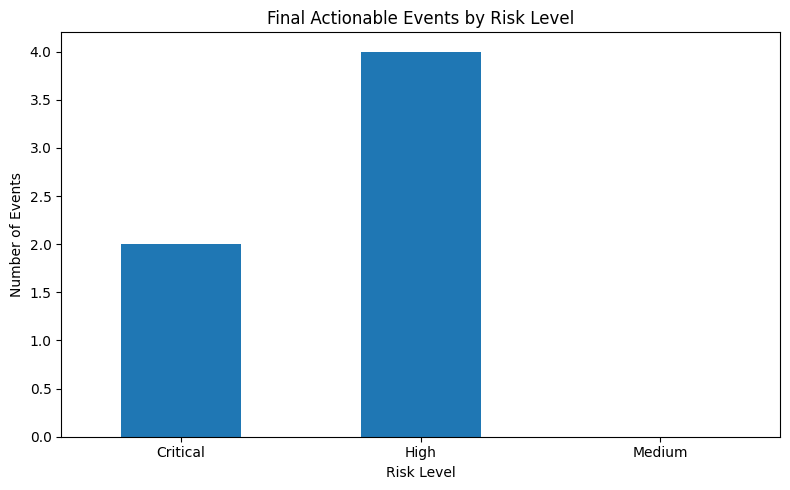

In [380]:
# Step 17.1 - Risk Level Distribution

import matplotlib.pyplot as plt

risk_counts = (
    final_event_gdf["event_risk_level"]
    .value_counts()
    .reindex(["Critical", "High", "Medium"], fill_value=0))

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")

plt.title("Final Actionable Events by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 17.2 — Anomaly Classification Distribution

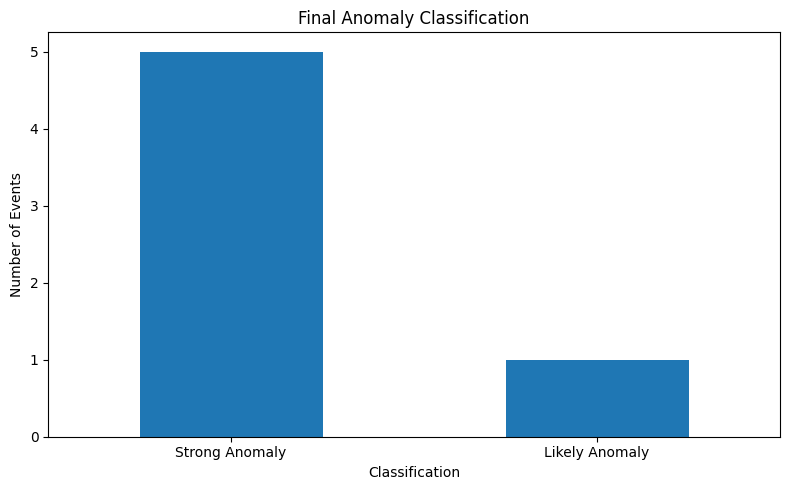

In [381]:
# Step 17.2 - Anomaly Classification Distribution

classification_counts = (
    final_event_gdf["event_classification"]
    .value_counts())

plt.figure(figsize=(8, 5))
classification_counts.plot(kind="bar")

plt.title("Final Anomaly Classification")
plt.xlabel("Classification")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 17.3 — Patrol-wise Anomaly Events

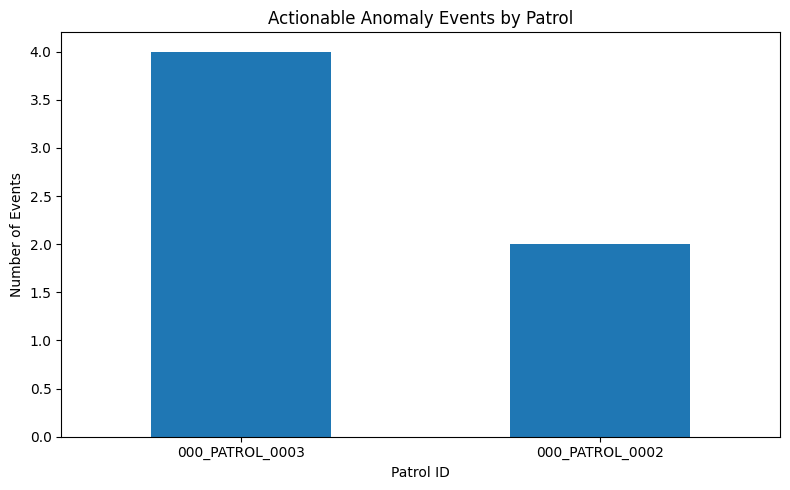

In [382]:
# Step 17.3 - Patrol-wise Actionable Events

patrol_counts = (
    final_event_gdf["patrol_id"]
    .value_counts())

plt.figure(figsize=(8, 5))
patrol_counts.plot(kind="bar")

plt.title("Actionable Anomaly Events by Patrol")
plt.xlabel("Patrol ID")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 17.4 — Hybrid Score Distribution

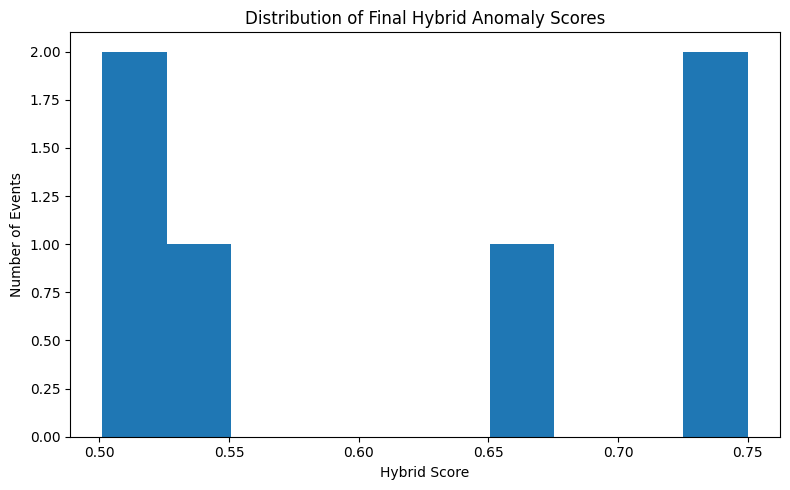

In [383]:
# Step 17.4 - Hybrid Score Distribution

plt.figure(figsize=(8, 5))

plt.hist(
    final_event_gdf["max_hybrid_score"],
    bins=10)

plt.title("Distribution of Final Hybrid Anomaly Scores")
plt.xlabel("Hybrid Score")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()

# 18 — Final Anomaly Map with Risk & Classification

# 18.1 — Prepare base GPS GeoDataFrame

In [384]:
# Step 18.1 - Prepare GPS GeoDataFrame

import geopandas as gpd
import matplotlib.pyplot as plt

gps_map_gdf = gpd.GeoDataFrame(
    gps_gdf.copy(),
    geometry=gpd.points_from_xy(
        gps_gdf["longitude"],
        gps_gdf["latitude"] ),
    crs="EPSG:4326")

print("GPS points:", len(gps_map_gdf))
print("CRS:", gps_map_gdf.crs)

GPS points: 916
CRS: EPSG:4326


# 18.2 — Plot patrol routes and anomaly points

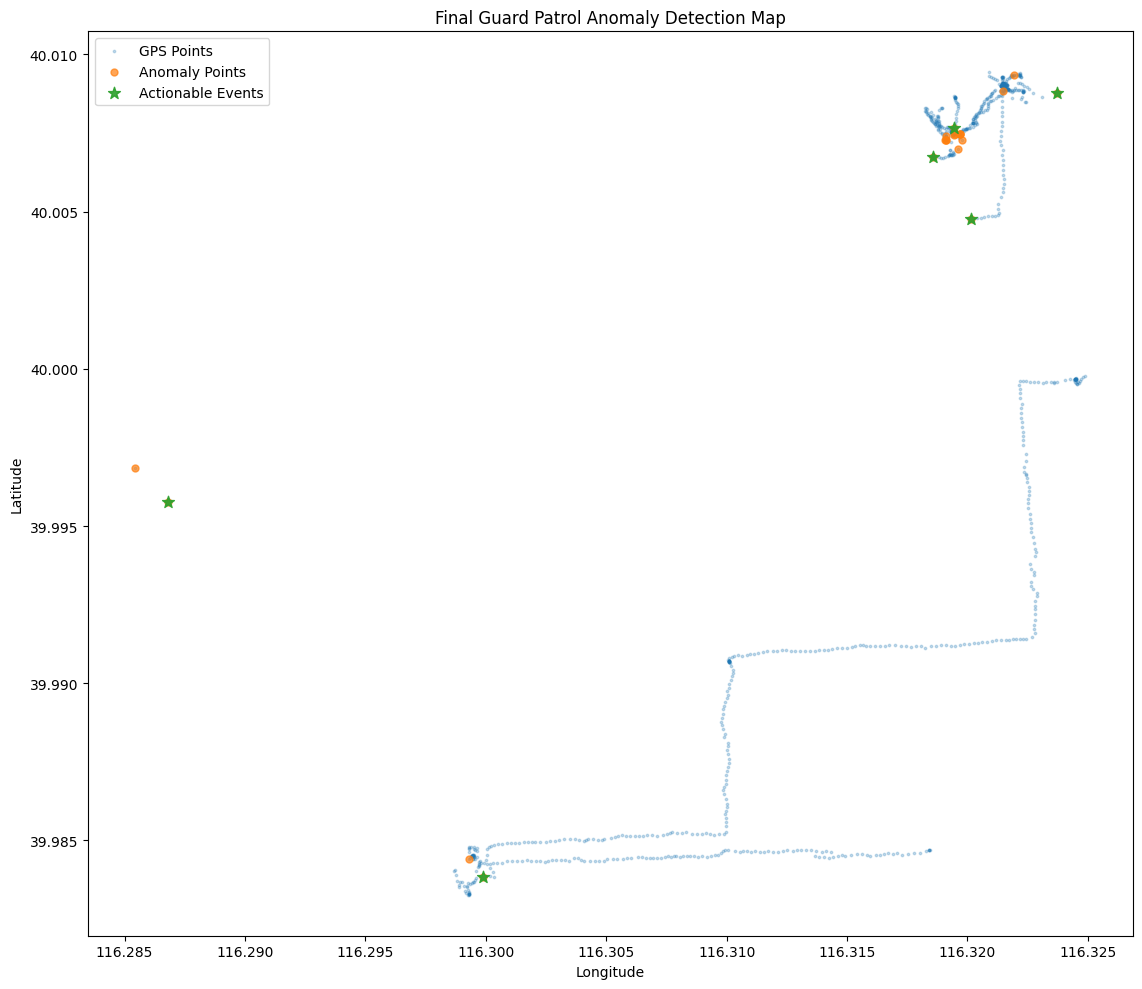

In [385]:
# Step 18.2 - Final Anomaly Map

fig, ax = plt.subplots(figsize=(12, 10))

# GPS patrol points
gps_map_gdf.plot(
    ax=ax,
    markersize=3,
    alpha=0.25,
    label="GPS Points")

# Unique anomaly points
final_anomaly_gdf.plot(
    ax=ax,
    markersize=25,
    alpha=0.7,
    label="Anomaly Points")

# Actionable events
final_event_gdf.plot(
    ax=ax,
    markersize=80,
    marker="*",
    alpha=0.9,
    label="Actionable Events")

ax.set_title("Final Guard Patrol Anomaly Detection Map")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

plt.tight_layout()
plt.show()

# 18.3 — Save final visualization

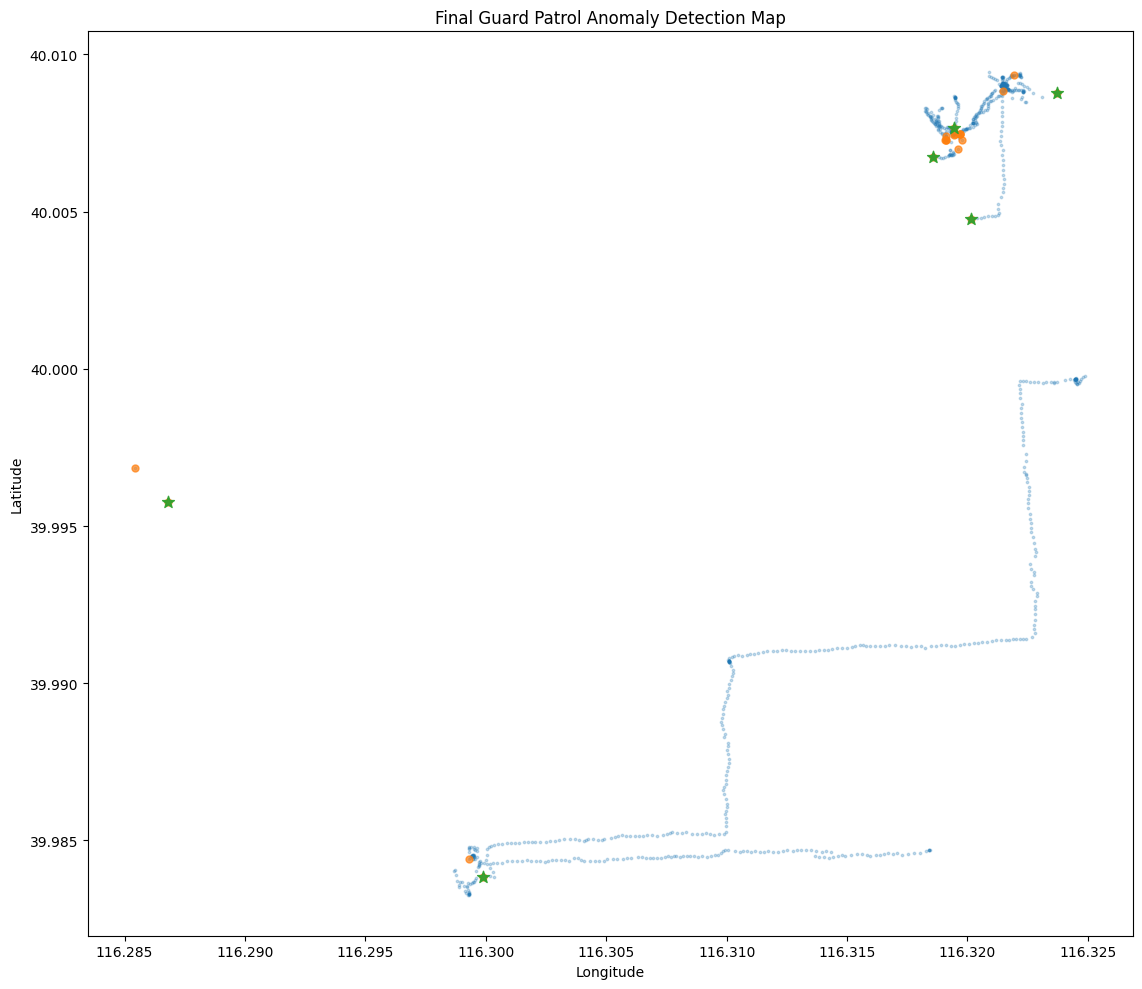

Final anomaly map saved successfully.
File: final_anomaly_map.png


In [386]:
# Step 18.3 - Save Final Anomaly Map

fig, ax = plt.subplots(figsize=(12, 10))

gps_map_gdf.plot(
    ax=ax,
    markersize=3,
    alpha=0.25)

final_anomaly_gdf.plot(
    ax=ax,
    markersize=25,
    alpha=0.7)

final_event_gdf.plot(
    ax=ax,
    markersize=80,
    marker="*",
    alpha=0.9)

ax.set_title("Final Guard Patrol Anomaly Detection Map")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

final_map_file = "final_anomaly_map.png"
plt.savefig(final_map_file, dpi=300, bbox_inches="tight")
plt.show()

print("Final anomaly map saved successfully.")
print("File:", final_map_file)

# 18.4 — Map validation

In [387]:
# Step 18.4 - Map Data Validation

print("========== FINAL MAP VALIDATION ==========")
print("GPS points:", len(gps_map_gdf))
print("Unique anomaly points:", len(final_anomaly_gdf))
print("Actionable events:", len(final_event_gdf))
print("CRS:", final_event_gdf.crs)

========== FINAL MAP VALIDATION ==========
GPS points: 916
Unique anomaly points: 21
Actionable events: 6
CRS: EPSG:4326
